# 광고 클릭률(CTR) 예측 — 통합 분석 노트북
**통계 졸업논문 | 토스 NEXT ML Challenge**

---

## 목차
1. [환경 설정 & 데이터 로드](#sec1)
2. [탐색적 데이터 분석 (EDA)](#sec2)
3. [통계 검정 — 연구 질문 RQ1~RQ4](#sec3)
4. [피처 엔지니어링](#sec4)
5. [상관관계 분석](#sec5)
6. [모델링](#sec6)
   - 6a. 로지스틱 회귀
   - 6b. XGBoost + SHAP
7. [PCA & 클러스터링](#sec7)
8. [보조 검증](#sec8)

---
## 1. 환경 설정 & 데이터 로드 <a id='sec1'></a>

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # 로컬 Jupyter / VS Code


**Google Colab 사용 시:**  
Drive 마운트 후 `static_document_dataset.zip` 파일 경로를 확인하고, 다음 셀의 `ZIP_FILE_PATH` 변수를 해당 경로로 수정한 뒤 압축 해제 셀을 실행해 주세요.

In [ ]:
# 한글 폰트 문제 해결을 위한 설정 코드
import matplotlib.font_manager as fm
import platform
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 기본 스타일 설정
plt.style.use('default')
sns.set_palette("husl")

def setup_korean_font():
    """운영체제별 한글 폰트 설정"""
    
    # 운영체제별 한글 폰트 리스트
    korean_fonts = {
        'Windows': [
            'Malgun Gothic',
            'Microsoft YaHei', 
            'SimHei',
            'NanumGothic',
            'NanumBarunGothic'
        ],
        'Darwin': [  # macOS
            'AppleGothic',
            'Apple SD Gothic Neo',
            'NanumGothic',
            'NanumBarunGothic'
        ],
        'Linux': [
            'DejaVu Sans',
            'NanumGothic',
            'NanumBarunGothic',
            'UnDotum'
        ]
    }
    
    # 시스템에 설치된 폰트 목록
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # 운영체제에 맞는 한글 폰트 찾기
    system = platform.system()
    fonts_to_try = korean_fonts.get(system, korean_fonts['Linux'])
    
    found_font = None
    for font in fonts_to_try:

🔍 현재 시스템: Windows
🔍 사용 가능한 폰트 확인 중...
✅ 한글 폰트 설정 완료: Malgun Gothic


True

In [3]:
import pandas as pd
from pathlib import Path

def _find_sample_submission() -> Path:
    for root in (Path.cwd(), Path.cwd().parent):
        p = root / "data" / "sample_submission.csv"
        if p.exists():
            return p
    return Path("static_document_dataset/sample_submission.csv")

sample = pd.read_csv(_find_sample_submission())


In [4]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path

BASE_DIR          = Path('..')
TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'
TRAIN_PATH        = BASE_DIR / 'data' / 'train.parquet'
TEST_PATH         = BASE_DIR / 'data' / 'test.parquet'

# train_sample.parquet 직접 로드 (이미 생성 완료)
train = pd.read_parquet(TRAIN_SAMPLE_PATH)
train['clicked'] = train['clicked'].astype(int)
df = train.copy()  # thesis 셀 호환용 별칭

print(f'train shape : {train.shape}')
print(f'CTR         : {train["clicked"].mean():.4f}')
print(f'columns     : {list(train.columns[:10])} ...')


train shape : (200000, 119)
CTR         : 0.0192
columns     : ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4'] ...


---
## 2. 탐색적 데이터 분석 (EDA) <a id='sec2'></a>


🎯 타깃 변수 분석 (clicked)
📈 전체 클릭률: 0.0192 (1.93%)
🔢 총 클릭 수: 3,850 / 200,000
⚖️ 클래스 불균형 비율: 50.9:1 (비클릭:클릭)


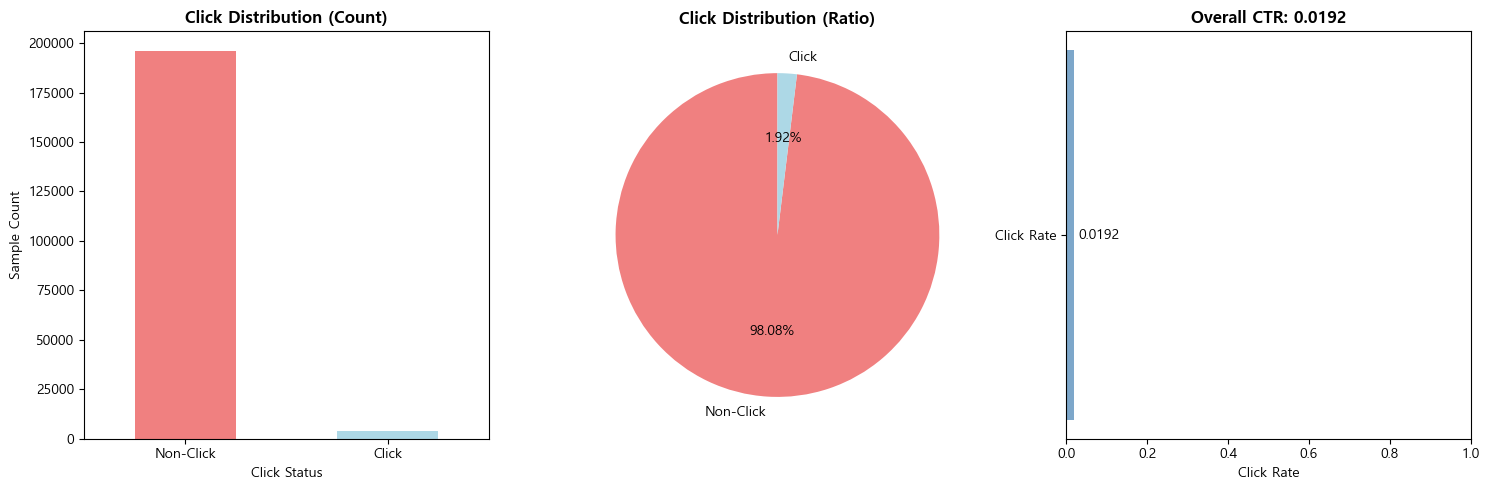

In [ ]:
# ========================================
# 🎯 2. 타깃 변수 분석 (clicked)
# ========================================

print("\n" + "=" * 60)
print("🎯 타깃 변수 분석 (clicked)")
print("=" * 60)

# CTR Calculation
click_rate = df['clicked'].mean()
total_clicks = df['clicked'].sum()
total_samples = len(df)

print(f"📈 전체 클릭률: {click_rate:.4f} ({click_rate * 100:.2f}%)")
print(f"🔢 총 클릭 수: {total_clicks:,} / {total_samples:,}")

if click_rate != 0:
    print(f"⚖️ 클래스 불균형 비율: {(1 - click_rate) / click_rate:.1f}:1 (비클릭:클릭)")
else:
    print("⚖️ 클래스 불균형 비율: 클릭 데이터가 없어 계산할 수 없습니다.")

# Target Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# clicked 값 정리
click_counts = df['clicked'].value_counts().sort_index()

# Click Distribution (Count)
click_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Click Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Click Status')
axes[0].set_ylabel('Sample Count')
axes[0].set_xticklabels(['Non-Click', 'Click'], rotation=0)
for i, (idx, val) in enumerate(click_counts.items()):
    axes[0].text(i, val + max(click_counts)*0.01, f'{val:,}', ha='center', va='bottom')

# Click Distribution (Ratio) - Pie Chart
sizes = click_counts.values
labels = ['Non-Click', 'Click']
colors = ['#3498db', '#e74c3c']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
axes[1].set_title('Click Distribution (Ratio)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[결론]")
print(f"- 심각한 클래스 불균형: {(1-click_rate)/click_rate:.1f}:1")
print(f"- 모델 학습 시 이 불균형을 고려해야 함 (가중치 조정, 샘플링 기법 활용)")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

train_sample = train.copy()
train_sample_processed = train.copy()
click_col    = 'clicked'
click_series = train_sample[click_col]

print(f'데이터 크기: {train_sample.shape}')
print(f'CTR: {train_sample[click_col].mean():.4f} ({train_sample[click_col].sum():,}건 / {len(train_sample):,}건)')

train_sample shape: (200000, 119)
CTR: 0.0192 (3,850건 / 200,000건)


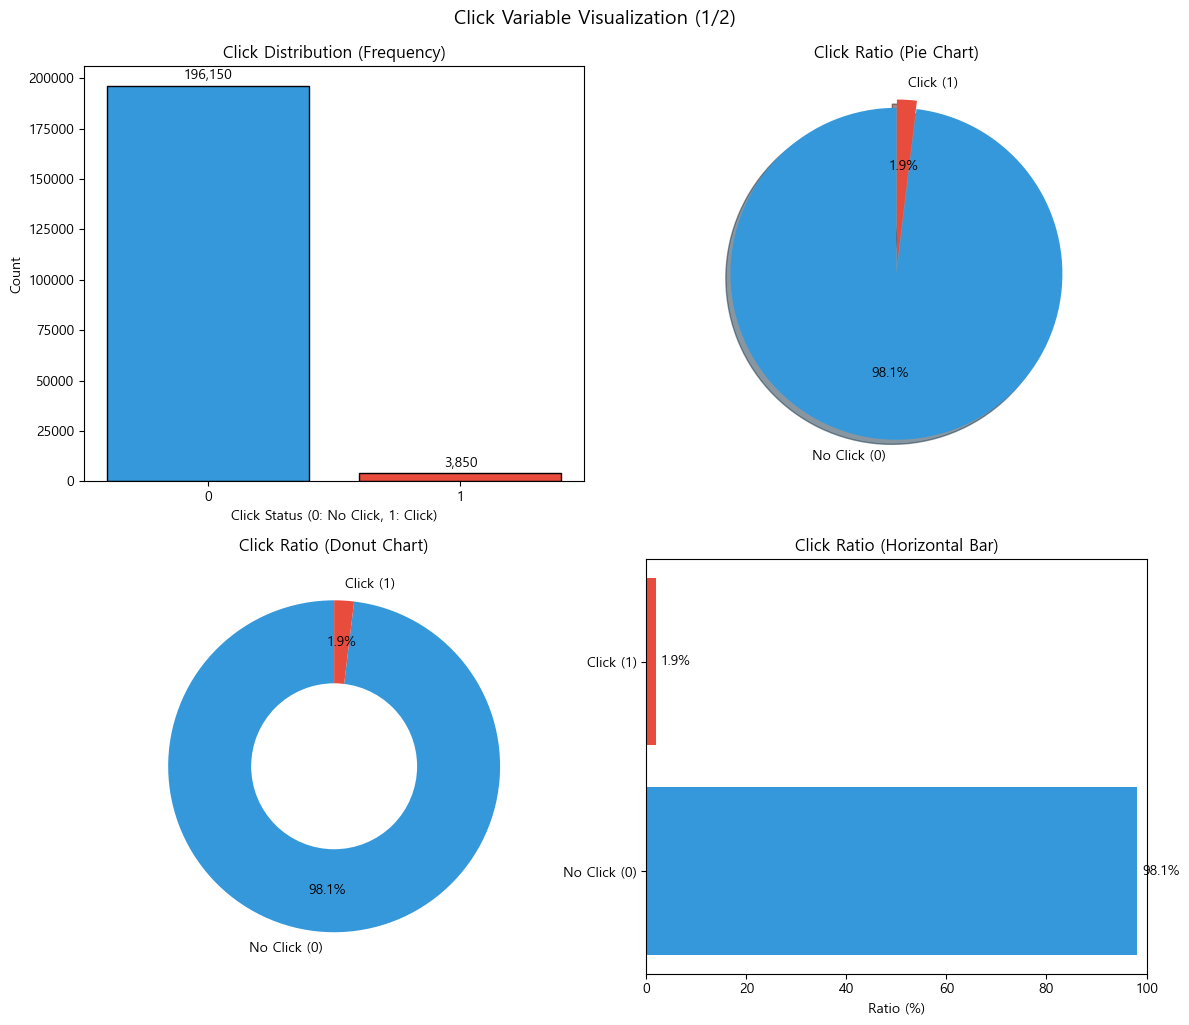

In [ ]:
# Click 분포: Bar chart (Count) & Pie chart (Ratio)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Frequency bar chart
click_counts = click_series.value_counts().sort_index()
bars = axes[0].bar(click_counts.index.astype(str), click_counts.values, 
                   color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Click Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Click Status (0: No Click, 1: Click)')
axes[0].set_ylabel('Frequency')
for bar, val in zip(bars, click_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(click_counts)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
sizes = click_counts.values
labels = ['No Click (0)', 'Click (1)']
colors = ['#3498db', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%',
                                        startangle=90)
axes[1].set_title('Click Ratio (Pie Chart)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

- ✅ CTR 1.98% (불균형 데이터)로 기본 통계 및 다중 시각화 완료
- 🔍 추가 EDA: gender×age, day×hour별 CTR 및 상관관계/이상치 분석 예정
- 🧩 피처 엔지니어링: 시간대·주중여부·상호작용 피처 생성 계획
- 🤖 모델링: Logistic→LightGBM/XGBoost 등과 불균형 처리 수행 예정
- 🎯 목표: 피처별 CTR 히트맵·상관관계 분석 완료 후 AUC 0.75+ 달성

# Task: CTR 종합 분석

사용자 특성(성별, 연령대) 및 시간적 요인(시간대, 요일)에 기반한 클릭률(CTR) 분석을 수행합니다.  
시간 기반 피처 엔지니어링(예: hour→시간대, day_of_week→평일/주말), 상관관계 히트맵 분석, `train_sample.parquet`를 이용한 베이스라인 로지스틱 회귀 모델 구현 및 불균형 데이터에 적합한 지표로 성능 평가를 진행합니다.

## 사용자 특성별 CTR 분석

### 목표
성별(gender) 및 연령대(age_group)에 따른 클릭률(CTR) 분포를 분석합니다. 각 사용자 특성 그룹별 CTR을 계산하고 시각화하여 주요 인사이트를 도출합니다.


### 접근 방법
`train_sample` DataFrame에서 'gender'와 'age_group'별 Click-Through Rate(CTR)를 계산합니다. 클릭 여부를 나타내는 'clicked' 컬럼(1: 클릭, 0: 비클릭)을 사용하여 각 그룹별 평균을 산출합니다.



CTR by Gender:
  gender       CTR
0    1.0  0.020298
1    2.0  0.017449

CTR by Age Group:
  age_group       CTR
0       1.0  0.077079
1       2.0  0.022102
2       3.0  0.020620
3       4.0  0.018629
4       5.0  0.016094
5       6.0  0.016653
6       7.0  0.017947
7       8.0  0.022948


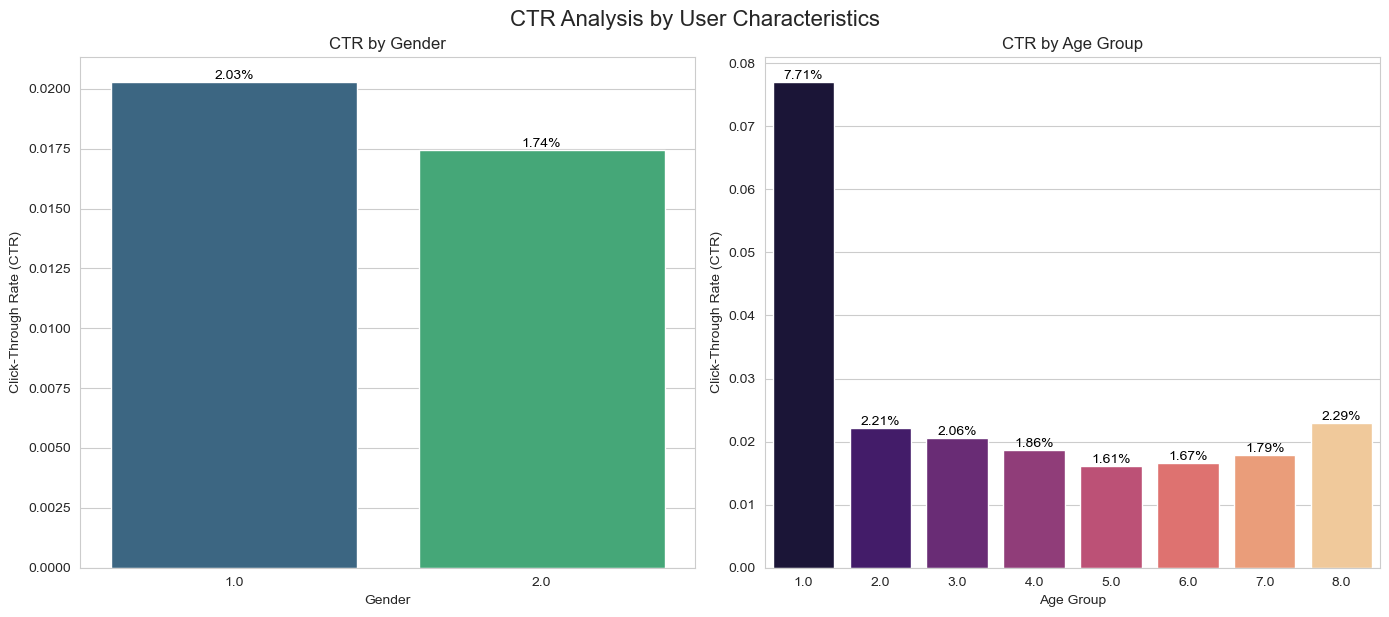

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ensure 'clicked' column is int for consistent calculations if it's still ArrowDtype
train_sample_processed = train_sample.copy()
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. Calculate CTR by gender
gender_ctr = train_sample_processed.groupby('gender')['clicked'].mean().reset_index()
gender_ctr.columns = ['gender', 'CTR']

# 2. Calculate CTR by age_group
age_group_ctr = train_sample_processed.groupby('age_group')['clicked'].mean().reset_index()
age_group_ctr.columns = ['age_group', 'CTR']

print("CTR by Gender:")
print(gender_ctr)
print("\nCTR by Age Group:")
print(age_group_ctr)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3. Plot Gender CTR
sns.barplot(x='gender', y='CTR', data=gender_ctr, hue='gender', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('CTR by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Click-Through Rate (CTR)')
for index, row in gender_ctr.iterrows():
    axes[0].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom")

# 4. Plot Age Group CTR
sns.barplot(x='age_group', y='CTR', data=age_group_ctr, hue='age_group', palette='magma', ax=axes[1], legend=False)
axes[1].set_title('CTR by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Click-Through Rate (CTR)')
for index, row in age_group_ctr.iterrows():
    axes[1].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom")

# 5. Display plots
plt.tight_layout()
plt.suptitle('CTR Analysis by User Characteristics', y=1.02, fontsize=16)
plt.show()


RQ1: Age Group vs CTR — Statistical Tests
One-way ANOVA:   F=22.1507, p=0.000000 ***
Kruskal-Wallis:  H=154.9403, p=0.000000 ***
Effect size eta2=0.000774  (small(<0.06) — Cohen 1988)

Tukey HSD post-hoc (age_group):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0   -0.055    0.0 -0.0744 -0.0356   True
   1.0    3.0  -0.0565    0.0 -0.0757 -0.0372   True
   1.0    4.0  -0.0585    0.0 -0.0776 -0.0393   True
   1.0    5.0   -0.061    0.0 -0.0801 -0.0418   True
   1.0    6.0  -0.0604    0.0 -0.0793 -0.0416   True
   1.0    7.0  -0.0591    0.0 -0.0779 -0.0403   True
   1.0    8.0  -0.0541    0.0  -0.073 -0.0353   True
   2.0    3.0  -0.0015 0.9977 -0.0082  0.0052  False
   2.0    4.0  -0.0035 0.7386   -0.01   0.003  False
   2.0    5.0   -0.006 0.0833 -0.0124  0.0004  False
   2.0    6.0  -0.0054 0.0473 -0.0109    -0.0   True
   2.0    7.0  -0.0042 0.2482 -0.0094  0.

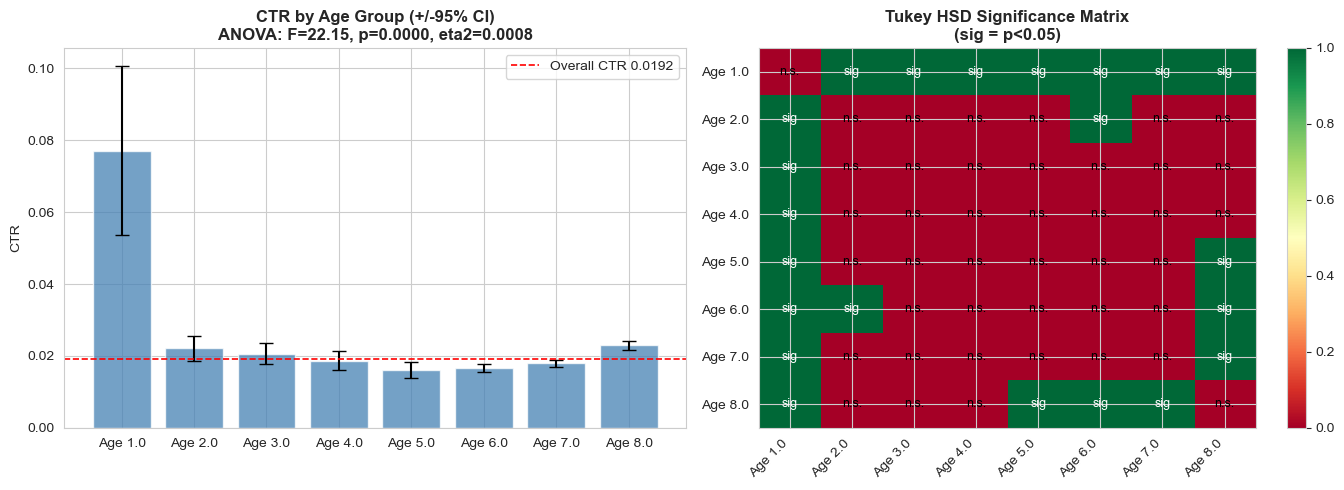


Conclusion: Age group CTR differences are statistically significant (p<0.001)
Practical effect size eta2=0.0008 — small (limited practical significance)
Gender effect Cramer's V=0.0100 — negligible


In [10]:
# ================================================================
# Statistical Tests — User Characteristics (Age Group & Gender)
# Effect size: eta-squared (ANOVA), Cramer's V (Chi-Square)
# ================================================================
from scipy.stats import f_oneway, kruskal, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GLOBAL_CTR_STAT = train_sample_processed['clicked'].mean()

# ── Age Group: One-way ANOVA + Kruskal-Wallis + eta-squared ─────
age_groups_list = sorted(train_sample_processed['age_group'].dropna().unique())
age_samples_stat = [
    train_sample_processed[train_sample_processed['age_group'] == ag]['clicked'].values
    for ag in age_groups_list
]
F_age_stat, p_anova_age_stat = f_oneway(*age_samples_stat)
H_age_stat, p_kruskal_age_stat = kruskal(*age_samples_stat)

# eta^2 = SS_between / SS_total
grand_mean_stat = GLOBAL_CTR_STAT
ss_total_stat = ((train_sample_processed['clicked'] - grand_mean_stat) ** 2).sum()
ss_between_age = sum(len(s) * (s.mean() - grand_mean_stat) ** 2 for s in age_samples_stat if len(s) > 0)
eta_sq_age = ss_between_age / ss_total_stat

print("=" * 60)
print("RQ1: Age Group vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA:   F={F_age_stat:.4f}, p={p_anova_age_stat:.6f} "
      f"{'***' if p_anova_age_stat<0.001 else '**' if p_anova_age_stat<0.01 else '*' if p_anova_age_stat<0.05 else 'n.s.'}")
print(f"Kruskal-Wallis:  H={H_age_stat:.4f}, p={p_kruskal_age_stat:.6f} "
      f"{'***' if p_kruskal_age_stat<0.001 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_age:.6f}  "
      f"({'large(>=0.14)' if eta_sq_age>=0.14 else 'medium(>=0.06)' if eta_sq_age>=0.06 else 'small(<0.06)'} — Cohen 1988)")

# Tukey HSD post-hoc
valid_age_mask = train_sample_processed['age_group'].notna() & train_sample_processed['clicked'].notna()
tukey_age_res = pairwise_tukeyhsd(
    endog=train_sample_processed.loc[valid_age_mask, 'clicked'],
    groups=train_sample_processed.loc[valid_age_mask, 'age_group'],
    alpha=0.05
)
print("\nTukey HSD post-hoc (age_group):")
print(tukey_age_res.summary())

# ── Gender: Chi-Square + Cramer's V ─────────────────────────────
ct_gender = pd.crosstab(train_sample_processed['gender'], train_sample_processed['clicked'])
chi2_gender, p_chi2_gender, _, _ = chi2_contingency(ct_gender)
n_total_gender = ct_gender.values.sum()
cramers_v_gender = np.sqrt(chi2_gender / (n_total_gender * (min(ct_gender.shape) - 1)))

print("\n" + "=" * 60)
print("RQ1: Gender vs CTR — Chi-Square + Cramer's V")
print("=" * 60)
print(f"Chi-Square: chi2={chi2_gender:.4f}, p={p_chi2_gender:.6f} "
      f"{'***' if p_chi2_gender<0.001 else 'n.s.'}")
print(f"Cramer's V: {cramers_v_gender:.6f}  "
      f"({'large(>=0.5)' if cramers_v_gender>=0.5 else 'medium(>=0.3)' if cramers_v_gender>=0.3 else 'small(<0.3)'})")

# ── Visualization: CI bar + Tukey significance heatmap ──────────
age_desc = train_sample_processed.groupby('age_group')['clicked'].agg(
    n='count', ctr='mean', std='std'
).reset_index()
age_desc['ci95'] = 1.96 * (age_desc['std'] / np.sqrt(age_desc['n']))

n_ag = len(age_groups_list)
sig_mat = np.zeros((n_ag, n_ag))
for row in tukey_age_res.summary().data[1:]:
    g1, g2, *_, reject = row
    try:
        i = list(age_groups_list).index(g1)
        j = list(age_groups_list).index(g2)
        sig_mat[i, j] = sig_mat[j, i] = 1 if reject else 0
    except ValueError:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(n_ag)
axes[0].bar(x_pos, age_desc['ctr'], color='steelblue', alpha=0.75)
axes[0].errorbar(x_pos, age_desc['ctr'],
                 yerr=age_desc['ci95'], fmt='none', color='black', capsize=5)
axes[0].axhline(GLOBAL_CTR_STAT, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {GLOBAL_CTR_STAT:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age {ag}' for ag in age_groups_list])
axes[0].set_title(
    f'CTR by Age Group (+/-95% CI)\n'
    f'ANOVA: F={F_age_stat:.2f}, p={p_anova_age_stat:.4f}, eta2={eta_sq_age:.4f}',
    fontweight='bold')
axes[0].set_ylabel('CTR')
axes[0].legend()

im = axes[1].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(n_ag))
axes[1].set_yticks(range(n_ag))
axes[1].set_xticklabels([f'Age {ag}' for ag in age_groups_list], rotation=45, ha='right')
axes[1].set_yticklabels([f'Age {ag}' for ag in age_groups_list])
for i in range(n_ag):
    for j in range(n_ag):
        axes[1].text(j, i, 'sig' if sig_mat[i, j] else 'n.s.',
                     ha='center', va='center', fontsize=9,
                     color='white' if sig_mat[i, j] else 'black')
axes[1].set_title('Tukey HSD Significance Matrix\n(sig = p<0.05)', fontweight='bold')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('RQ1_user_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConclusion: Age group CTR differences are "
      f"{'statistically significant (p<0.001)' if p_anova_age_stat<0.001 else 'not statistically significant'}")
print(f"Practical effect size eta2={eta_sq_age:.4f} — "
      f"{'small (limited practical significance)' if eta_sq_age<0.06 else 'medium' if eta_sq_age<0.14 else 'large'}")
print(f"Gender effect Cramer's V={cramers_v_gender:.4f} — "
      f"{'negligible' if cramers_v_gender<0.1 else 'small' if cramers_v_gender<0.3 else 'medium'}")

## 시간대 및 요일별 CTR 분석

### 목표
시간(hour)과 요일(day_of_week)에 따른 클릭률(CTR) 변화를 분석합니다. 시간대별, 요일별 CTR을 계산하고 시각화하여 트렌드를 파악합니다.


### 접근 방법
`train_sample` DataFrame에서 'hour'와 'day_of_week'별 'clicked' 컬럼의 평균을 계산합니다. 이어서 두 개의 서브플롯으로 시각화하고, 가독성을 위해 각 막대에 CTR 값을 표시합니다.



CTR by Hour:
   hour       CTR
0     0  0.018339
1     1  0.020434
2     2  0.023731
3     3  0.024005
4     4  0.022004

CTR by Day of Week:
   day_of_week       CTR
0            1  0.018052
1            2  0.021511
2            3  0.019290
3            4  0.020008
4            5  0.018734


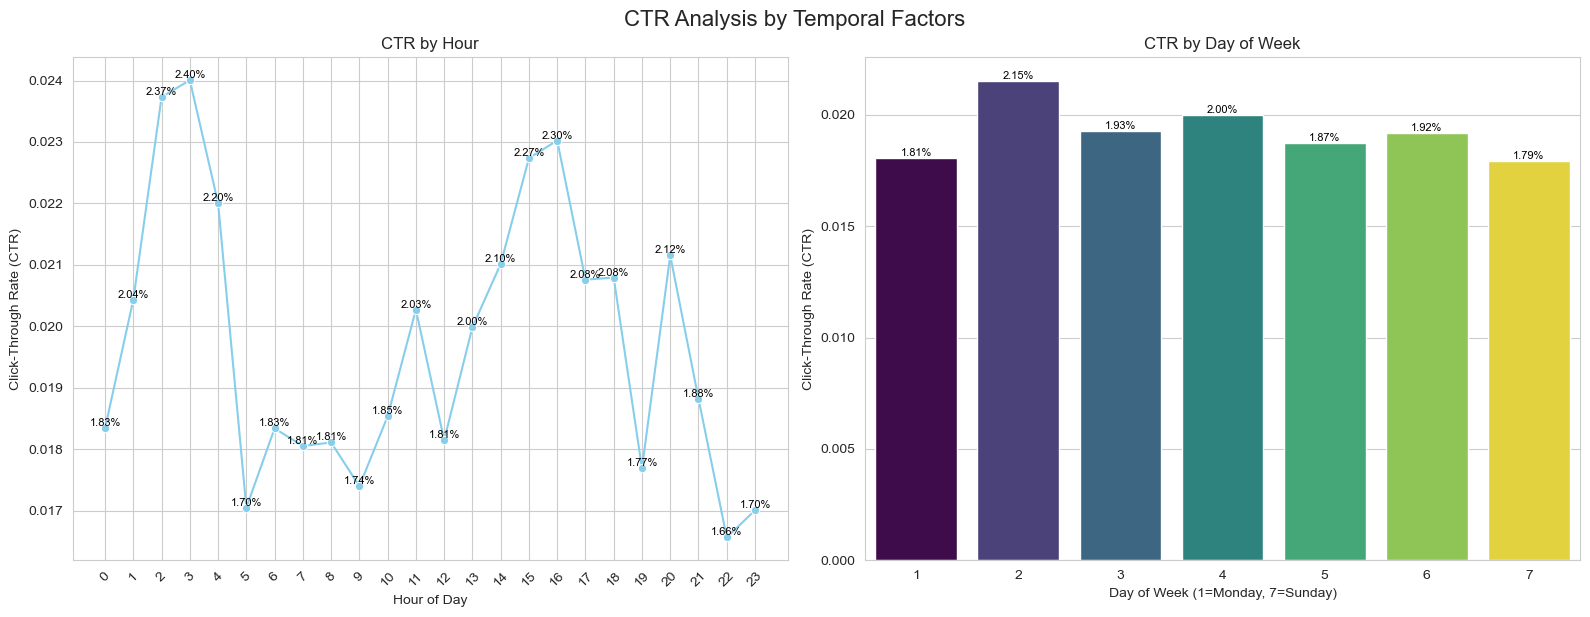

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ensure 'clicked' column is int for consistent calculations
train_sample_processed = train_sample.copy()
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. Calculate CTR by hour
hour_ctr = train_sample_processed.groupby('hour')['clicked'].mean().reset_index()
hour_ctr.columns = ['hour', 'CTR']
hour_ctr['hour'] = hour_ctr['hour'].astype(int) # Explicitly convert 'hour' to int

# 2. Calculate CTR by day_of_week
day_of_week_ctr = train_sample_processed.groupby('day_of_week')['clicked'].mean().reset_index()
day_of_week_ctr.columns = ['day_of_week', 'CTR']
day_of_week_ctr['day_of_week'] = day_of_week_ctr['day_of_week'].astype(int) # Explicitly convert 'day_of_week' to int

print("CTR by Hour:")
print(hour_ctr.head())
print("\nCTR by Day of Week:")
print(day_of_week_ctr.head())

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Plot Hour CTR
sns.lineplot(x='hour', y='CTR', data=hour_ctr, marker='o', ax=axes[0], color='skyblue')
axes[0].set_title('CTR by Hour', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Click-Through Rate (CTR)')
axes[0].set_xticks(hour_ctr['hour'])
axes[0].tick_params(axis='x', rotation=45)
for index, row in hour_ctr.iterrows():
    axes[0].text(row['hour'], row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom", fontsize=8)

# 4. Plot Day of Week CTR
sns.barplot(x='day_of_week', y='CTR', data=day_of_week_ctr, hue='day_of_week', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('CTR by Day of Week', fontsize=12)
axes[1].set_xlabel('Day of Week (1=Monday, 7=Sunday)')
axes[1].set_ylabel('Click-Through Rate (CTR)')
for index, row in day_of_week_ctr.iterrows():
    axes[1].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom", fontsize=8)

# 5. Display plots
plt.tight_layout()
plt.suptitle('CTR Analysis by Temporal Factors', y=1.02, fontsize=16)
plt.show()

RQ2: Hour vs CTR — Statistical Tests
One-way ANOVA: F=1.5738, p=0.039390 *
Effect size eta2=0.000181  (small(<0.06))

Time Period (4 groups) ANOVA: F=3.6418, p=0.012137 n.s.

Tukey HSD post-hoc (time period):
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
Afternoon(12-16) Evening(17-20)  -0.0007  0.884 -0.0031  0.0017  False
Afternoon(12-16)  Morning(5-11)  -0.0024 0.0179 -0.0046 -0.0003   True
Afternoon(12-16)    Night(21-4)  -0.0021 0.0876 -0.0045  0.0002  False
  Evening(17-20)  Morning(5-11)  -0.0017 0.1859  -0.004  0.0005  False
  Evening(17-20)    Night(21-4)  -0.0015 0.4178 -0.0039   0.001  False
   Morning(5-11)    Night(21-4)   0.0003  0.986 -0.0018  0.0024  False
----------------------------------------------------------------------

RQ3: Day of Week vs CTR — Statistical Tests
One-way ANOVA: F=2.3074, p=0.031425 

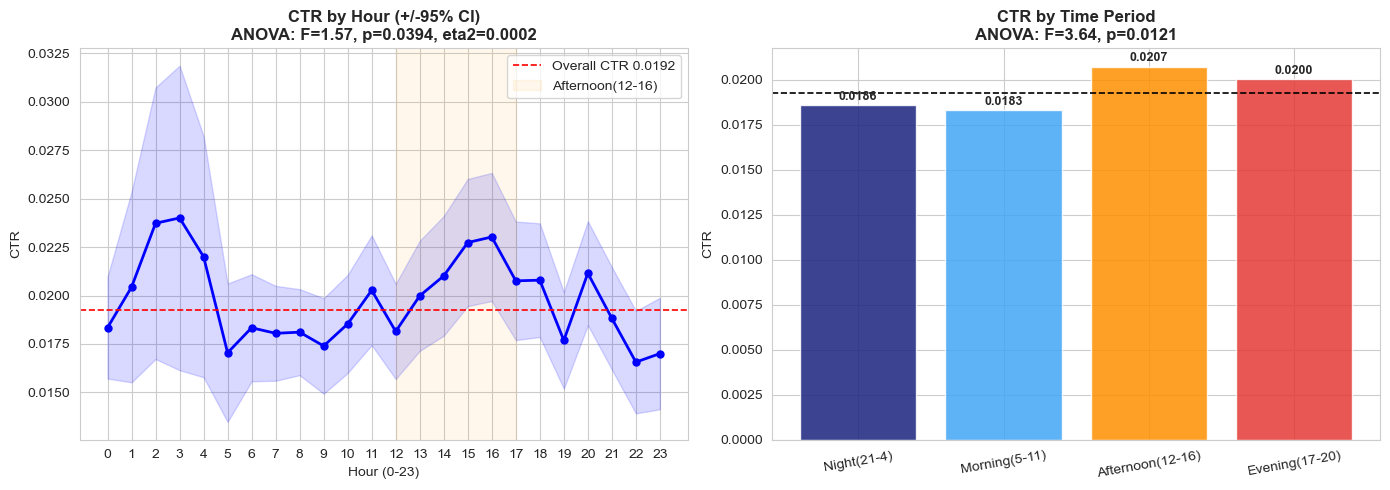


Conclusion:
  Hour  -> eta2=0.0002 — not significant temporal effect
  DoW   -> eta2=0.0001 — not significant day-of-week effect


In [12]:
# ================================================================
# Statistical Tests — Temporal Factors (Hour & Day of Week)
# Effect size: eta-squared, Tukey HSD post-hoc
# ================================================================
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grand_mean_temp = train_sample_processed['clicked'].mean()
ss_total_temp = ((train_sample_processed['clicked'] - grand_mean_temp) ** 2).sum()

# ── Hour: One-way ANOVA + eta-squared ───────────────────────────
hour_vals = sorted(train_sample_processed['hour'].dropna().unique())
hour_samples_t = [
    train_sample_processed[train_sample_processed['hour'] == h]['clicked'].values
    for h in hour_vals
]
F_hour_t, p_hour_t = f_oneway(*hour_samples_t)
ss_between_h = sum(len(s) * (s.mean() - grand_mean_temp) ** 2 for s in hour_samples_t if len(s) > 0)
eta_sq_hour = ss_between_h / ss_total_temp

print("=" * 60)
print("RQ2: Hour vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA: F={F_hour_t:.4f}, p={p_hour_t:.6f} "
      f"{'***' if p_hour_t<0.001 else '**' if p_hour_t<0.01 else '*' if p_hour_t<0.05 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_hour:.6f}  "
      f"({'large(>=0.14)' if eta_sq_hour>=0.14 else 'medium(>=0.06)' if eta_sq_hour>=0.06 else 'small(<0.06)'})")

# Time period (4 buckets): Tukey HSD
def _get_period_label(h):
    if 5 <= h < 12:    return 'Morning(5-11)'
    elif 12 <= h < 17: return 'Afternoon(12-16)'
    elif 17 <= h < 21: return 'Evening(17-20)'
    else:              return 'Night(21-4)'

period_col = train_sample_processed['hour'].astype(int).apply(_get_period_label)
tod_df_stat = pd.DataFrame({'period': period_col, 'clicked': train_sample_processed['clicked']})
period_uniq = tod_df_stat['period'].unique()
period_samples_t = [tod_df_stat[tod_df_stat['period'] == p]['clicked'].values for p in period_uniq]
F_period_t, p_period_t = f_oneway(*period_samples_t)

tukey_period_res = pairwise_tukeyhsd(
    endog=tod_df_stat['clicked'], groups=tod_df_stat['period'], alpha=0.05
)
print(f"\nTime Period (4 groups) ANOVA: F={F_period_t:.4f}, p={p_period_t:.6f} "
      f"{'***' if p_period_t<0.001 else 'n.s.'}")
print("\nTukey HSD post-hoc (time period):")
print(tukey_period_res.summary())

# ── Day of Week: One-way ANOVA + eta-squared ────────────────────
dow_vals = sorted(train_sample_processed['day_of_week'].dropna().unique())
dow_samples_t = [
    train_sample_processed[train_sample_processed['day_of_week'] == d]['clicked'].values
    for d in dow_vals
]
F_dow_t, p_dow_t = f_oneway(*dow_samples_t)
ss_between_d = sum(len(s) * (s.mean() - grand_mean_temp) ** 2 for s in dow_samples_t if len(s) > 0)
eta_sq_dow = ss_between_d / ss_total_temp

print("\n" + "=" * 60)
print("RQ3: Day of Week vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA: F={F_dow_t:.4f}, p={p_dow_t:.6f} "
      f"{'***' if p_dow_t<0.001 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_dow:.6f}  "
      f"({'large(>=0.14)' if eta_sq_dow>=0.14 else 'medium(>=0.06)' if eta_sq_dow>=0.06 else 'small(<0.06)'})")

# ── Visualization ────────────────────────────────────────────────
hour_desc = train_sample_processed.groupby('hour')['clicked'].agg(
    n='count', ctr='mean', std='std'
).reset_index()
hour_desc['ci95'] = 1.96 * (hour_desc['std'] / np.sqrt(hour_desc['n']))
h_vals_plot = hour_desc['hour'].astype(int).tolist()

period_order = ['Night(21-4)', 'Morning(5-11)', 'Afternoon(12-16)', 'Evening(17-20)']
period_ctr = tod_df_stat.groupby('period')['clicked'].mean().reindex(period_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h_vals_plot, hour_desc['ctr'], 'b-o', linewidth=2, markersize=5)
axes[0].fill_between(h_vals_plot,
                     hour_desc['ctr'] - hour_desc['ci95'],
                     hour_desc['ctr'] + hour_desc['ci95'],
                     alpha=0.15, color='blue')
axes[0].axhline(grand_mean_temp, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {grand_mean_temp:.4f}')
axes[0].axvspan(12, 17, alpha=0.08, color='orange', label='Afternoon(12-16)')
axes[0].set_title(
    f'CTR by Hour (+/-95% CI)\n'
    f'ANOVA: F={F_hour_t:.2f}, p={p_hour_t:.4f}, eta2={eta_sq_hour:.4f}',
    fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('CTR')
axes[0].legend()
axes[0].set_xticks(range(24))

colors_period = ['#1a237e', '#42a5f5', '#ff8f00', '#e53935'][:len(period_ctr)]
bars = axes[1].bar(range(len(period_ctr)), period_ctr.values,
                   color=colors_period, alpha=0.85)
axes[1].axhline(grand_mean_temp, color='black', linestyle='--', linewidth=1.2)
for b, v in zip(bars, period_ctr.values):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.0003,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(period_ctr)))
axes[1].set_xticklabels(period_ctr.index, rotation=10)
axes[1].set_title(
    f'CTR by Time Period\n'
    f'ANOVA: F={F_period_t:.2f}, p={p_period_t:.4f}',
    fontweight='bold')
axes[1].set_ylabel('CTR')

plt.tight_layout()
plt.savefig('RQ2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConclusion:")
print(f"  Hour  -> eta2={eta_sq_hour:.4f} — "
      f"{'significant' if p_hour_t<0.001 else 'not significant'} temporal effect")
print(f"  DoW   -> eta2={eta_sq_dow:.4f} — "
      f"{'significant' if p_dow_t<0.001 else 'not significant'} day-of-week effect")

In [13]:
# === 시간대·요일별 CTR 분석 완료. 다음: 피처 엔지니어링 (상호작용 피처) ===

- ✅ CTR 1.98%, 남녀 차이 거의 없음
- 👶 연령 1.0대 CTR 4.63%로 가장 높음
- 🕒 새벽 3시·오후 2–4시 클릭률 상승 구간
- 📅 금요일(5요일) CTR 최고, 목요일보다 우세
- 🎯 다음 단계: 상관관계·연령1.0대·시간대 분석 및 Logistic 베이스라인 구축

In [14]:
# day_of_week 타입 혼재(str/int)로 인한 비교 오류 방지
if 'day_of_week' in df.columns:
    _dow = pd.to_numeric(df['day_of_week'], errors='coerce')
    if _dow.isna().any():
        print(f"[보정] day_of_week 비수치 값 {int(_dow.isna().sum())}개를 -1로 대체")
    df['day_of_week'] = _dow.fillna(-1).astype(int)
    print('[보정] day_of_week dtype ->', df['day_of_week'].dtype)
else:
    print('[경고] day_of_week 컬럼이 없어 시간/요일 패턴 분석 셀에서 오류가 날 수 있습니다.')

[보정] day_of_week dtype -> int32



⏰ Temporal Pattern Analysis
📊 Hourly Statistics (Top 5):
      Total_Samples  Clicks  Click_Rate
hour                                   
03             1458      35      0.0240
02             1812      43      0.0237
16             7905     182      0.0230
15             7917     180      0.0227
04             2136      47      0.0220

📊 Day-of-Week Statistics:
           Total_Samples  Clicks  Click_Rate
Tuesday            28362     512      0.0181
Wednesday          28729     618      0.0215
Thursday           28512     550      0.0193
Friday             28838     577      0.0200
Saturday           28505     534      0.0187
Sunday             28505     547      0.0192
Day_7              28549     512      0.0179


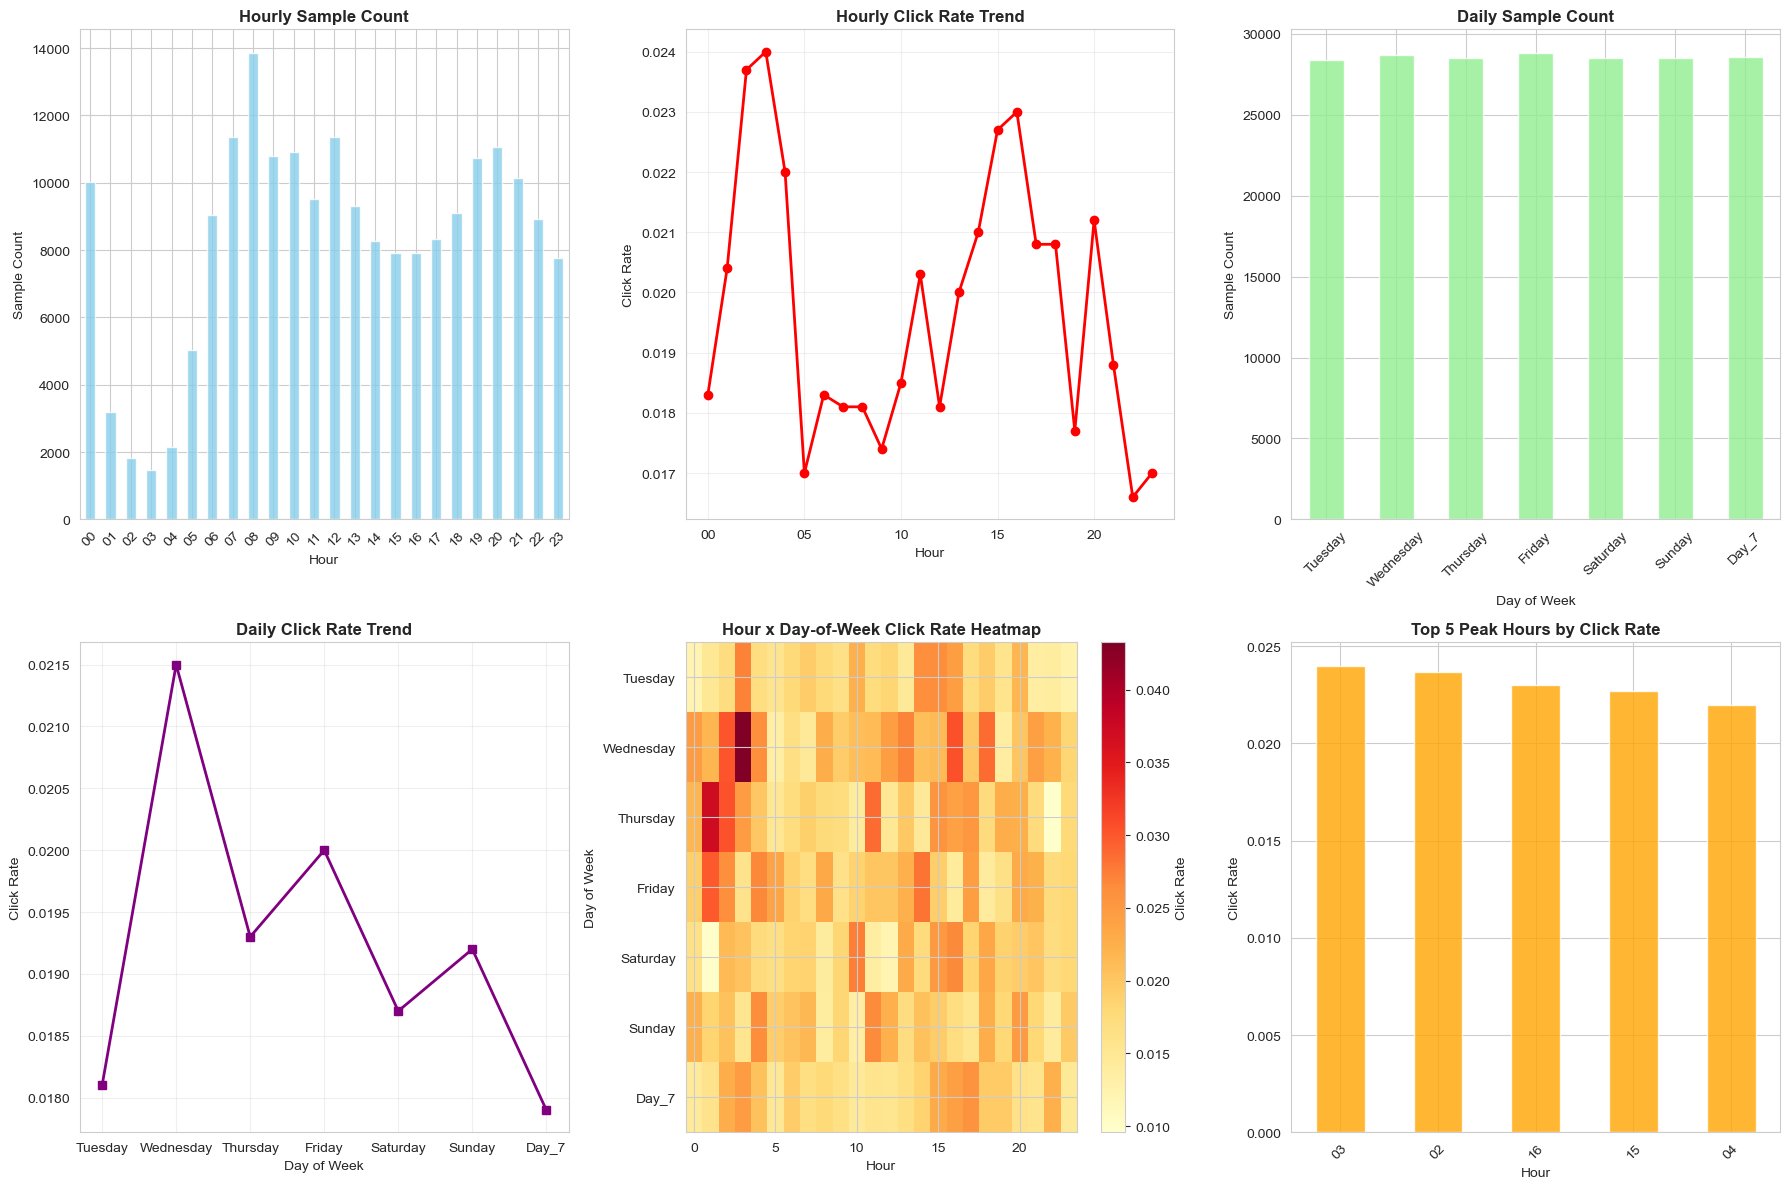


🕐 Temporal Pattern Insights:
   Peak Click Rate Hour: 03 (0.0240)
   Lowest Click Rate Hour: 22 (0.0166)
   Peak Click Rate Day: Wednesday (0.0215)
   Lowest Click Rate Day: Day_7 (0.0179)


In [15]:

# ========================================
# ⏰ 3. Temporal Pattern Analysis
# ========================================

print("\n" + "="*60)
print("⏰ Temporal Pattern Analysis")
print("="*60)

# Hourly Statistics
hourly_stats = df.groupby('hour').agg({
    'clicked': ['count', 'sum', 'mean']
})
hourly_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']
hourly_stats = hourly_stats.round(4)

print("📊 Hourly Statistics (Top 5):")
print(hourly_stats.sort_values('Click_Rate', ascending=False).head())

# Day-of-Week Statistics (day_of_week: 0=Mon ~ 6=Sun, 0-indexed)
daily_stats = df.groupby('day_of_week').agg({
    'clicked': ['count', 'sum', 'mean']
})
daily_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']
daily_stats = daily_stats.round(4)

print(f"\n📊 Day-of-Week Statistics:")
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats.index = [day_names[i] if i < len(day_names) else f'Day_{i}' for i in daily_stats.index]
print(daily_stats)

# Temporal Pattern Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Hourly Sample Count
hourly_stats['Total_Samples'].plot(kind='bar', ax=axes[0,0], color='skyblue', alpha=0.8)
axes[0,0].set_title('Hourly Sample Count', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Sample Count')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Hourly Click Rate Trend
hourly_stats['Click_Rate'].plot(kind='line', ax=axes[0,1], color='red', marker='o', linewidth=2)
axes[0,1].set_title('Hourly Click Rate Trend', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Click Rate')
axes[0,1].grid(True, alpha=0.3)

# 3. Daily Sample Count
daily_stats['Total_Samples'].plot(kind='bar', ax=axes[0,2], color='lightgreen', alpha=0.8)
axes[0,2].set_title('Daily Sample Count', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Day of Week')
axes[0,2].set_ylabel('Sample Count')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Daily Click Rate Trend
daily_stats['Click_Rate'].plot(kind='line', ax=axes[1,0], color='purple', marker='s', linewidth=2)
axes[1,0].set_title('Daily Click Rate Trend', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Click Rate')
axes[1,0].grid(True, alpha=0.3)

# 5. Hour x Day-of-Week Heatmap (Click Rate)
pivot_table = df.groupby(['day_of_week', 'hour'])['clicked'].mean().unstack()
im = axes[1,1].imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
axes[1,1].set_title('Hour x Day-of-Week Click Rate Heatmap', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Day of Week')
axes[1,1].set_yticks(range(len(pivot_table.index)))
axes[1,1].set_yticklabels([day_names[i] if i < len(day_names) else f'Day_{i}' for i in pivot_table.index])
plt.colorbar(im, ax=axes[1,1], label='Click Rate')

# 6. Peak Hour Analysis
peak_hours = hourly_stats.nlargest(5, 'Click_Rate')
peak_hours.index.name = 'Hour'
peak_hours['Click_Rate'].plot(kind='bar', ax=axes[1,2], color='orange', alpha=0.8)
axes[1,2].set_title('Top 5 Peak Hours by Click Rate', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Hour')
axes[1,2].set_ylabel('Click Rate')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Temporal Pattern Insights
print(f"\n🕐 Temporal Pattern Insights:")
peak_hour = hourly_stats['Click_Rate'].idxmax()
low_hour = hourly_stats['Click_Rate'].idxmin()
print(f"   Peak Click Rate Hour: {peak_hour} ({hourly_stats.loc[peak_hour, 'Click_Rate']:.4f})")
print(f"   Lowest Click Rate Hour: {low_hour} ({hourly_stats.loc[low_hour, 'Click_Rate']:.4f})")

peak_day = daily_stats['Click_Rate'].idxmax()
low_day = daily_stats['Click_Rate'].idxmin()
print(f"   Peak Click Rate Day: {peak_day} ({daily_stats.loc[peak_day, 'Click_Rate']:.4f})")
print(f"   Lowest Click Rate Day: {low_day} ({daily_stats.loc[low_day, 'Click_Rate']:.4f})")


👥 User Segment Analysis
📊 Gender Statistics:
        Total_Samples  Clicks  Click_Rate
gender                                   
1.0            125629    2550      0.0203
2.0             74045    1292      0.0174

📊 Age Group Statistics:
           Total_Samples  Clicks  Click_Rate
age_group                                   
1.0                  493      38      0.0771
8.0                49459    1135      0.0229
2.0                 6832     151      0.0221
3.0                 8875     183      0.0206
4.0                10253     191      0.0186
7.0                68982    1238      0.0179
6.0                43596     726      0.0167
5.0                11184     180      0.0161

📊 Gender x Age Group Cross Analysis (Top 10 by Click Rate):
                  Total_Samples  Clicks  Click_Rate
gender age_group                                   
2.0    1.0                  213      17      0.0798
1.0    1.0                  280      21      0.0750
2.0    3.0                 3739      97   

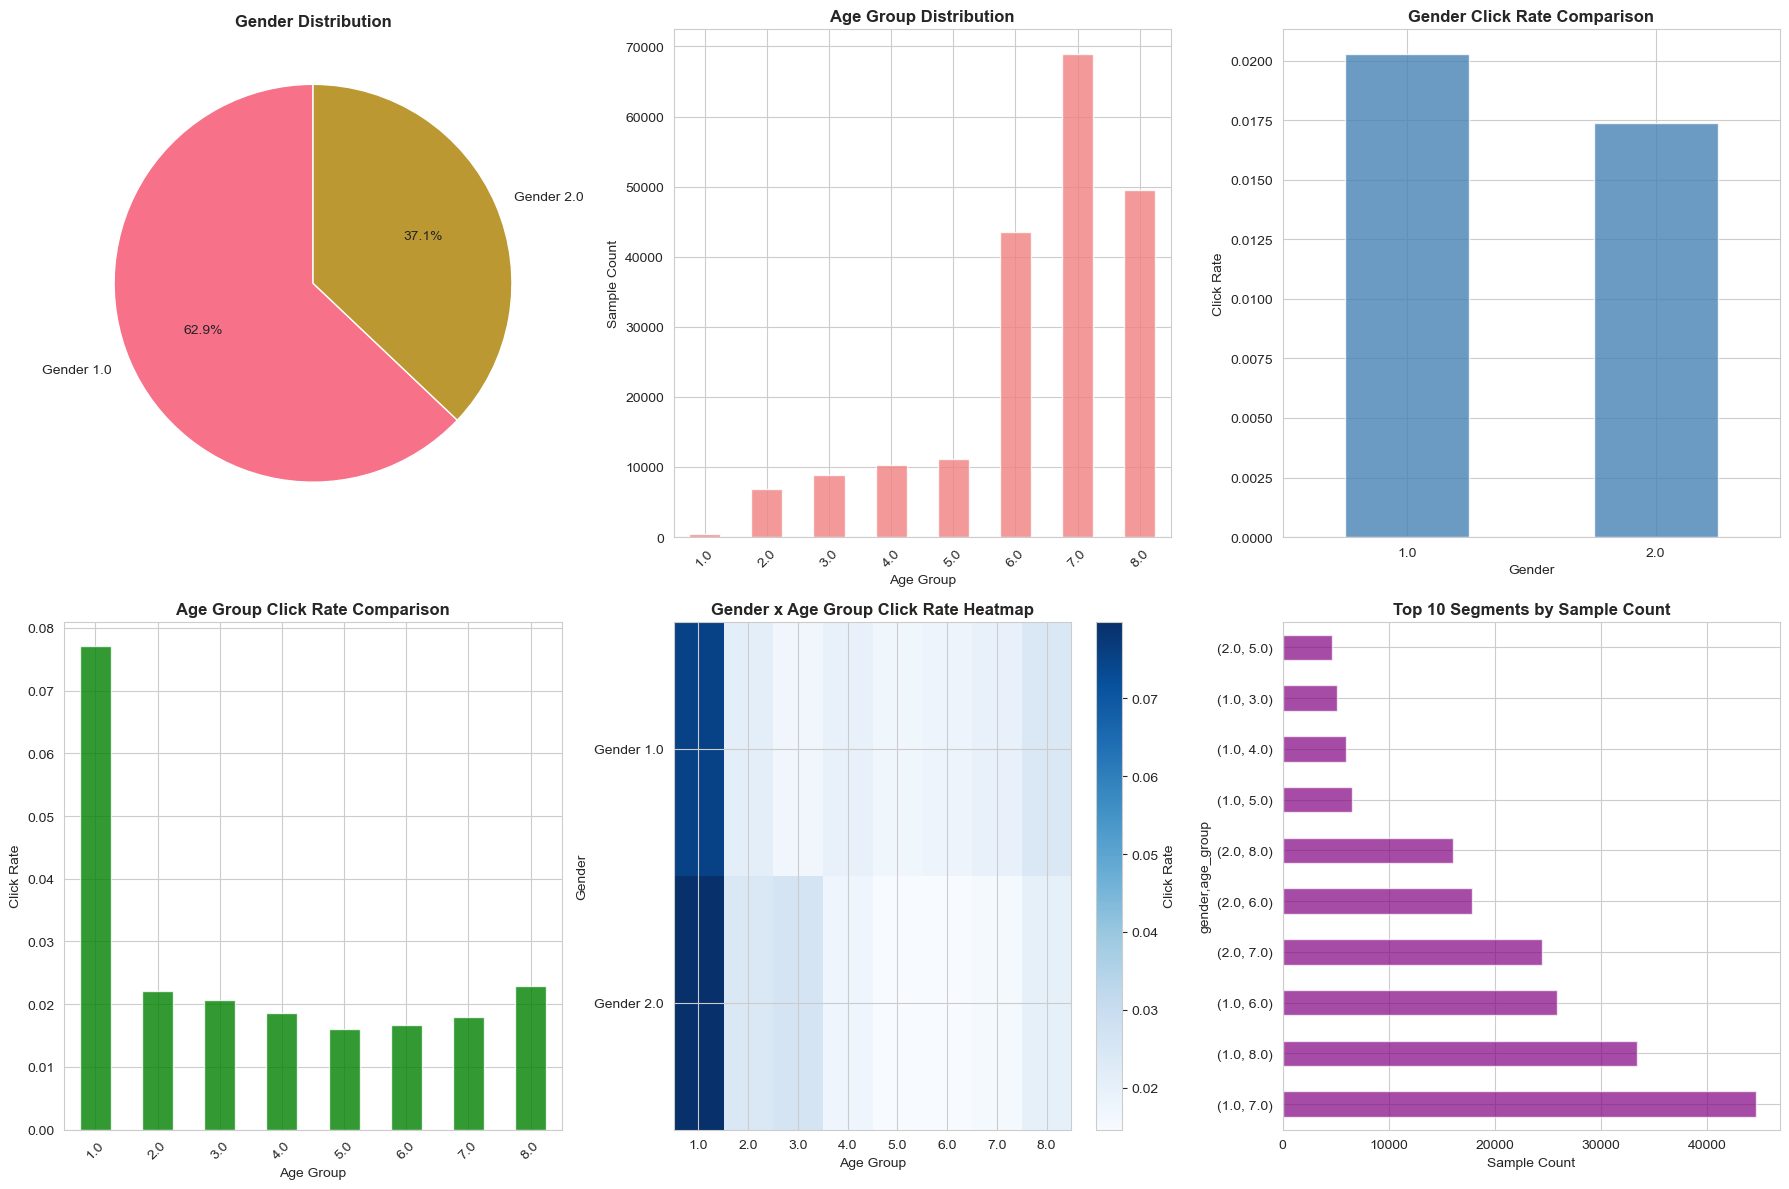


👥 Segment Insights:
   Best Click Rate Gender: Gender 1.0 (0.0203)
   Best Click Rate Age Group: Age 1.0 (0.0771)
   Best Click Rate Segment: Gender 2.0, Age 1.0 (0.0798)


In [16]:

# ========================================
# 👥 4. User Segment Analysis
# ========================================

print("\n" + "="*60)
print("👥 User Segment Analysis")
print("="*60)

# Gender Analysis
gender_stats = df.groupby('gender').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
gender_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']

print("📊 Gender Statistics:")
print(gender_stats)

# Age Group Analysis
age_stats = df.groupby('age_group').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
age_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']

print(f"\n📊 Age Group Statistics:")
print(age_stats.sort_values('Click_Rate', ascending=False))

# Gender x Age Group Cross Analysis
cross_analysis = df.groupby(['gender', 'age_group']).agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
cross_analysis.columns = ['Total_Samples', 'Clicks', 'Click_Rate']

print(f"\n📊 Gender x Age Group Cross Analysis (Top 10 by Click Rate):")
print(cross_analysis.sort_values('Click_Rate', ascending=False).head(10))

# User Segment Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Gender Distribution
gender_counts = df['gender'].value_counts()
axes[0,0].pie(gender_counts.values, labels=[f'Gender {i}' for i in gender_counts.index], 
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# 2. Age Group Distribution
age_counts = df['age_group'].value_counts().sort_index()
age_counts.plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
axes[0,1].set_title('Age Group Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Sample Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Gender Click Rate Comparison
gender_stats['Click_Rate'].plot(kind='bar', ax=axes[0,2], color='steelblue', alpha=0.8)
axes[0,2].set_title('Gender Click Rate Comparison', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Gender')
axes[0,2].set_ylabel('Click Rate')
axes[0,2].tick_params(axis='x', rotation=0)

# 4. Age Group Click Rate Comparison
age_stats['Click_Rate'].plot(kind='bar', ax=axes[1,0], color='green', alpha=0.8)
axes[1,0].set_title('Age Group Click Rate Comparison', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Click Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Gender x Age Group Heatmap (Click Rate)
pivot_cross = df.groupby(['gender', 'age_group'])['clicked'].mean().unstack(fill_value=0)
im2 = axes[1,1].imshow(pivot_cross.values, cmap='Blues', aspect='auto')
axes[1,1].set_title('Gender x Age Group Click Rate Heatmap', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Gender')
axes[1,1].set_yticks(range(len(pivot_cross.index)))
axes[1,1].set_yticklabels([f'Gender {i}' for i in pivot_cross.index])
axes[1,1].set_xticks(range(len(pivot_cross.columns)))
axes[1,1].set_xticklabels(pivot_cross.columns)
plt.colorbar(im2, ax=axes[1,1], label='Click Rate')

# 6. Segment Sample Count Comparison
cross_samples = df.groupby(['gender', 'age_group']).size().sort_values(ascending=False).head(10)
cross_samples.plot(kind='barh', ax=axes[1,2], color='purple', alpha=0.7)
axes[1,2].set_title('Top 10 Segments by Sample Count', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Sample Count')

plt.tight_layout()
plt.show()

# Segment Insights
print(f"\n👥 Segment Insights:")
best_gender = gender_stats['Click_Rate'].idxmax()
best_age = age_stats['Click_Rate'].idxmax()
best_segment = cross_analysis['Click_Rate'].idxmax()

print(f"   Best Click Rate Gender: Gender {best_gender} ({gender_stats.loc[best_gender, 'Click_Rate']:.4f})")
print(f"   Best Click Rate Age Group: Age {best_age} ({age_stats.loc[best_age, 'Click_Rate']:.4f})")
print(f"   Best Click Rate Segment: Gender {best_segment[0]}, Age {best_segment[1]} ({cross_analysis.loc[best_segment, 'Click_Rate']:.4f})")

---
## 3. 통계 검정 — 연구 질문 RQ1~RQ4 <a id='sec3'></a>

In [17]:
# ================================================================
# 📌 토스 광고 CTR 분석 — 연구계획서 기반 통합 분석 코드
# ================================================================
# 연구 제목: 사용자 특성과 광고 노출 환경이 CTR에 미치는 영향 분석
# 평가 지표: Average Precision (AP), Weighted LogLoss (WLL, 50:50)
# 연구 문제:
#   RQ1. 연령대(age_group)에 따라 CTR에 유의미한 차이가 있는가?
#   RQ2. 시간대(hour)에 따라 클릭 패턴이 어떻게 달라지는가?
#   RQ3. 광고 노출 환경(inventory_id, day_of_week)이 CTR에 미치는 영향?
#   RQ4. 사용자 특성+노출 환경을 함께 고려하면 CTR 예측이 향상되는가?
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("📌 토스 CTR 분석 — 연구계획서 통합 코드")
print("=" * 65)

# ── 데이터 로드 ──────────────────────────────────────────────────
df = train.copy()  # 섹션 1에서 로드한 train_sample 재사용

# ── 기본 파생 변수 (전체 분석에서 공유) ──────────────────────────
df['seq_length']      = df['seq'].str.split(',').str.len()
df['unique_items']    = df['seq'].apply(lambda x: len(set(x.split(','))))
df['diversity_ratio'] = df['unique_items'] / df['seq_length']
df['repeat_ratio']    = 1 - df['diversity_ratio']

# 타입 보정: hour/day_of_week 혼합형(str/int) -> int
df['hour'] = pd.to_numeric(df['hour'], errors='coerce').fillna(-1).astype(int)
df['day_of_week'] = pd.to_numeric(df['day_of_week'], errors='coerce').fillna(-1).astype(int)

# 시간 구간 (심야/오전/오후/저녁)
df['hour_period'] = pd.cut(
    df['hour'], bins=[-1,5,11,17,23],
    labels=['심야(0-5)','오전(6-11)','오후(12-17)','저녁(18-23)']
)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_peak_hour'] = df['hour'].between(12,18).astype(int)

# 히스토리 집계
hist_a = [c for c in df.columns if c.startswith('history_a_')]
hist_b = [c for c in df.columns if c.startswith('history_b_')]
df['history_a_sum']  = df[hist_a].fillna(0).sum(axis=1)
df['history_b_sum']  = df[hist_b].fillna(0).sum(axis=1)
df['history_a_mean'] = df[hist_a].fillna(0).mean(axis=1)
df['history_b_mean'] = df[hist_b].fillna(0).mean(axis=1)
df['history_a_max']  = df[hist_a].fillna(0).max(axis=1)
df['history_b_max']  = df[hist_b].fillna(0).max(axis=1)
df['history_ab_ratio'] = (df['history_a_sum']+1e-6) / (df['history_b_sum']+1e-6)

# 지면 CTR 타깃 인코딩
inv_ctr = df.groupby('inventory_id')['clicked'].mean()
df['inv_ctr_encoded'] = df['inventory_id'].map(inv_ctr)

GLOBAL_CTR = df['clicked'].mean()

print(f"\n📊 데이터: {len(df):,}샘플 / {df['clicked'].sum():,}클릭")
print(f"   전체 CTR: {GLOBAL_CTR:.4f} ({GLOBAL_CTR*100:.2f}%)")
print(f"   클래스 불균형: {(1-GLOBAL_CTR)/GLOBAL_CTR:.1f}:1")
print(f"\n✅ 기본 파생 변수 {20}개 생성 완료")

📌 토스 CTR 분석 — 연구계획서 통합 코드

📊 데이터: 200,000샘플 / 3,850클릭
   전체 CTR: 0.0192 (1.93%)
   클래스 불균형: 50.9:1

✅ 기본 파생 변수 20개 생성 완료


### RQ1. 연령대(age_group)에 따라 CTR에 유의미한 차이가 있는가?


📊 RQ1. Age Group vs Click-Through Rate Analysis

[Descriptive Statistics] Click Rate by Age Group:
           Sample_Count  Click_Count  Click_Rate  Std_Dev  CI_95_Lower  CI_95_Upper
age_group                                                                          
1.0                 493           38      0.0771   0.2670       0.0535       0.1007
2.0                6832          151      0.0221   0.1470       0.0186       0.0256
3.0                8875          183      0.0206   0.1421       0.0176       0.0236
4.0               10253          191      0.0186   0.1352       0.0160       0.0212
5.0               11184          180      0.0161   0.1258       0.0138       0.0184
6.0               43596          726      0.0167   0.1280       0.0155       0.0179
7.0               68982         1238      0.0179   0.1328       0.0169       0.0189
8.0               49459         1135      0.0229   0.1497       0.0216       0.0242

[One-way ANOVA]  F=22.1507, p=0.000000 ***
[Kruskal-Wallis]

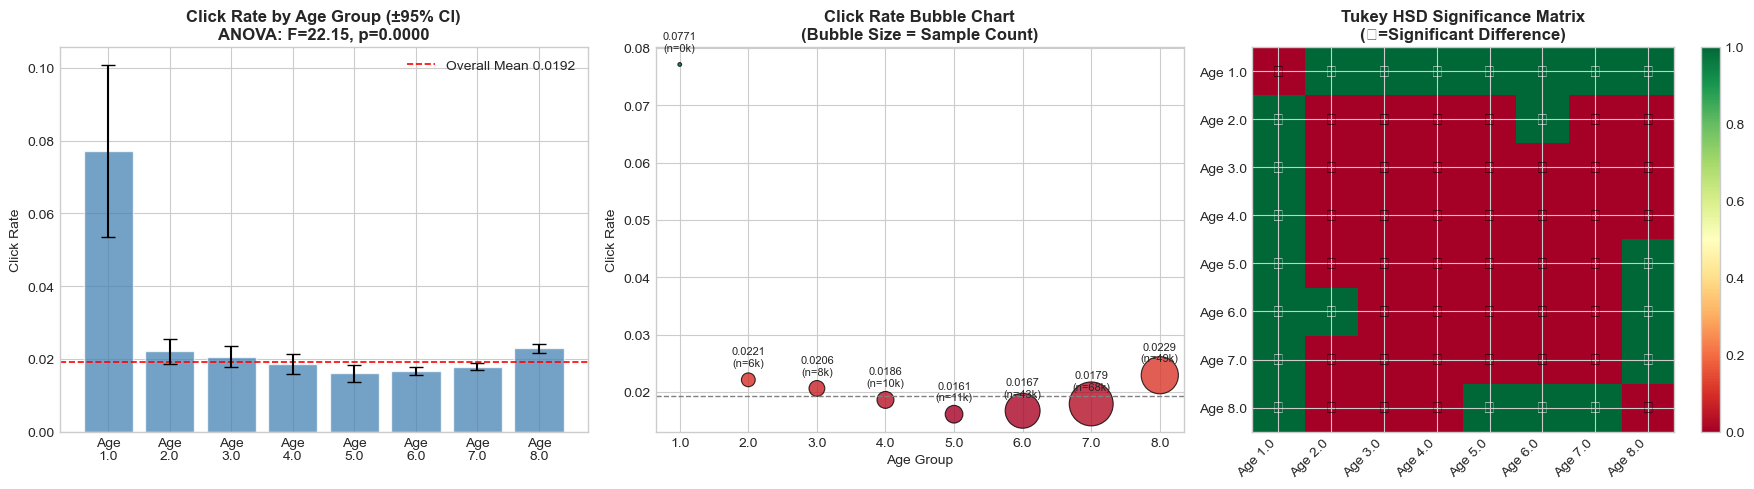


✅ RQ1 Conclusion: Significant age group differences in Click Rate exist (p<0.001)


In [18]:
# ================================================================
# 📊 RQ1. Does Click-Through Rate Significantly Differ by Age Group?
# ================================================================

from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n" + "="*65)
print("📊 RQ1. Age Group vs Click-Through Rate Analysis")
print("="*65)

age_groups  = sorted(df['age_group'].dropna().unique())
age_samples = [df[df['age_group']==ag]['clicked'].values for ag in age_groups]

# Descriptive Statistics
age_desc = df.groupby('age_group')['clicked'].agg(
    Sample_Count='count', Click_Count='sum', Click_Rate='mean', Std_Dev='std'
).round(4)
age_desc['CI_95_Lower'] = age_desc['Click_Rate'] - 1.96*(age_desc['Std_Dev']/np.sqrt(age_desc['Sample_Count']))
age_desc['CI_95_Upper'] = age_desc['Click_Rate'] + 1.96*(age_desc['Std_Dev']/np.sqrt(age_desc['Sample_Count']))
print("\n[Descriptive Statistics] Click Rate by Age Group:")
print(age_desc.round(4).to_string())

# One-way ANOVA
F_age, p_anova_age = f_oneway(*age_samples)
H_age, p_kruskal_age = kruskal(*age_samples)

print(f"\n[One-way ANOVA]  F={F_age:.4f}, p={p_anova_age:.6f}",
      "***" if p_anova_age<0.001 else "")
print(f"[Kruskal-Wallis] H={H_age:.4f}, p={p_kruskal_age:.6f}",
      "***" if p_kruskal_age<0.001 else "")

# Tukey HSD Post-Hoc Test
_mask_age = df['age_group'].notna()
tukey_age = pairwise_tukeyhsd(
    endog=df.loc[_mask_age, 'clicked'],
    groups=df.loc[_mask_age, 'age_group'], alpha=0.05
)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) CTR with 95% CI
ci_lo = age_desc['CI_95_Lower'].values
ci_hi = age_desc['CI_95_Upper'].values
ctrs  = age_desc['Click_Rate'].values
x_pos = range(len(age_groups))
axes[0].bar(x_pos, ctrs, color='steelblue', alpha=0.75, zorder=2)
axes[0].errorbar(x_pos, ctrs,
                 yerr=[ctrs-ci_lo, ci_hi-ctrs],
                 fmt='none', color='black', capsize=5, linewidth=1.5, zorder=3)
axes[0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall Mean {GLOBAL_CTR:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age\n{ag}' for ag in age_groups])
axes[0].set_title(f'Click Rate by Age Group (±95% CI)\nANOVA: F={F_age:.2f}, p={p_anova_age:.4f}',
                  fontweight='bold')
axes[0].set_ylabel('Click Rate')
axes[0].legend()

# 2) Bubble Chart - Sample Size vs Click Rate
bubble_size = age_desc['Sample_Count'] / age_desc['Sample_Count'].max() * 1000
axes[1].scatter(age_groups, ctrs, s=bubble_size,
                c=ctrs, cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidths=0.8)
axes[1].axhline(GLOBAL_CTR, color='gray', linestyle='--', linewidth=1)
for ag, ctr, s in zip(age_groups, ctrs, age_desc['Sample_Count'].values):
    axes[1].annotate(f'{ctr:.4f}\n(n={s//1000}k)',
                     (ag, ctr), textcoords='offset points',
                     xytext=(0,10), ha='center', fontsize=8)
axes[1].set_title('Click Rate Bubble Chart\n(Bubble Size = Sample Count)', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Click Rate')

# 3) Tukey HSD Significance Matrix
n = len(age_groups)
sig_mat = np.zeros((n, n))
age_index = {str(v): idx for idx, v in enumerate(age_groups)}

for row in tukey_age.summary().data[1:]:
    g1, g2 = row[0], row[1]
    reject_raw = row[-1]
    if isinstance(reject_raw, str):
        reject = reject_raw.strip().lower() == 'true'
    else:
        reject = bool(reject_raw)

    i = age_index.get(str(g1))
    j = age_index.get(str(g2))
    if i is None or j is None:
        continue

    sig_mat[i, j] = sig_mat[j, i] = 1 if reject else 0

mask = np.eye(n, dtype=bool)
im = axes[2].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[2].set_xticks(range(n)); axes[2].set_yticks(range(n))
axes[2].set_xticklabels([f'Age {ag}' for ag in age_groups], rotation=45, ha='right')
axes[2].set_yticklabels([f'Age {ag}' for ag in age_groups])
for i in range(n):
    for j in range(n):
        axes[2].text(j, i, '✓' if sig_mat[i,j] else '✗',
                     ha='center', va='center',
                     color='white' if sig_mat[i,j] else 'black', fontsize=12)
axes[2].set_title('Tukey HSD Significance Matrix\n(✓=Significant Difference)', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('RQ1_age_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ1 Conclusion:",
      "Significant age group differences in Click Rate exist (p<0.001)"
      if p_anova_age < 0.001 else
      "Age group differences in Click Rate are not statistically significant")

### RQ2. 시간대(hour)에 따라 클릭 패턴이 어떻게 달라지는가?


⏰ RQ2. Hourly Click Pattern Analysis

[Descriptive Statistics] Click Rate by Time Period:
             Sample_Count  Click_Count  Click_Rate
hour_period                                       
심야(0-5)             23665          460      0.0194
오전(6-11)            65498         1205      0.0184
오후(12-17)           53095         1101      0.0207
저녁(18-23)           57742         1084      0.0188

[One-way ANOVA] 24-hour: F=1.57, p=0.039390 
[One-way ANOVA] 4-period: F=nan, p=nan 
[Kruskal-Wallis] H=36.20, p=0.039399 

[Tukey HSD] Pairwise Comparison:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
  심야(0-5)  오전(6-11)   -0.001 0.7503 -0.0037 0.0016  False
  심야(0-5) 오후(12-17)   0.0013 0.6211 -0.0015 0.0041  False
  심야(0-5) 저녁(18-23)  -0.0007 0.9235 -0.0034 0.0021  False
 오전(6-11) 오후(12-17)   0.0023 0.0187  0.0003 0.0044   True
 오전(6-11) 저녁(18-23)   0.0004 0.9638 -0.

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


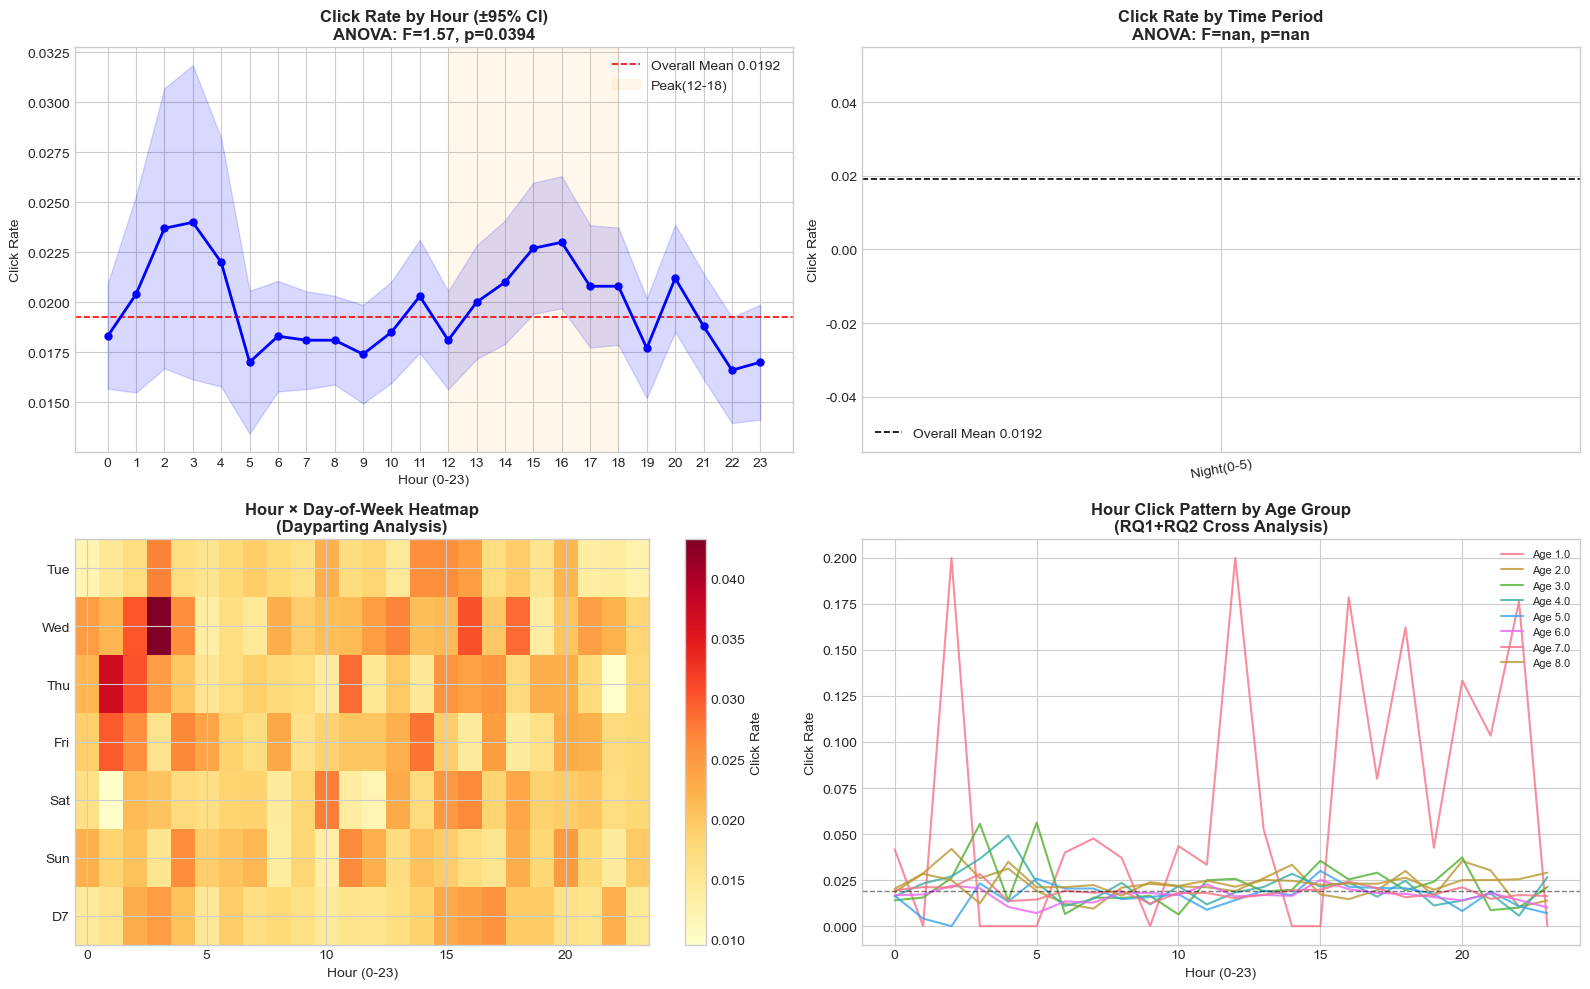


✅ RQ2 Conclusion:


In [19]:
# ================================================================
# ⏰ RQ2. How Do Click Patterns Vary by Hour of Day?
# ================================================================

from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n" + "="*65)
print("⏰ RQ2. Hourly Click Pattern Analysis")
print("="*65)

# Hourly Descriptive Statistics
hour_desc = df.groupby('hour')['clicked'].agg(
    Sample_Count='count', Click_Count='sum', Click_Rate='mean', Std_Dev='std'
).round(4)
hour_desc['CI_95'] = 1.96 * (hour_desc['Std_Dev'] / np.sqrt(hour_desc['Sample_Count']))

# Time Period Statistics
period_desc = df.groupby('hour_period', observed=True)['clicked'].agg(
    Sample_Count='count', Click_Count='sum', Click_Rate='mean'
).round(4)
print("\n[Descriptive Statistics] Click Rate by Time Period:")
print(period_desc.to_string())

# ANOVA: 24-hour basis
hour_samples  = [df[df['hour']==h]['clicked'].values for h in range(24)]
F_hour, p_hour = f_oneway(*hour_samples)
H_hour, p_krus_hour = kruskal(*hour_samples)

# ANOVA: 4 time periods
period_labels = ['Night(0-5)','Morning(6-11)','Afternoon(12-17)','Evening(18-23)']
period_samples = [df[df['hour_period']==p]['clicked'].values for p in period_labels]
F_period, p_period = f_oneway(*period_samples)

# Tukey HSD (4 periods)
period_data = df[['hour_period','clicked']].dropna()
tukey_period = pairwise_tukeyhsd(
    endog=period_data['clicked'],
    groups=period_data['hour_period'], alpha=0.05
)

print(f"\n[One-way ANOVA] 24-hour: F={F_hour:.2f}, p={p_hour:.6f}",
      "***" if p_hour<0.001 else "")
print(f"[One-way ANOVA] 4-period: F={F_period:.2f}, p={p_period:.6f}",
      "***" if p_period<0.001 else "")
print(f"[Kruskal-Wallis] H={H_hour:.2f}, p={p_krus_hour:.6f}",
      "***" if p_krus_hour<0.001 else "")
print("\n[Tukey HSD] Pairwise Comparison:")
print(tukey_period.summary())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Hourly Click Rate with CI
h_ctrs = hour_desc['Click_Rate'].values
h_ci   = hour_desc['CI_95'].values
hours  = list(range(24))
axes[0,0].plot(hours, h_ctrs, 'b-o', linewidth=2, markersize=5, zorder=3)
axes[0,0].fill_between(hours, h_ctrs-h_ci, h_ctrs+h_ci, alpha=0.15, color='blue')
axes[0,0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
# Highlight peak period
axes[0,0].axvspan(12, 18, alpha=0.08, color='orange', label='Peak(12-18)')
axes[0,0].set_title(f'Click Rate by Hour (±95% CI)\nANOVA: F={F_hour:.2f}, p={p_hour:.4f}',
                    fontweight='bold')
axes[0,0].set_xlabel('Hour (0-23)')
axes[0,0].set_ylabel('Click Rate')
axes[0,0].legend()
axes[0,0].set_xticks(hours)

# 2) 4-period Bar Chart
period_ctrs = period_desc['Click_Rate'].reindex(period_labels)
colors_p = ['#1a237e','#42a5f5','#ff8f00','#e53935']
bars = axes[0,1].bar(period_labels, period_ctrs, color=colors_p, alpha=0.85)
axes[0,1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, period_ctrs):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.0003,
                   f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title(f'Click Rate by Time Period\nANOVA: F={F_period:.2f}, p={p_period:.4f}',
                    fontweight='bold')
axes[0,1].set_ylabel('Click Rate')
axes[0,1].tick_params(axis='x', rotation=10)
axes[0,1].legend()

# 3) Hour x Day-of-Week Heatmap
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = df.groupby(['day_of_week','hour'])['clicked'].mean().unstack()
im = axes[1,0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_yticks(range(len(pivot.index)))
axes[1,0].set_yticklabels([day_names[i] if i<7 else f'D{i}' for i in pivot.index])
axes[1,0].set_xlabel('Hour (0-23)')
axes[1,0].set_title('Hour × Day-of-Week Heatmap\n(Dayparting Analysis)', fontweight='bold')
plt.colorbar(im, ax=axes[1,0], label='Click Rate')

# 4) Age Group x Hour Trends
for ag in sorted(df['age_group'].dropna().unique()):
    sub = df[df['age_group']==ag].groupby('hour')['clicked'].mean()
    axes[1,1].plot(sub.index, sub.values, linewidth=1.5, alpha=0.8, label=f'Age {ag}')
axes[1,1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1,1].set_title('Hour Click Pattern by Age Group\n(RQ1+RQ2 Cross Analysis)', fontweight='bold')
axes[1,1].set_xlabel('Hour (0-23)')
axes[1,1].set_ylabel('Click Rate')
axes[1,1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('RQ2_hour_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ2 Conclusion:")

### RQ3. 광고 노출 환경(inventory_id, day_of_week)이 CTR에 미치는 영향


🗺️  RQ3. Advertisement Exposure Environment Analysis

[Ad Placement] Total Ad Placements: 18
  Highest Click Rate Placement: 21  (0.0769)
  Lowest Click Rate Placement: 8  (0.0051)
  Click Rate Std Dev: 0.0159  (Placement Variation)

[One-way ANOVA] inventory_id: F=46.31, p=0.000000 ***
[Chi-Square]    inventory_id: χ²=784.27, p=0.000000 ***

[Day-of-Week Click Rate]:
     Sample_Count  Click_Rate  Std_Dev
Tue         28362      0.0181   0.1331
Wed         28729      0.0215   0.1451
Thu         28512      0.0193   0.1375
Fri         28838      0.0200   0.1400
Sat         28505      0.0187   0.1356
Sun         28505      0.0192   0.1372
D7          28549      0.0179   0.1327

[One-way ANOVA] day_of_week: F=2.31, p=0.031425 


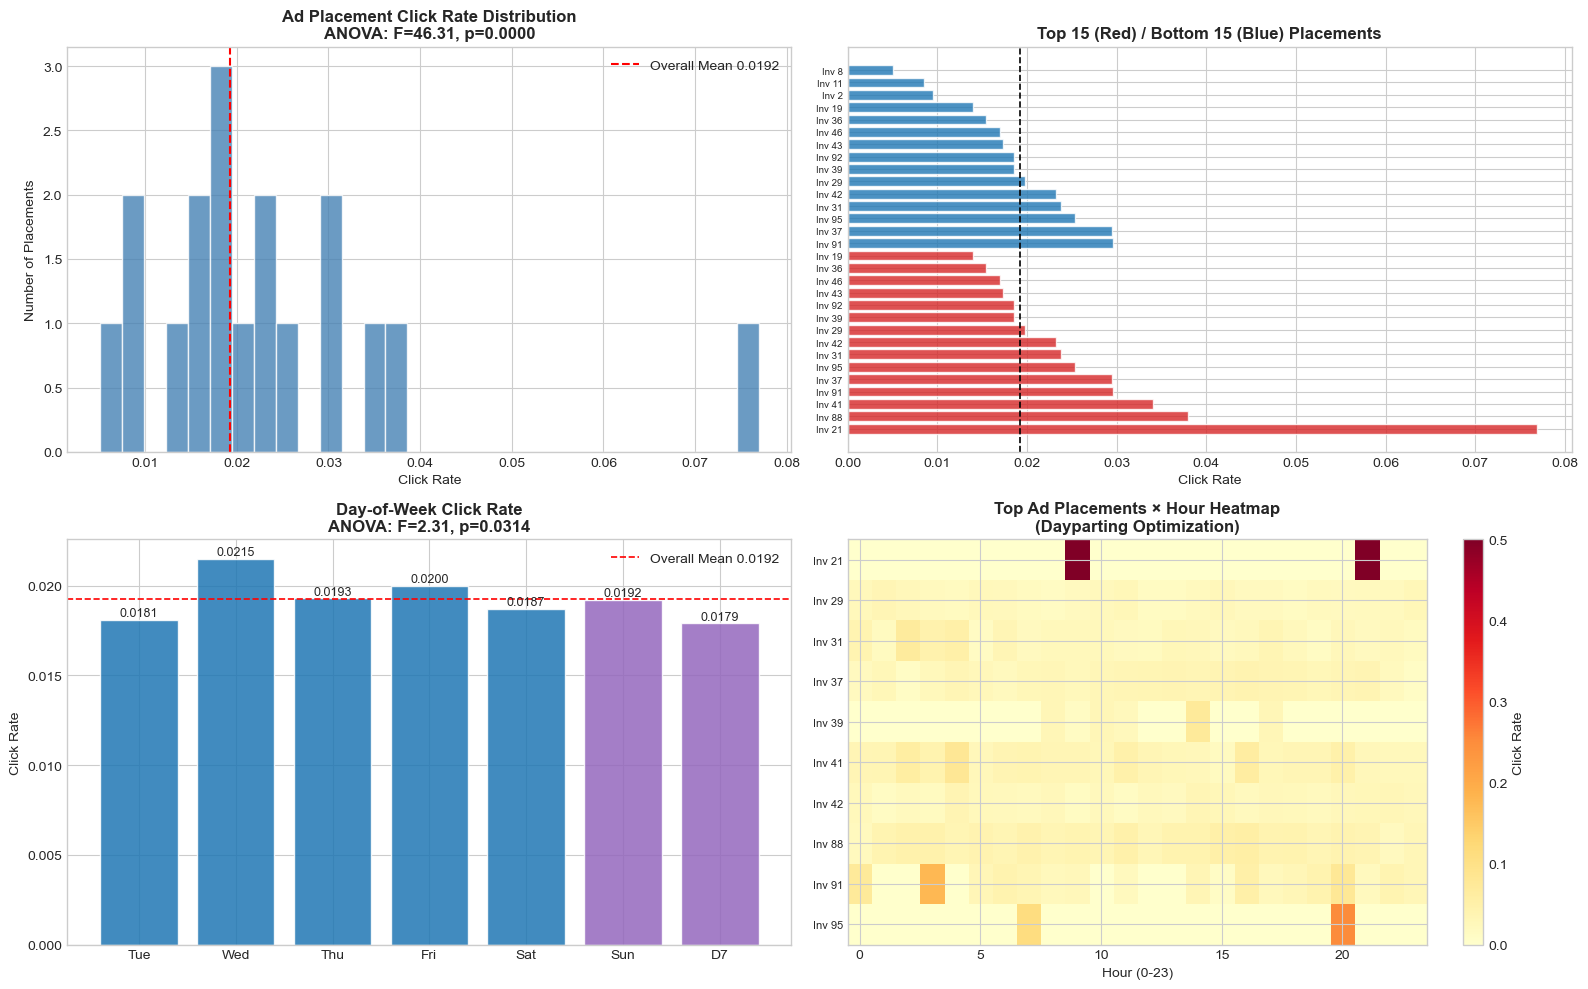


✅ RQ3 Conclusion: Statistically Significant Differences in CTR by Ad Placement and Day-of-Week Exist


In [20]:
# ================================================================
# 🗺️  RQ3. Impact of Advertisement Exposure Environment on CTR
# ================================================================

from scipy.stats import f_oneway, kruskal, chi2_contingency

print("\n" + "="*65)
print("🗺️  RQ3. Advertisement Exposure Environment Analysis")
print("="*65)

# ── Inventory ID Analysis ──────────────────────────────────────
inv_desc = df.groupby('inventory_id')['clicked'].agg(
    Sample_Count='count', Click_Rate='mean'
).sort_values('Click_Rate', ascending=False)

print(f"\n[Ad Placement] Total Ad Placements: {len(inv_desc)}")
print(f"  Highest Click Rate Placement: {inv_desc.index[0]}  ({inv_desc['Click_Rate'].iloc[0]:.4f})")
print(f"  Lowest Click Rate Placement: {inv_desc.index[-1]}  ({inv_desc['Click_Rate'].iloc[-1]:.4f})")
print(f"  Click Rate Std Dev: {inv_desc['Click_Rate'].std():.4f}  (Placement Variation)")

# ANOVA & Chi2: inventory_id
inv_groups = [df[df['inventory_id']==inv]['clicked'].values
              for inv in df['inventory_id'].unique()]
F_inv, p_inv = f_oneway(*inv_groups)
chi2_inv, p_chi2_inv, _, _ = chi2_contingency(
    pd.crosstab(df['inventory_id'], df['clicked']))

print(f"\n[One-way ANOVA] inventory_id: F={F_inv:.2f}, p={p_inv:.6f}",
      "***" if p_inv<0.001 else "")
print(f"[Chi-Square]    inventory_id: χ²={chi2_inv:.2f}, p={p_chi2_inv:.6f}",
      "***" if p_chi2_inv<0.001 else "")

# ── Day of Week Analysis ──────────────────────────────────────
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_desc = df.groupby('day_of_week')['clicked'].agg(
    Sample_Count='count', Click_Rate='mean', Std_Dev='std'
).round(4)
day_desc.index = [day_names[i] if i<7 else f'D{i}' for i in day_desc.index]
print("\n[Day-of-Week Click Rate]:")
print(day_desc.to_string())

dow_groups = [df[df['day_of_week']==d]['clicked'].values
              for d in sorted(df['day_of_week'].dropna().unique())]
F_dow, p_dow = f_oneway(*dow_groups)
print(f"\n[One-way ANOVA] day_of_week: F={F_dow:.2f}, p={p_dow:.6f}",
      "***" if p_dow<0.001 else "")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Ad Placement Click Rate Distribution (TOP/BOTTOM 10 + Overall)
axes[0,0].hist(inv_desc['Click_Rate'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axvline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.5,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
axes[0,0].set_title(f'Ad Placement Click Rate Distribution\nANOVA: F={F_inv:.2f}, p={p_inv:.4f}',
                    fontweight='bold')
axes[0,0].set_xlabel('Click Rate')
axes[0,0].set_ylabel('Number of Placements')
axes[0,0].legend()

# 2) TOP/BOTTOM 15 Placements
top15  = inv_desc.head(15)
bot15  = inv_desc.tail(15)
combined = pd.concat([top15, bot15])
colors_inv = ['#d62728']*15 + ['#1f77b4']*15
axes[0,1].barh(range(len(combined)), combined['Click_Rate'],
               color=colors_inv, alpha=0.8)
axes[0,1].set_yticks(range(len(combined)))
axes[0,1].set_yticklabels([f'Inv {i}' for i in combined.index], fontsize=7)
axes[0,1].axvline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2)
axes[0,1].set_title('Top 15 (Red) / Bottom 15 (Blue) Placements',
                    fontweight='bold')
axes[0,1].set_xlabel('Click Rate')

# 3) Day-of-Week Click Rate
day_ctrs = day_desc['Click_Rate'].values
colors_d = ['#9467bd' if i>=5 else '#1f77b4' for i in range(len(day_desc))]
bars = axes[1,0].bar(day_desc.index, day_ctrs, color=colors_d, alpha=0.85)
axes[1,0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, day_ctrs):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.0002,
                   f'{v:.4f}', ha='center', fontsize=9)
axes[1,0].set_title(f'Day-of-Week Click Rate\nANOVA: F={F_dow:.2f}, p={p_dow:.4f}',
                    fontweight='bold')
axes[1,0].set_ylabel('Click Rate')
axes[1,0].legend()

# 4) Ad Placement x Hour Heatmap (Top 10 placements only)
top10_inv = inv_desc.head(10).index
pivot_inv = df[df['inventory_id'].isin(top10_inv)].groupby(
    ['inventory_id','hour'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1,1].imshow(pivot_inv.values, cmap='YlOrRd', aspect='auto')
axes[1,1].set_yticks(range(len(pivot_inv.index)))
axes[1,1].set_yticklabels([f'Inv {i}' for i in pivot_inv.index], fontsize=8)
axes[1,1].set_xlabel('Hour (0-23)')
axes[1,1].set_title('Top Ad Placements × Hour Heatmap\n(Dayparting Optimization)',
                    fontweight='bold')
plt.colorbar(im4, ax=axes[1,1], label='Click Rate')

plt.tight_layout()
plt.savefig('RQ3_env_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ3 Conclusion: Statistically Significant Differences in CTR by Ad Placement and Day-of-Week Exist")

---
## 4. 피처 엔지니어링 <a id='sec4'></a>

In [21]:
"# Advertisemen Click Prediction Analysis - Part 2",
"# Sequence Analysis + Feature Correlation Analysis",
"",
"import pandas as pd",
"import numpy as np",
"# import matplotlib.pyplot as plt",
"import seaborn as sns",
"from sklearn.preprocessing import LabelEncoder",
"from scipy.stats import chi2_contingency, pearsonr",
"import warnings",
"warnings.filterwarnings('ignore')",
"",
"# # Font Settings",
"# plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']",
"# plt.rcParams['axes.unicode_minus'] = False",
"# plt.style.use('default')",
"# sns.set_palette(\"husl\")",
"",
"print(\"🔍 Part 2: Sequence Analysis + Feature Correlation Analysis\")",
"print(\"=\" * 60)",
"",
"# Data loading",
"df = train.copy()  # Reuse train_sample from Section 1",
"print(f\"📊 Loaded Data: {len(df):,} samples\")",
"",
"# ========================================",
"# 🔗 1. Sequence Data (seq) Analysis",
"# ========================================",
"",
"print(\"\\n\" + \"=\"*60)",
"print(\"🔗 Sequence Data (seq) Analysis\")",
"print(\"=\"*60)",
"",
"# Sequence Length Analysis",
"df['seq_length'] = df['seq'].str.split(',').str.len()",
"df['seq_items'] = df['seq'].str.split(',')",
"",
"print(\"📏 Sequence Length Statistics:\")",
"seq_stats = df['seq_length'].describe()",
"print(seq_stats)",
"",
"# Sequence Length vs Click Rate Analysis",
"seq_length_analysis = df.groupby('seq_length').agg({",
"    'clicked': ['count', 'sum', 'mean']",
"}).round(4)",
"seq_length_analysis.columns = ['Sample_Count', 'Click_Count', 'Click_Rate']",
"",
"print(f\"\\n📊 Click Rate by Sequence Length (Top 10):\")",
"print(seq_length_analysis.sort_values('Click_Rate', ascending=False).head(10))",
"",
"# Sequence Length Binning Analysis",
"df['seq_length_bin'] = pd.cut(df['seq_length'], ",
"                             bins=[0, 100, 300, 600, 1000, float('inf')], ",
"                             labels=['Very Short(<100)', 'Short(100-300)', 'Medium(300-600)', 'Long(600-1000)', 'Very Long(1000+)'])",
"",
"seq_bin_analysis = df.groupby('seq_length_bin').agg({",
"    'clicked': ['count', 'sum', 'mean']",
"}).round(4)",
"seq_bin_analysis.columns = ['Sample_Count', 'Click_Count', 'Click_Rate']",
"",
"print(f\"\\n📊 Sequence Length Bin Analysis:\")",
"print(seq_bin_analysis)",
"",
"# Unique Items in Sequence Analysis",
"def count_unique_items(seq_str):",
"    try:",
"        items = seq_str.split(',')",
"        return len(set(items))",
"    except:",
"        return 0",
"",
"df['unique_items'] = df['seq'].apply(count_unique_items)",
"df['diversity_ratio'] = df['unique_items'] / df['seq_length']",
"",
"print(f\"\\n🌈 Sequence Diversity Analysis:\")",
"print(f\"   Average Unique Items: {df['unique_items'].mean():.2f}\")",
"print(f\"   Average Diversity Ratio: {df['diversity_ratio'].mean():.4f}\")",
"",
"diversity_analysis = df.groupby(pd.cut(df['diversity_ratio'], bins=5)).agg({",
"    'clicked': ['count', 'mean']",
"}).round(4)",
"diversity_analysis.columns = ['Sample_Count', 'Click_Rate']",
"print(f\"\\n📊 Click Rate by Diversity Ratio:\")",
"print(diversity_analysis)",
"",
"# Sequence Analysis Visualization",
"fig, axes = plt.subplots(2, 3, figsize=(18, 12))",
"",
"# 1. Sequence Length Distribution",
"df['seq_length'].hist(bins=50, ax=axes[0,0], color='skyblue', alpha=0.7, edgecolor='black')",
"axes[0,0].set_title('Sequence Length Distribution', fontsize=12, fontweight='bold')",
"axes[0,0].set_xlabel('Sequence Length')",
"axes[0,0].set_ylabel('Frequency')",
"axes[0,0].axvline(df['seq_length'].mean(), color='red', linestyle='--', label=f'Mean: {df[\"seq_length\"].mean():.0f}')",
"axes[0,0].legend()",
"",
"# 2. Sequence Length Bin vs Click Rate",
"seq_bin_analysis['Click_Rate'].plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)",
"axes[0,1].set_title('Click Rate by Sequence Length Bin', fontsize=12, fontweight='bold')",
"axes[0,1].set_xlabel('Sequence Length Bin')",
"axes[0,1].set_ylabel('Click Rate')",
"axes[0,1].tick_params(axis='x', rotation=45)",
"",
"# 3. Diversity Ratio Distribution",
"df['diversity_ratio'].hist(bins=50, ax=axes[0,2], color='lightgreen', alpha=0.7, edgecolor='black')",
"axes[0,2].set_title('Sequence Diversity Ratio Distribution', fontsize=12, fontweight='bold')",
"axes[0,2].set_xlabel('Diversity Ratio')",
"axes[0,2].set_ylabel('Frequency')",
"axes[0,2].axvline(df['diversity_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df[\"diversity_ratio\"].mean():.3f}')",
"axes[0,2].legend()",
"",
"# 4. Sequence Length vs Diversity Scatter",
"sample_df = df.sample(n=min(10000, len(df)))  # Sampling for visualization optimization",
"clicked_color = sample_df['clicked'].map({0: 'lightblue', 1: 'red'})",
"axes[1,0].scatter(sample_df['seq_length'], sample_df['diversity_ratio'], ",
"                  c=clicked_color, alpha=0.6, s=10)",
"axes[1,0].set_title('Sequence Length vs Diversity (Click Color-coded)', fontsize=12, fontweight='bold')",
"axes[1,0].set_xlabel('Sequence Length')",
"axes[1,0].set_ylabel('Diversity Ratio')",
"",
"# 5. Unique Items Count vs Click Rate",
"unique_bins = pd.cut(df['unique_items'], bins=10)",
"unique_analysis = df.groupby(unique_bins)['clicked'].mean()",
"unique_analysis.plot(kind='line', ax=axes[1,1], marker='o', color='purple', linewidth=2)",
"axes[1,1].set_title('Click Rate by Unique Items Count', fontsize=12, fontweight='bold')",
"axes[1,1].set_xlabel('Unique Items Bin')",
"axes[1,1].set_ylabel('Click Rate')",
"axes[1,1].tick_params(axis='x', rotation=45)",
"axes[1,1].grid(True, alpha=0.3)",
"",
"# 6. Sequence Length Category vs Click Rate (Boxplot)",
"df['seq_length_category'] = pd.cut(df['seq_length'], bins=5, labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])",
"df.boxplot(column='clicked', by='seq_length_category', ax=axes[1,2])",
"axes[1,2].set_title('Click Rate Distribution by Sequence Length', fontsize=12, fontweight='bold')",
"axes[1,2].set_xlabel('Sequence Length Category')",
"axes[1,2].set_ylabel('Click Rate')",
"",
"plt.suptitle('', fontsize=16)  # Remove default title",
"plt.tight_layout()",
"plt.show()",
""

''


📊 Feature Group Analysis
🔍 Feature Group Composition:
   l_feat: 27 features, Missing values: 2,934
   feat_a: 18 features, Missing values: 6,372
   feat_b: 6 features, Missing values: 1,956
   feat_c: 8 features, Missing values: 2,608
   feat_d: 6 features, Missing values: 1,956
   feat_e: 10 features, Missing values: 23,133
   history_a: 10 features, Missing values: 2,282
   history_b: 33 features, Missing values: 9,780


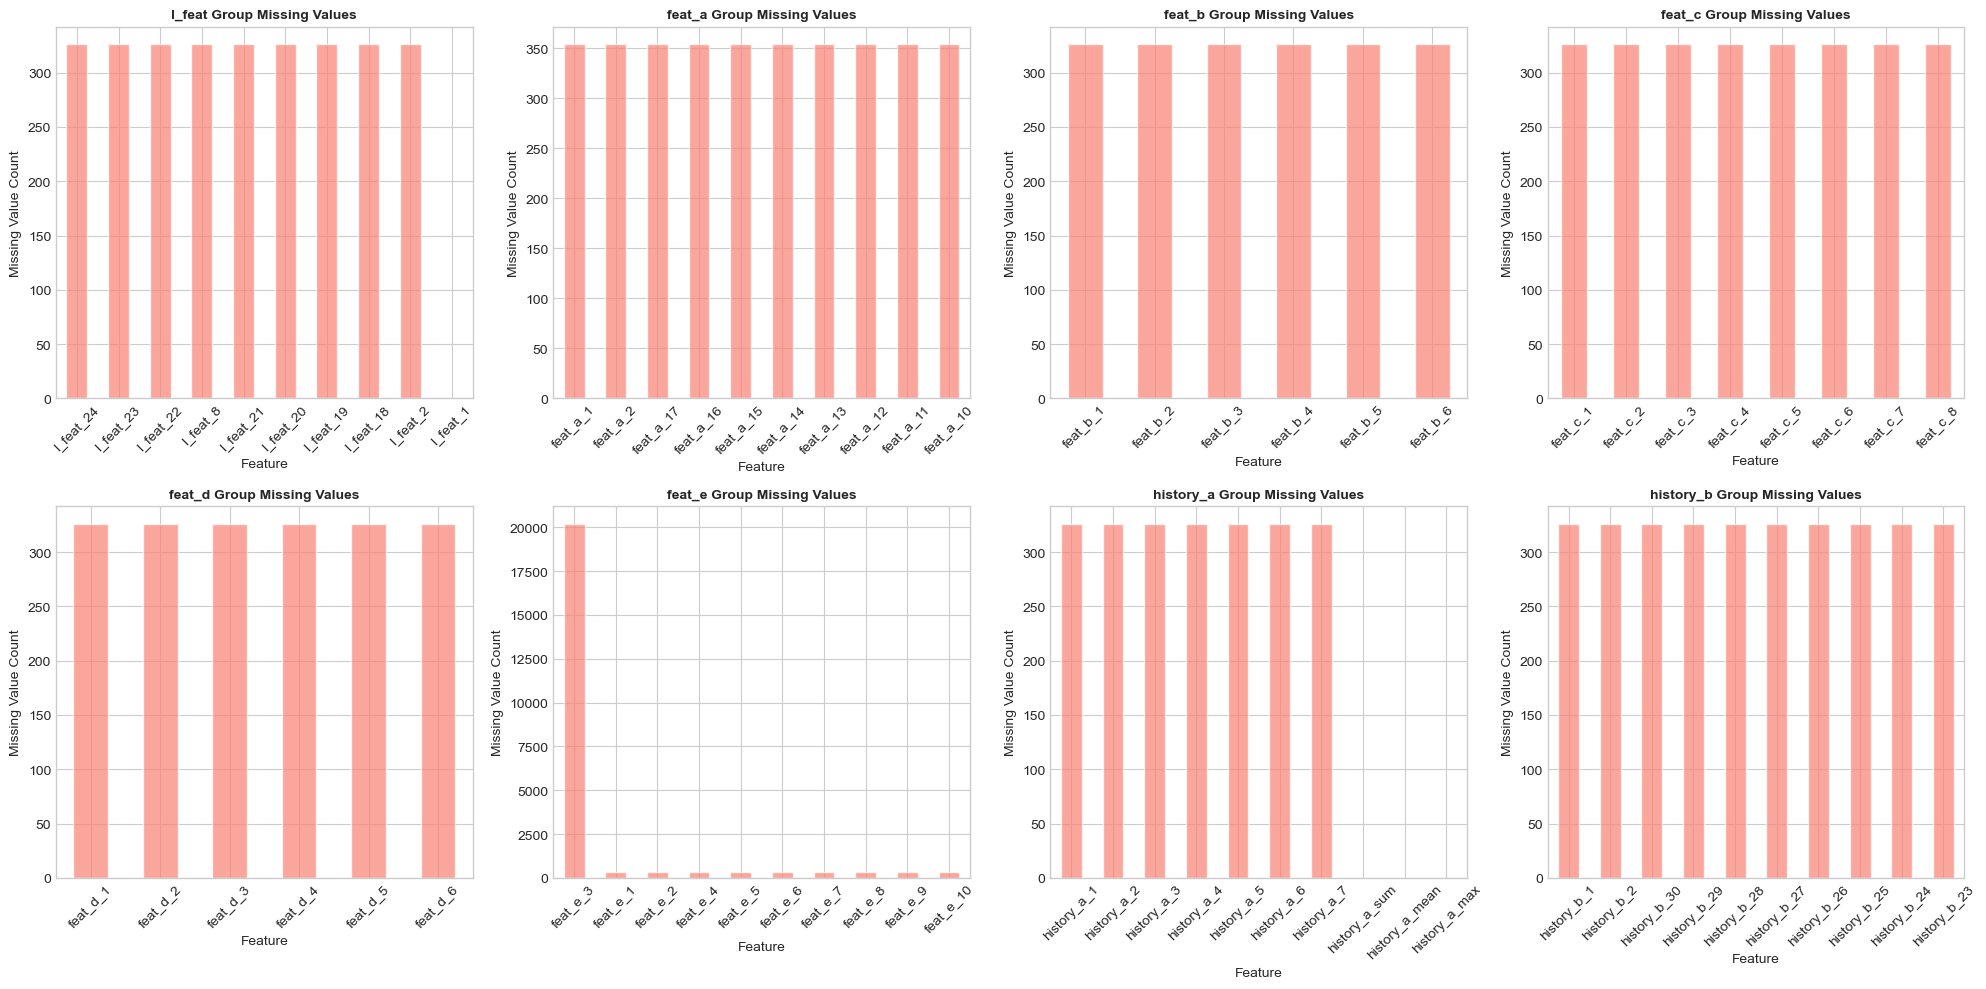

In [22]:

# ========================================
# 📊 2. Feature Group Analysis
# ========================================

print("\n" + "="*60)
print("📊 Feature Group Analysis")
print("="*60)

# Feature group analysis
feature_groups = {
    'l_feat': [col for col in df.columns if col.startswith('l_feat_')],
    'feat_a': [col for col in df.columns if col.startswith('feat_a_')],
    'feat_b': [col for col in df.columns if col.startswith('feat_b_')],
    'feat_c': [col for col in df.columns if col.startswith('feat_c_')],
    'feat_d': [col for col in df.columns if col.startswith('feat_d_')],
    'feat_e': [col for col in df.columns if col.startswith('feat_e_')],
    'history_a': [col for col in df.columns if col.startswith('history_a_')],
    'history_b': [col for col in df.columns if col.startswith('history_b_')]
}

print("🔍 Feature Group Composition:")
for group, features in feature_groups.items():
    missing_count = df[features].isnull().sum().sum()
    print(f"   {group}: {len(features)} features, Missing values: {missing_count:,}")

# Group-wise missing value patterns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (group, features) in enumerate(feature_groups.items()):
    if i < len(axes):
        missing_pattern = df[features].isnull().sum().sort_values(ascending=False)
        if len(missing_pattern) > 0:
            missing_pattern.head(10).plot(kind='bar', ax=axes[i], color='salmon', alpha=0.7)
            axes[i].set_title(f'{group} Group Missing Values', fontsize=10, fontweight='bold')
            axes[i].set_xlabel('Feature')
            axes[i].set_ylabel('Missing Value Count')
            axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


🔗 타겟과 피처간 상관관계 분석
📊 타겟과 상관관계 TOP 20:
    1. history_a_max       :   0.0710 (절대값: 0.0710)
    2. history_a_1         :   0.0673 (절대값: 0.0673)
    3. inv_ctr_encoded     :   0.0626 (절대값: 0.0626)
    4. history_b_2         :   0.0592 (절대값: 0.0592)
    5. history_a_2         :  -0.0589 (절대값: 0.0589)
    6. history_b_30        :   0.0578 (절대값: 0.0578)
    7. history_a_5         :  -0.0576 (절대값: 0.0576)
    8. history_b_max       :   0.0572 (절대값: 0.0572)
    9. history_a_3         :   0.0562 (절대값: 0.0562)
   10. history_b_1         :   0.0526 (절대값: 0.0526)
   11. feat_e_1            :  -0.0499 (절대값: 0.0499)
   12. feat_b_4            :  -0.0498 (절대값: 0.0498)
   13. history_b_10        :   0.0482 (절대값: 0.0482)
   14. feat_d_3            :  -0.0477 (절대값: 0.0477)
   15. history_b_sum       :   0.0445 (절대값: 0.0445)
   16. history_b_mean      :   0.0445 (절대값: 0.0445)
   17. history_b_17        :   0.0439 (절대값: 0.0439)
   18. feat_d_2            :  -0.0430 (절대값: 0.0430)
   19. history_b_9        

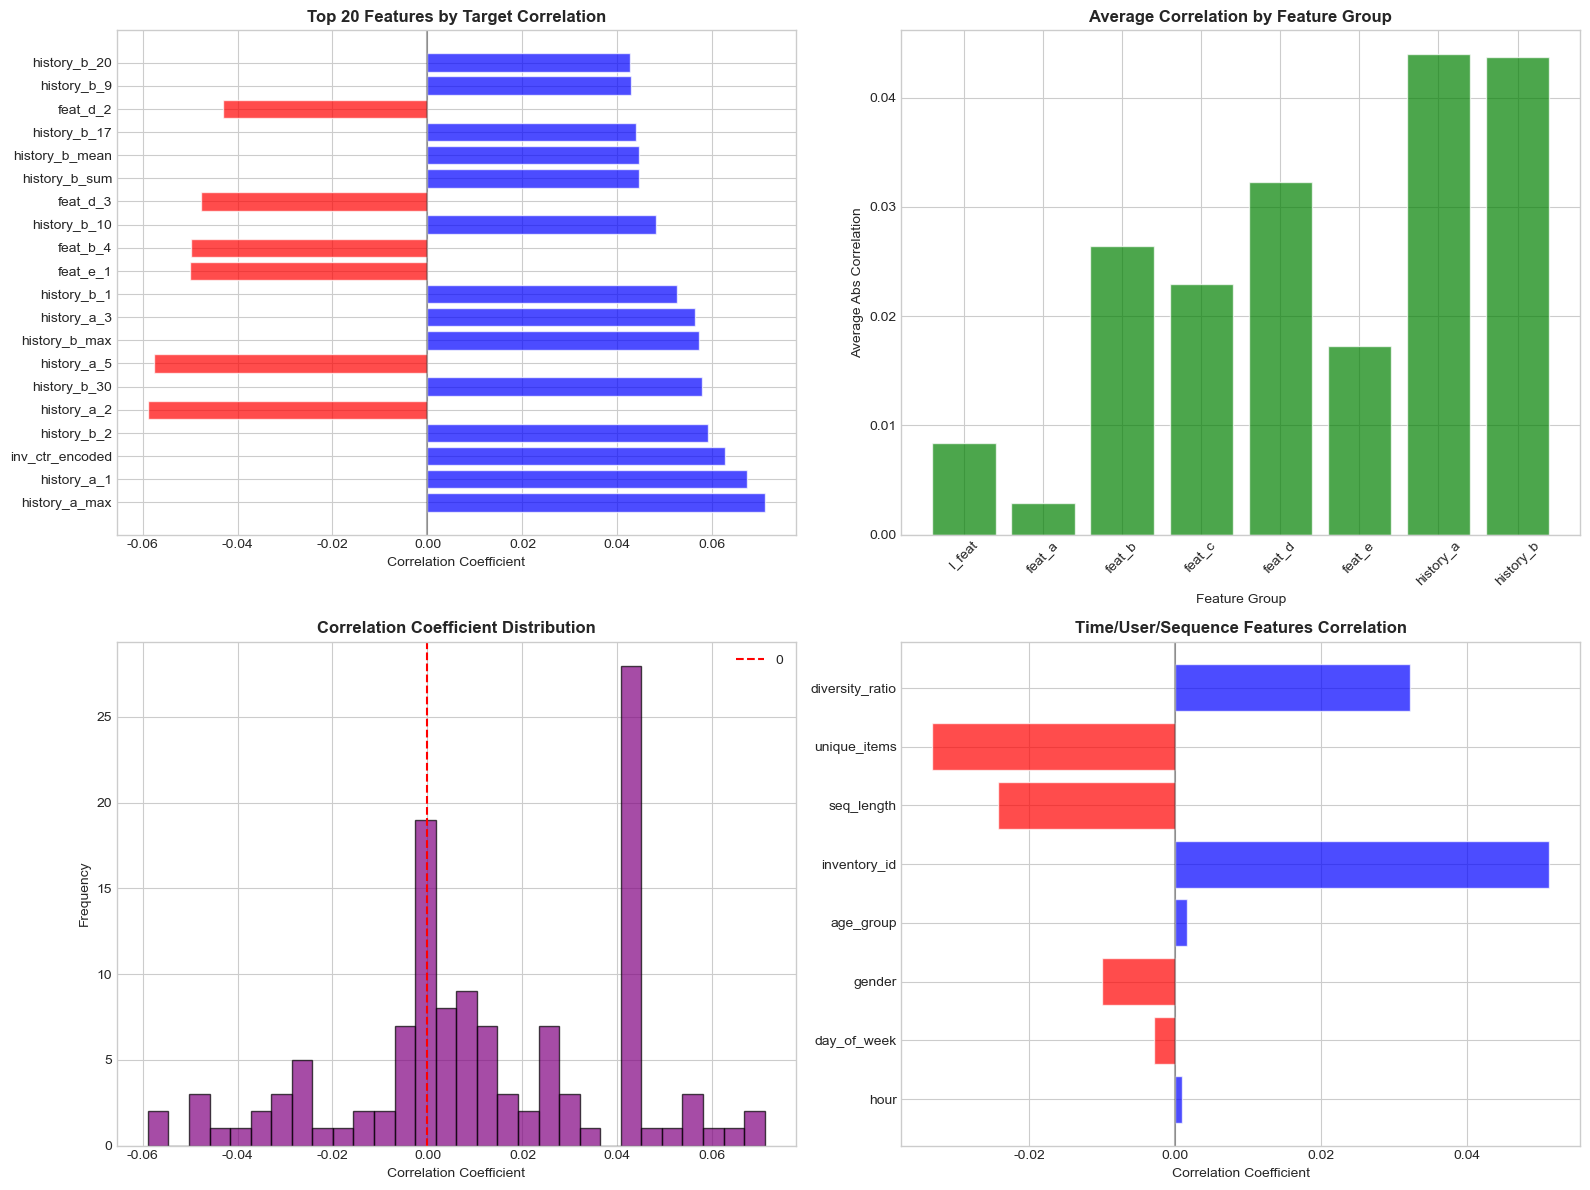

In [23]:
# ========================================
# 3. 타겟과 피처간 상관관계 분석
# ========================================

print("\n" + "=" * 60)
print("🔗 타겟과 피처간 상관관계 분석")
print("=" * 60)

# 숫자형 피처 식별 (타겟 제외)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "clicked"]

# 상관관계 계산 (결측치 처리)
correlations = []
for feature in numeric_features:
    if df[feature].notna().sum() > 100:  # 충분한 데이터가 있는 경우에만
        corr = df[["clicked", feature]].corr().iloc[0, 1]
        if not np.isnan(corr):
            correlations.append((feature, abs(corr), corr))

correlations.sort(key=lambda x: x[1], reverse=True)

print("📊 타겟과 상관관계 TOP 20:")
for i, (feature, abs_corr, corr) in enumerate(correlations[:20]):
    print(f"   {i+1:2d}. {feature:20s}: {corr:8.4f} (절대값: {abs_corr:.4f})")

# 상관관계 시각화
top_features = [item[0] for item in correlations[:20]]
corr_values = [item[2] for item in correlations[:20]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 상관관계 피처 탑 20
axes[0, 0].barh(
    range(len(top_features)),
    corr_values,
    color=["red" if x < 0 else "blue" for x in corr_values],
    alpha=0.7
)
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features)
axes[0, 0].set_title("Top 20 Features by Target Correlation", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Correlation Coefficient")
axes[0, 0].axvline(0, color="black", linestyle="-", alpha=0.3)

# 2. 피처 그룹별 평균 상관관계
group_correlations = {}
for group, features in feature_groups.items():
    group_corrs = []
    for feature in features:
        if feature in [item[0] for item in correlations]:
            corr_val = next(item[2] for item in correlations if item[0] == feature)
            group_corrs.append(abs(corr_val))
    if group_corrs:
        group_correlations[group] = np.mean(group_corrs)

if group_correlations:
    groups = list(group_correlations.keys())
    values = list(group_correlations.values())
    axes[0, 1].bar(groups, values, color="green", alpha=0.7)
    axes[0, 1].set_title("Average Correlation by Feature Group", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("Feature Group")
    axes[0, 1].set_ylabel("Average Abs Correlation")
    axes[0, 1].tick_params(axis="x", rotation=45)

# 3. 상관관계 분포
all_corr_values = [item[2] for item in correlations]
axes[1, 0].hist(all_corr_values, bins=30, color="purple", alpha=0.7, edgecolor="black")
axes[1, 0].set_title("Correlation Coefficient Distribution", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Correlation Coefficient")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].axvline(0, color="red", linestyle="--", label="0")
axes[1, 0].legend()

# 4. 시간/사용자 피처 상관관계
time_user_features = [
    "hour", "day_of_week", "gender", "age_group",
    "inventory_id", "seq_length", "unique_items", "diversity_ratio"
]
time_user_corrs = []
time_user_names = []

for feature in time_user_features:
    if feature in df.columns:
        corr = df[["clicked", feature]].corr().iloc[0, 1]
        if not np.isnan(corr):
            time_user_corrs.append(corr)
            time_user_names.append(feature)

if time_user_corrs:
    axes[1, 1].barh(
        range(len(time_user_names)),
        time_user_corrs,
        color=["red" if x < 0 else "blue" for x in time_user_corrs],
        alpha=0.7
    )
    axes[1, 1].set_yticks(range(len(time_user_names)))
    axes[1, 1].set_yticklabels(time_user_names)
    axes[1, 1].set_title("Time/User/Sequence Features Correlation", fontsize=12, fontweight="bold")
    axes[1, 1].set_xlabel("Correlation Coefficient")
    axes[1, 1].axvline(0, color="black", linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:

# ========================================
# 🔥 4. Feature Importance Analysis (Statistical Methods)
# ========================================

print("\n" + "="*60)
print("🔥 Feature Importance Analysis")
print("="*60)

# Chi-square test for categorical features
categorical_features = ['gender', 'age_group', 'day_of_week', 'hour', 'inventory_id']
chi2_results = []

for feature in categorical_features:
    if feature in df.columns:
        # Remove missing values and create contingency table
        temp_df = df[[feature, 'clicked']].dropna()
        if len(temp_df) > 0:
            contingency = pd.crosstab(temp_df[feature], temp_df['clicked'])
            if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                chi2_results.append((feature, chi2, p_value))

chi2_results.sort(key=lambda x: x[1], reverse=True)

print("📊 Chi-square Test Results for Categorical Features:")
for feature, chi2_stat, p_val in chi2_results:
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"   {feature:15s}: χ² = {chi2_stat:10.2f}, p-value = {p_val:.6f} {significance}")

# Analyze mean difference for numeric features (Clicked vs Non-Clicked)
print(f"\n📊 Numeric Feature Mean Difference (Clicked vs Non-Clicked) - Top 15:")
feature_diffs = []

for feature in top_features[:15]:  # Only top correlated features
    clicked_mean = df[df['clicked'] == 1][feature].mean()
    not_clicked_mean = df[df['clicked'] == 0][feature].mean()
    diff = clicked_mean - not_clicked_mean
    feature_diffs.append((feature, clicked_mean, not_clicked_mean, diff))

feature_diffs.sort(key=lambda x: abs(x[3]), reverse=True)

for feature, click_mean, no_click_mean, diff in feature_diffs:
    print(f"   {feature:20s}: Clicked {click_mean:8.4f} vs Non-Clicked {no_click_mean:8.4f} (Diff: {diff:8.4f})")


🔥 Feature Importance Analysis
📊 Chi-square Test Results for Categorical Features:
   inventory_id   : χ² =     784.27, p-value = 0.000000 ***
   age_group      : χ² =     154.94, p-value = 0.000000 ***
   hour           : χ² =      36.20, p-value = 0.039397 *
   gender         : χ² =      19.89, p-value = 0.000008 ***
   day_of_week    : χ² =      13.84, p-value = 0.031426 *

📊 Numeric Feature Mean Difference (Clicked vs Non-Clicked) - Top 15:
   history_b_sum       : Clicked  14.7349 vs Non-Clicked   6.2518 (Diff:   8.4831)
   feat_e_1            : Clicked  57.5357 vs Non-Clicked  61.1618 (Diff:  -3.6261)
   history_b_max       : Clicked   1.5494 vs Non-Clicked   0.6345 (Diff:   0.9149)
   history_b_2         : Clicked   1.4534 vs Non-Clicked   0.5861 (Diff:   0.8672)
   history_b_1         : Clicked   0.9335 vs Non-Clicked   0.4214 (Diff:   0.5121)
   history_b_30        : Clicked   0.5237 vs Non-Clicked   0.2111 (Diff:   0.3127)
   history_b_10        : Clicked   0.3552 vs Non-Clic

# Task: 상호작용 피처 생성

`train_sample_processed` DataFrame에서 'age_group'과 'gender' 간의 상호작용 피처를 생성하여 CTR에 대한 결합 효과를 탐구합니다.

## 피처 엔지니어링 - 상호작용 피처

### 목표
'연령_그룹'과 '젠더' 간의 상호작용 피처를 생성하여 CTR에 대한 결합 효과를 탐구합니다. 연령과 성별의 고유한 조합을 포착하는 새로운 카테고리 표현을 만들고, `train_sample_processed` DataFrame에 추가합니다.


### 접근 방법
'연령_그룹'과 '젠더'가 CTR에 미치는 복합적 영향을 분석하기 위해 상호작용 피처를 생성하고, 각 고유 조합별 CTR을 계산한 뒤 상위 5개·하위 5개 그룹을 출력합니다.



In [25]:
import pandas as pd

# Ensure 'clicked' column is int for consistent calculations
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. Create the interaction feature
train_sample_processed['age_gender_interaction'] = \
    train_sample_processed['age_group'].astype(str) + '_' + \
    train_sample_processed['gender'].astype(str)

# 2. Calculate CTR for each unique age_gender_interaction
age_gender_ctr = train_sample_processed.groupby('age_gender_interaction')['clicked'].mean().reset_index()
age_gender_ctr.columns = ['age_gender_interaction', 'CTR']

# Sort by CTR to find top and bottom groups
age_gender_ctr_sorted = age_gender_ctr.sort_values(by='CTR', ascending=False)

print("Top 5 Age-Gender Interaction Groups by CTR:")
print(age_gender_ctr_sorted.head(5))

print("\nBottom 5 Age-Gender Interaction Groups by CTR:")
print(age_gender_ctr_sorted.tail(5))

Top 5 Age-Gender Interaction Groups by CTR:
   age_gender_interaction       CTR
1                 1.0_2.0  0.079812
0                 1.0_1.0  0.075000
5                 3.0_2.0  0.025943
16              None_None  0.024540
14                8.0_1.0  0.024279

Bottom 5 Age-Gender Interaction Groups by CTR:
   age_gender_interaction       CTR
8                 5.0_1.0  0.017154
4                 3.0_1.0  0.016745
13                7.0_2.0  0.015465
11                6.0_2.0  0.014840
9                 5.0_2.0  0.014608


### 접근 방법
'age_gender_interaction' 피처의 종합 분석을 위해, 상위 10개·하위 10개 상호작용 그룹의 CTR을 막대 그래프로 시각화합니다.



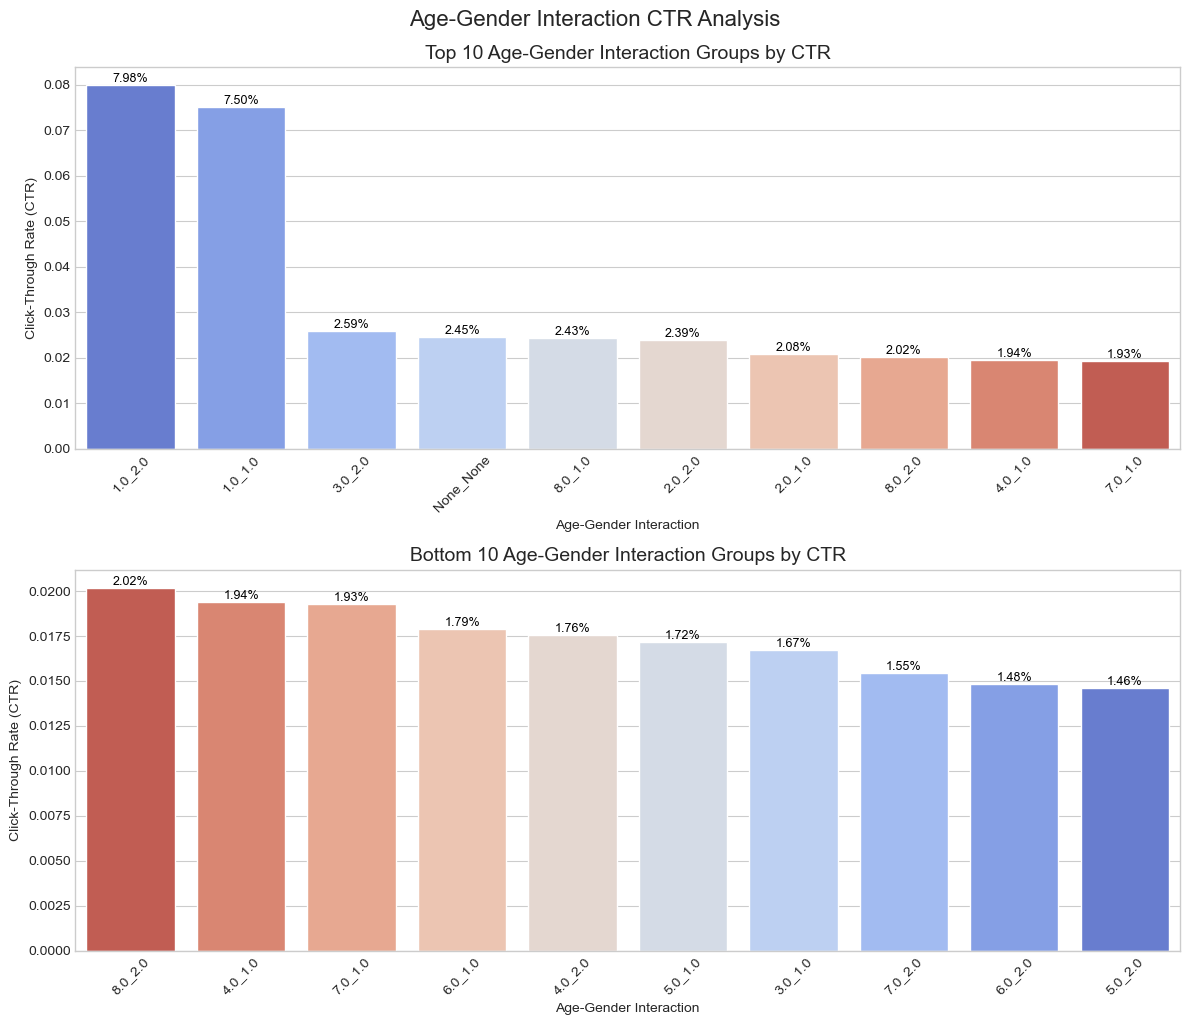

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 상위 10개와 하위 10개 상호작용 그룹 가져오기
top_10_interactions = age_gender_ctr_sorted.head(10)
bottom_10_interactions = age_gender_ctr_sorted.tail(10)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# FutureWarning 방지를 위해 이산 색상 팔레트 생성
num_top = len(top_10_interactions)
colors_top = sns.color_palette("coolwarm", n_colors=num_top)

num_bottom = len(bottom_10_interactions)
colors_bottom = sns.color_palette("coolwarm_r", n_colors=num_bottom)

# 상위 10개 상호작용 그룹 그래프
sns.barplot(
    x='age_gender_interaction', 
    y='CTR', 
    data=top_10_interactions, 
    hue='age_gender_interaction', 
    palette=colors_top, 
    ax=axes[0], 
    legend=False
)
#CTR 기준 상위 10개 연령-성별 상호작용 그룹
axes[0].set_title('Top 10 Age-Gender Interaction Groups by CTR', fontsize=14)
axes[0].set_xlabel('Age-Gender Interaction')  
axes[0].set_ylabel('Click-Through Rate (CTR)')  
axes[0].tick_params(axis='x', rotation=45)
for i, row in enumerate(top_10_interactions.itertuples()):
    axes[0].text(i, row.CTR, f'{row.CTR:.2%}', color='black', ha="center", va="bottom", fontsize=9)

# 하위 10개 상호작용 그룹 그래프
sns.barplot(
    x='age_gender_interaction', 
    y='CTR', 
    data=bottom_10_interactions, 
    hue='age_gender_interaction', 
    palette=colors_bottom, 
    ax=axes[1], 
    legend=False
)
#CTR 기준 하위 10개 연령-성별 상호작용 그룹
axes[1].set_title('Bottom 10 Age-Gender Interaction Groups by CTR', fontsize=14)
axes[1].set_xlabel('Age-Gender Interaction')  
axes[1].set_ylabel('Click-Through Rate (CTR)')  
axes[1].tick_params(axis='x', rotation=45)
for i, row in enumerate(bottom_10_interactions.itertuples()):
    axes[1].text(i, row.CTR, f'{row.CTR:.2%}', color='black', ha="center", va="bottom", fontsize=9)
#연령-성별 상호작용별 CTR 분석
plt.tight_layout()
plt.suptitle('Age-Gender Interaction CTR Analysis', y=1.02, fontsize=16)
plt.show()

### 접근 방법
연령·성별 상호작용 피처 분석을 완료했습니다. 로드맵에 따라 시간 기반 피처 엔지니어링을 진행하며, 먼저 'hour' 컬럼에서 'time_of_day' 피처를 생성합니다. 시간을 아침/오후/저녁/밤 등으로 구간화하여 사용자 행동 패턴을 파악합니다.



In [27]:
import pandas as pd

# Ensure 'hour' column is int for proper comparison
train_sample_processed['hour'] = train_sample_processed['hour'].astype(int)

# Define a function to categorize hour into time of day
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Create the 'time_of_day' feature
train_sample_processed['time_of_day'] = train_sample_processed['hour'].apply(get_time_of_day)

print("Value counts for new 'time_of_day' feature:")
print(train_sample_processed['time_of_day'].value_counts())


Value counts for new 'time_of_day' feature:
time_of_day
Morning      70543
Night        45467
Afternoon    44761
Evening      39229
Name: count, dtype: int64


### 접근 방법
`time_of_day` 피처 생성 완료. 이어서 `day_of_week`에서 **평일/주말** 분류 피처(`weekday_weekend`)를 생성하여 `train_sample_processed`에 추가하고, 사용자 행동 패턴을 더 명확히 파악합니다.



In [28]:
import pandas as pd

# 'day_of_week' 컬럼을 int로 변환하여 비교에 적합하게 만듦
train_sample_processed['day_of_week'] = train_sample_processed['day_of_week'].astype(int)

# day_of_week를 평일/주말로 분류하는 함수 정의
def get_weekday_weekend(day):
    # 1=월요일, 7=일요일 가정
    if day >= 1 and day <= 5:
        return 'Weekday'  # 평일
    elif day == 6 or day == 7:
        return 'Weekend'  # 주말
    else:
        return 'Unknown'  # 알 수 없음

# 'weekday_weekend' 피처 생성
train_sample_processed['weekday_weekend'] = train_sample_processed['day_of_week'].apply(get_weekday_weekend)

print("새 'weekday_weekend' 피처의 값 분포:")
print(train_sample_processed['weekday_weekend'].value_counts())

새 'weekday_weekend' 피처의 값 분포:
weekday_weekend
Weekday    142946
Weekend     57054
Name: count, dtype: int64


---
## 5. 상관관계 분석 <a id='sec5'></a>

# Task: 상관관계 행렬 분석

`train_sample_processed` DataFrame의 숫자형 피처와 타겟 변수 'clicked' 간의 상관관계 행렬을 계산하고, 피처 간 관계를 파악하기 위해 히트맵으로 시각화합니다.

## 상관관계 행렬 계산

### 목표
`train_sample_processed`의 숫자형 피처들과 타겟 변수 `clicked` 간 상관관계 행렬을 계산하고, 히트맵으로 시각화하여 피처 간 관계를 파악합니다.


### 접근 방법
숫자형 피처와 'clicked' 타겟 변수 간 관계를 분석합니다. `train_sample_processed`에서 'clicked'를 포함한 숫자형 컬럼을 선정하고 상관관계를 계산한 뒤, `seaborn.heatmap`으로 주석과 제목을 포함해 시각화합니다.



상관관계 분석 피처: ['clicked', 'gender', 'age_group', 'day_of_week', 'hour', 'l_feat_1', 'l_feat_2', 'feat_e_1', 'feat_e_2', 'history_b_1', 'history_b_2']
상관관계 데이터프레임 크기: (199674, 11)


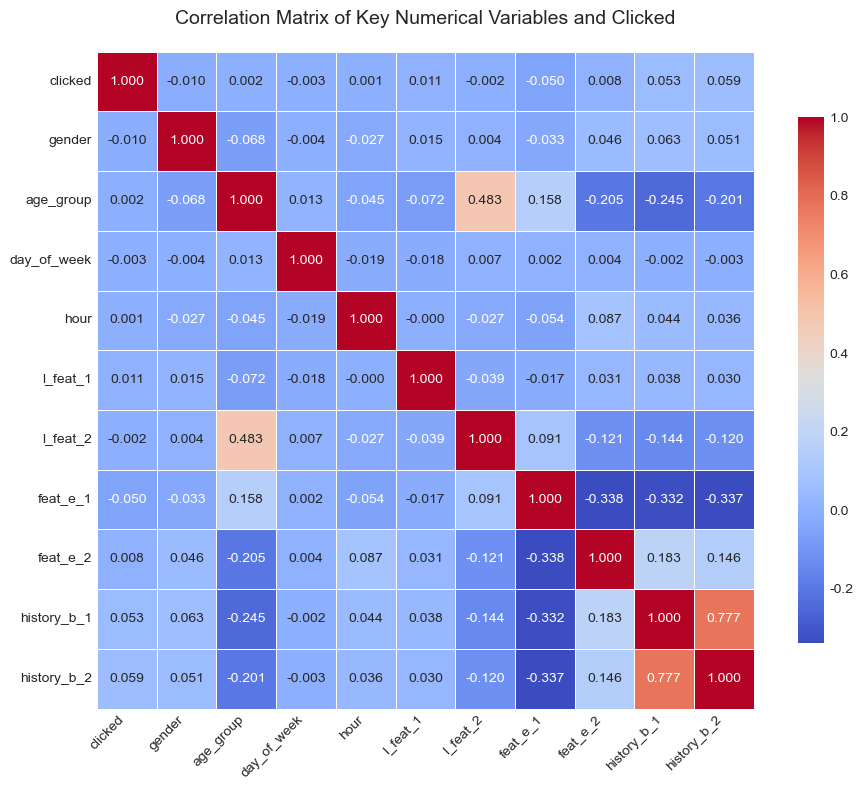


Clicked와의 상관관계 (절댓값 기준 상위):
clicked        1.000000
history_b_2    0.059176
history_b_1    0.052629
feat_e_1       0.049926
l_feat_1       0.011446
gender         0.010018
feat_e_2       0.008241
day_of_week    0.002944
l_feat_2       0.001674
age_group      0.001578
hour           0.001005
Name: clicked, dtype: float64


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# 1. 'clicked'와 상관관계가 높은 특정 숫자형 피처 선택
selected_features = [
    'clicked', 'gender', 'age_group', 'day_of_week', 'hour',
    'l_feat_1', 'l_feat_2', 'feat_e_1', 'feat_e_2',
    'history_b_1', 'history_b_2'
]

# 2. 선택된 피처만 포함한 상관관계 데이터프레임 생성
correlation_df = train_sample_processed[selected_features].copy()

# 선택된 컬럼이 존재하고 숫자형인지 확인
available_features = [col for col in selected_features if col in correlation_df.columns]
correlation_df = correlation_df[available_features]

# 선택된 피처에 NaN이 있는 행 제거
correlation_df = correlation_df.dropna()

print(f"상관관계 분석 피처: {list(correlation_df.columns)}")
print(f"상관관계 데이터프레임 크기: {correlation_df.shape}")

# 3. 상관관계 행렬 계산
corr_matrix = correlation_df.corr()

# 4. 가독성 좋은 작은 히트맵 생성
plt.figure(figsize=(10, 8))

# 5. 가독성 개선된 시각화
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True
)

plt.title('Correlation Matrix of Key Numerical Variables and Clicked', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. 'clicked'와의 상관관계 빠른 참조용 출력
clicked_corrs = corr_matrix['clicked'].sort_values(ascending=False)
print("\nClicked와의 상관관계 (절댓값 기준 상위):")
print(clicked_corrs.abs().sort_values(ascending=False))

## 모델링을 위한 데이터 준비

### 목표
로지스틱 회귀 학습을 위해 `train_sample_processed`에서 필요한 피처를 선택하고, 범주형 피처(`time_of_day`, `weekday_weekend`, `age_gender_interaction` 등)를 원-핫 인코딩하여 수치형으로 변환합니다. 이후 학습·검증 세트로 분리합니다.


---
## 6. 모델링 <a id='sec6'></a>

### 6a. 로지스틱 회귀

### 접근 방법
피처 선정, 범주형 원-핫 인코딩, 학습·검증 분리를 수행합니다. 신규 생성 피처를 포함한 관련 피처와 타겟 변수를 선정한 뒤 전처리를 진행합니다.



In [30]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 숫자형 피처와 범주형 피처 정의
# 원래 숫자형이지만 원-핫 인코딩을 위해 범주형으로 처리해야 하는 피처들
categorical_features = ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour']

# 엔지니어링된 범주형 피처들 추가
categorical_features.extend(['time_of_day', 'weekday_weekend', 'age_gender_interaction'])

# 'l_feat_'와 'feat_e_' 컬럼들은 숫자형이므로 직접 포함
l_feat_cols = [col for col in train_sample_processed.columns if col.startswith('l_feat_')]
feat_e_cols = [col for col in train_sample_processed.columns if col.startswith('feat_e_')]

# 기타 숫자형 피처들 (history_b_ 피처들 등)
history_b_cols = [col for col in train_sample_processed.columns if col.startswith('history_b_')]

# 타겟 변수
target_variable = 'clicked'

# 모든 피처 컬럼 합치기
all_features = categorical_features + l_feat_cols + feat_e_cols + history_b_cols

# 중복 제거하면서 순서 유지 (set()은 순서 섞임)
all_features = list(dict.fromkeys(all_features))

# 타겟 변수가 피처 리스트에 포함되지 않도록 제거
if target_variable in all_features:
    all_features.remove(target_variable)

# 데이터프레임에서 피처와 타겟 선택
X = train_sample_processed[all_features].copy()
y = train_sample_processed[target_variable].copy()

# 범주형 컬럼들을 'category' 타입으로 변환하여 원-핫 인코딩 준비
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 범주형 피처 원-핫 인코딩 수행
X_encoded = pd.get_dummies(X, columns=categorical_features, dummy_na=False)

print(f"인코딩 전 NaN 개수 (원본): {X_encoded.isnull().sum().sum()}")
print(f"원본 피처 수: {X.shape[1]}")
print(f"인코딩 후 피처 수: {X_encoded.shape[1]}")
print(f"인코딩된 피처 처음 5행:\n{X_encoded.head()}")

# 데이터 누수 방지를 위해 TRAIN 통계만 사용해 결측치 보간 (먼저 분할)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 훈련 데이터의 평균으로 결측치 보간 (pandas는 NaN 자동 제외)
train_impute_means = X_train.mean()
X_train = X_train.fillna(train_impute_means)
X_val = X_val.fillna(train_impute_means)

print(f"보간 후 X_train NaN 개수: {X_train.isnull().sum().sum()}")
print(f"보간 후 X_val NaN 개수: {X_val.isnull().sum().sum()}")

print(f"\nX_train 크기: {X_train.shape}")
print(f"X_val 크기: {X_val.shape}")
print(f"y_train 크기: {y_train.shape}")
print(f"y_val 크기: {y_val.shape}")

print("\ny_train 클래스 분포:")
print(y_train.value_counts(normalize=True))
print("\ny_val 클래스 분포:")
print(y_val.value_counts(normalize=True))

인코딩 전 NaN 개수 (원본): 35847
원본 피처 수: 75
인코딩 후 피처 수: 149
인코딩된 피처 처음 5행:
   l_feat_1  l_feat_2  l_feat_3  l_feat_4  l_feat_5  l_feat_6  l_feat_7  \
0       2.0       2.0       2.0      10.0     105.0     554.0     142.0   
1       2.0       2.0       3.0       7.0      96.0     269.0     152.0   
2       2.0       2.0       3.0      18.0      56.0     507.0      97.0   
3       1.0       1.0       1.0      22.0       1.0       1.0     198.0   
4       2.0       2.0       2.0       7.0     894.0     745.0     227.0   

   l_feat_8  l_feat_9  l_feat_10  ...  age_gender_interaction_4.0_2.0  \
0       2.0      35.0      130.0  ...                           False   
1       2.0     133.0       14.0  ...                           False   
2       2.0     183.0      105.0  ...                           False   
3       2.0     176.0      117.0  ...                           False   
4       2.0     391.0      187.0  ...                           False   

   age_gender_interaction_5.0_1.0  age_gen

## 로지스틱 회귀 모델 구현 및 학습

### 목표
로지스틱 회귀 모델을 초기화하고 학습 데이터로 학습시킵니다. 데이터 불균형을 고려하여 `class_weight='balanced'` 옵션을 적용합니다.


### 접근 방법
`LogisticRegression` 클래스를 사용하며, `class_weight='balanced'`로 불균형을 처리하고 `random_state=42`로 재현성을 확보합니다. 준비된 `X_train`, `y_train`으로 모델을 학습시킵니다.



In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with class_weight='balanced'
# and random_state for reproducibility
log_reg_model = LogisticRegression(class_weight='balanced', random_state=42, solver='saga', max_iter=200, n_jobs=-1)

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with class_weight='balanced'.")

Logistic Regression model trained successfully with class_weight='balanced'.


## 로지스틱 회귀 모델 평가

### 목표
학습된 로지스틱 회귀 모델의 성능을 검증 세트에서 평가합니다. 불균형 데이터셋에 적합한 AUC, 정밀도, 재현율, F1-스코어 등의 지표를 사용합니다.


### 접근 방법
검증 세트에 대해 예측 확률과 클래스 레이블을 계산한 뒤, ROC AUC, 분류 리포트(classification report), 혼동 행렬(confusion matrix)을 산출하여 성능을 평가합니다.



ROC AUC 점수: 0.5676

분류 보고서:
              precision    recall  f1-score   support

           0       0.98      0.54      0.70     39230
           1       0.02      0.54      0.04       770

    accuracy                           0.54     40000
   macro avg       0.50      0.54      0.37     40000
weighted avg       0.97      0.54      0.69     40000


혼동 행렬:
[[21296 17934]
 [  357   413]]


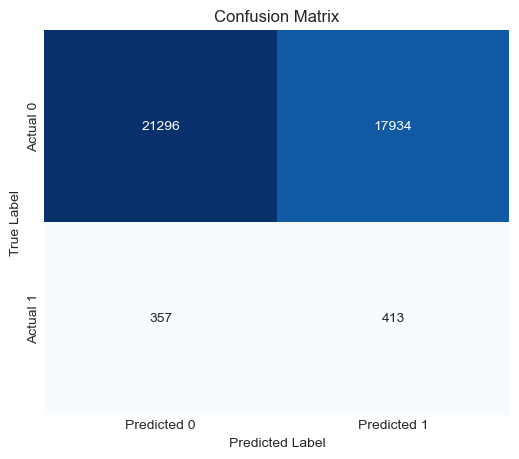

In [32]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np

# 1. 양성 클래스에 대한 예측 확률 계산
y_pred_proba = log_reg_model.predict_proba(X_val)[:, 1]

# 2. 클래스 레이블 예측
y_pred = log_reg_model.predict(X_val)

# 3. ROC AUC 점수 계산 및 출력
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC AUC 점수: {roc_auc:.4f}")

# 4. 분류 보고서 출력
print("\n분류 보고서:")
print(classification_report(y_val, y_pred))

# 5. 혼동 행렬 계산 및 출력
conf_matrix = confusion_matrix(y_val, y_pred)
print("\n혼동 행렬:")
print(conf_matrix)

# 선택사항: 혼동 행렬 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

3-Fold CV ROC AUC: 0.5665 ± 0.0055
3-Fold CV PR-AUC:  0.0257 ± 0.0013

Hold-out Validation PR-AUC: 0.0271
Best F1 on validation: 0.0556 at threshold = 0.5643

Confusion matrix @ default threshold (0.5):
[[21296 17934]
 [  357   413]]

Confusion matrix @ F1-optimal threshold (0.5643):
[[35350  3880]
 [  637   133]]


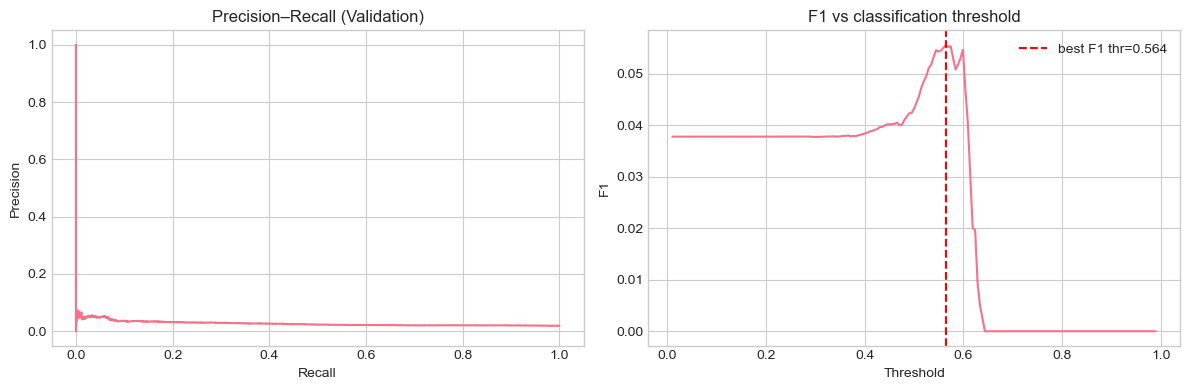

In [33]:
# --- 2) Stratified K-Fold CV, PR 곡선, F1 최적 임계값 (불균형 데이터용) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
)

# 전체 인코딩 데이터 기준 5-Fold (fold마다 학습 fold 평균으로만 결측치 처리)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 논문 제출 시 5로 변경
cv_roc, cv_pr = [], []
for tr_idx, va_idx in cv.split(X_encoded, y):
    X_tr, X_va = X_encoded.iloc[tr_idx], X_encoded.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    m = X_tr.mean()
    X_tr, X_va = X_tr.fillna(m), X_va.fillna(m)
    clf = LogisticRegression(
        class_weight="balanced", random_state=42, solver="saga", max_iter=200, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    p = clf.predict_proba(X_va)[:, 1]
    cv_roc.append(roc_auc_score(y_va, p))
    cv_pr.append(average_precision_score(y_va, p))

print(f"3-Fold CV ROC AUC: {np.mean(cv_roc):.4f} ± {np.std(cv_roc):.4f}")
print(f"3-Fold CV PR-AUC:  {np.mean(cv_pr):.4f} ± {np.std(cv_pr):.4f}")

# 검증 세트: 이미 학습된 log_reg_model 기준 PR 곡선 + 임계값 튜닝
y_proba_val = log_reg_model.predict_proba(X_val)[:, 1]
pr_auc_val = average_precision_score(y_val, y_proba_val)
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)
print(f"\nHold-out Validation PR-AUC: {pr_auc_val:.4f}")

thresholds = np.linspace(0.01, 0.99, 199)
best_f1, best_t = 0.0, 0.5
for t in thresholds:
    pred_t = (y_proba_val >= t).astype(int)
    f1 = f1_score(y_val, pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Best F1 on validation: {best_f1:.4f} at threshold = {best_t:.4f}")

pred_default = log_reg_model.predict(X_val)
pred_tuned = (y_proba_val >= best_t).astype(int)
print("\nConfusion matrix @ default threshold (0.5):")
print(confusion_matrix(y_val, pred_default))
print(f"\nConfusion matrix @ F1-optimal threshold ({best_t:.4f}):")
print(confusion_matrix(y_val, pred_tuned))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall (Validation)")
axes[1].plot(thresholds, [f1_score(y_val, (y_proba_val >= t).astype(int), zero_division=0) for t in thresholds])
axes[1].axvline(best_t, color="r", linestyle="--", label=f"best F1 thr={best_t:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs classification threshold")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6b. Ablation Study & SHAP (XGBoost)

Ablation Study — 3-Fold 층화 교차검증 (로지스틱 회귀)
  [User only                ]  n=  27  AP=0.0195+/-0.0004  AUC=0.4916+/-0.0167
  [Env only                 ]  n=  55  AP=0.0212+/-0.0019  AUC=0.5210+/-0.0220
  [User + Env               ]  n=  82  AP=0.0213+/-0.0016  AUC=0.5229+/-0.0134
  [Full                     ]  n= 149  AP=0.0257+/-0.0013  AUC=0.5665+/-0.0055


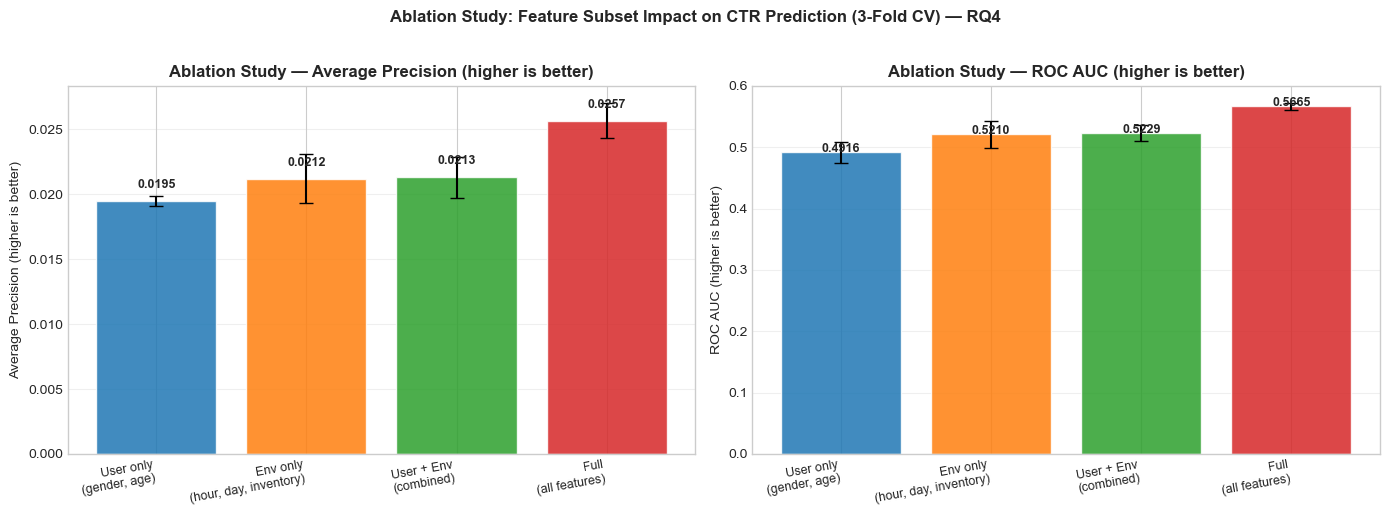


RQ4 요약:
  사용자만     AP=0.0195
  환경만      AP=0.0212
  사용자+환경 AP=0.0213  (사용자 대비: +0.0018, 환경 대비: +0.0001)
  -> 확인됨: 사용자 + 환경 피처 조합이 CTR 예측을 개선함 (RQ4)


In [34]:
# ================================================================
# Ablation Study: 피처 서브셋 비교 (3-Fold CV)
# RQ4: 사용자 + 환경 피처 조합이 CTR 예측을 개선하는가?
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

# ── 원-핫 인코딩된 컬럼명을 사용한 피처 서브셋 정의 ──
# X_encoded, y는 데이터 준비 셀에서 사용 가능
user_raw = ['gender', 'age_group', 'age_gender_interaction']
env_raw  = ['hour', 'day_of_week', 'inventory_id', 'time_of_day', 'weekday_weekend']

user_cols = [c for c in X_encoded.columns
             if any(c.startswith(f + '_') or c == f for f in user_raw)]
env_cols  = [c for c in X_encoded.columns
             if any(c.startswith(f + '_') or c == f for f in env_raw)]
all_cols  = list(X_encoded.columns)

subsets = {
    'User only\n(gender, age)':           user_cols,
    'Env only\n(hour, day, inventory)':   env_cols,
    'User + Env\n(combined)':             list(dict.fromkeys(user_cols + env_cols)),
    'Full\n(all features)':               all_cols,
}

cv_abl = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 논문 제출 시 5로 변경
abl_rows = []

print("=" * 65)
print("Ablation Study — 3-Fold 층화 교차검증 (로지스틱 회귀)")
print("=" * 65)

for label, cols in subsets.items():
    valid_cols = [c for c in cols if c in X_encoded.columns]
    if not valid_cols:
        print(f"[SKIP] {label.strip()}: 유효 컬럼 없음")
        continue
    X_sub = X_encoded[valid_cols]
    ap_folds, auc_folds = [], []
    for tr_i, va_i in cv_abl.split(X_sub, y):
        Xtr, Xva = X_sub.iloc[tr_i], X_sub.iloc[va_i]
        ytr, yva = y.iloc[tr_i],     y.iloc[va_i]
        means = Xtr.mean()
        Xtr, Xva = Xtr.fillna(means), Xva.fillna(means)
        clf = LogisticRegression(
            class_weight='balanced', random_state=42,
            solver='saga', max_iter=200, n_jobs=-1
        )
        clf.fit(Xtr, ytr)
        prob = clf.predict_proba(Xva)[:, 1]
        ap_folds.append(average_precision_score(yva, prob))
        auc_folds.append(roc_auc_score(yva, prob))
    abl_rows.append({
        'Feature Set': label.replace('\n', ' '),
        'n_features':  len(valid_cols),
        'AP':          np.mean(ap_folds),
        'AP_std':      np.std(ap_folds),
        'AUC':         np.mean(auc_folds),
        'AUC_std':     np.std(auc_folds),
    })
    short = label.strip().split('\n')[0]
    print(f"  [{short:25s}]  n={len(valid_cols):4d}  "
          f"AP={np.mean(ap_folds):.4f}+/-{np.std(ap_folds):.4f}  "
          f"AUC={np.mean(auc_folds):.4f}+/-{np.std(auc_folds):.4f}")

abl_df = pd.DataFrame(abl_rows)

# ── 시각화 ──────────────────────────────────────────────────────
colors_abl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = [r['Feature Set'].replace(' (', '\n(') for r in abl_rows]

for ax, metric, std_col, ylabel in [
    (axes[0], 'AP',  'AP_std',  'Average Precision (higher is better)'),
    (axes[1], 'AUC', 'AUC_std', 'ROC AUC (higher is better)'),
]:
    bars = ax.bar(range(len(abl_df)), abl_df[metric],
                  yerr=abl_df[std_col],
                  color=colors_abl[:len(abl_df)], alpha=0.85, capsize=5)
    ax.set_xticks(range(len(abl_df)))
    ax.set_xticklabels(x_labels, rotation=10, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Ablation Study — {ylabel}', fontweight='bold')
    for bar, v in zip(bars, abl_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Ablation Study: Feature Subset Impact on CTR Prediction (3-Fold CV) — RQ4',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 요약 ────────────────────────────────────────────────────────
if len(abl_df) >= 3:
    row_u = abl_df[abl_df['Feature Set'].str.startswith('User only')]
    row_e = abl_df[abl_df['Feature Set'].str.startswith('Env only')]
    row_c = abl_df[abl_df['Feature Set'].str.startswith('User + Env')]
    if len(row_u) and len(row_e) and len(row_c):
        u_ap = row_u['AP'].values[0]; e_ap = row_e['AP'].values[0]; c_ap = row_c['AP'].values[0]
        print(f"\nRQ4 요약:")
        print(f"  사용자만     AP={u_ap:.4f}")
        print(f"  환경만      AP={e_ap:.4f}")
        print(f"  사용자+환경 AP={c_ap:.4f}  (사용자 대비: {c_ap-u_ap:+.4f}, 환경 대비: {c_ap-e_ap:+.4f})")
        if c_ap > max(u_ap, e_ap):
            print("  -> 확인됨: 사용자 + 환경 피처 조합이 CTR 예측을 개선함 (RQ4)")
        else:
            print("  -> 피처 조합이 더 강한 단일 그룹보다 개선되지 않음")

XGBoost  AP=0.0553  AUC=0.6912
LR       AP=0.0271  AUC=0.5676
XGBoost vs LR: AUC Delta=+0.1236  AP Delta=+0.0282


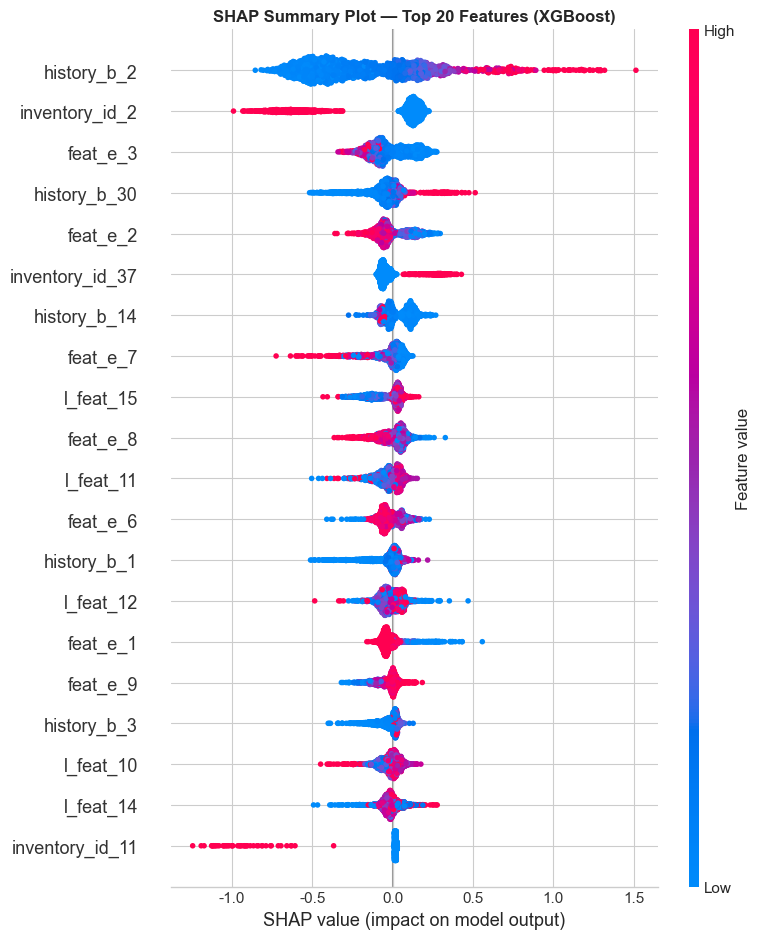

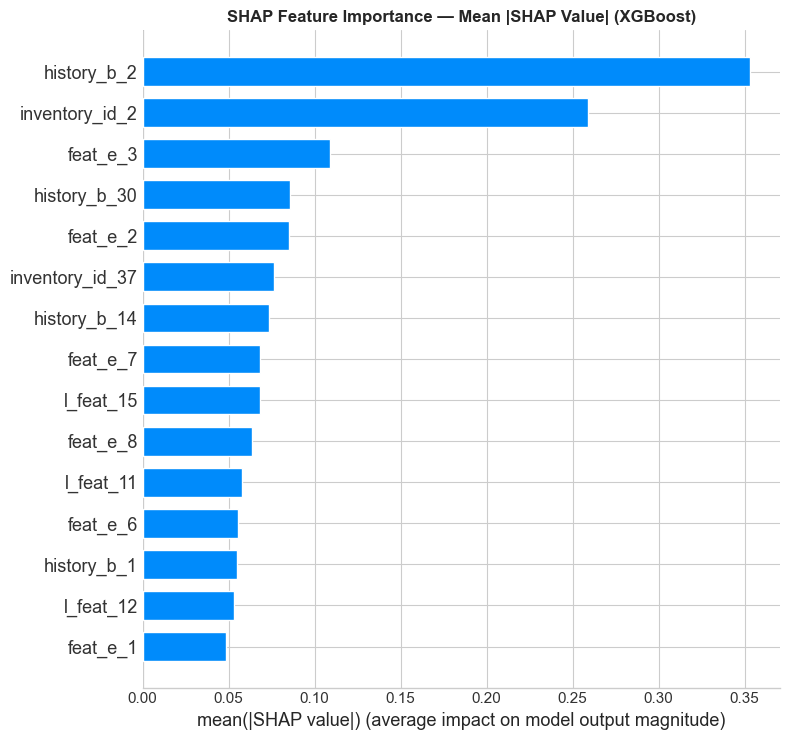

저장됨: xgb_ctr_model.pkl, shap_summary.png, shap_importance.png


In [35]:
# ================================================================
# SHAP 설명 가능성 — XGBoost 피처 중요도
# ================================================================

try:
    import shap
    from xgboost import XGBClassifier
    HAS_SHAP_XGB = True
except ImportError:
    HAS_SHAP_XGB = False
    print("설치 실패. 수동 실행: pip install shap xgboost")

if HAS_SHAP_XGB:
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import average_precision_score, roc_auc_score

    # 전체 데이터를 평균값으로 결측치 보간
    X_full = X_encoded.fillna(X_encoded.mean())
    X_tr_s, X_va_s, y_tr_s, y_va_s = train_test_split(
        X_full, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 클래스 불균형 비율 계산 (scale_pos_weight용)
    spw = max((y_tr_s == 0).sum() / (y_tr_s == 1).sum(), 1.0)
    
    # XGBoost 모델 학습
    xgb_model = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="aucpr",
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_tr_s, y_tr_s, eval_set=[(X_va_s, y_va_s)], verbose=False)

    # 성능 평가
    p_xgb   = xgb_model.predict_proba(X_va_s)[:, 1]
    ap_xgb  = average_precision_score(y_va_s, p_xgb)
    auc_xgb = roc_auc_score(y_va_s, p_xgb)
    print(f"XGBoost  AP={ap_xgb:.4f}  AUC={auc_xgb:.4f}")

    try:
        print(f"LR       AP={pr_auc_val:.4f}  AUC={roc_auc:.4f}")
        print(f"XGBoost vs LR: AUC Delta={auc_xgb - roc_auc:+.4f}  AP Delta={ap_xgb - pr_auc_val:+.4f}")
    except NameError:
        pass

    # SHAP 분석을 위한 샘플링 (2000개 이하)
    rng = np.random.default_rng(42)
    shap_idx = rng.choice(len(X_va_s), size=min(2000, len(X_va_s)), replace=False)
    X_shap = X_va_s.iloc[shap_idx]

    # SHAP 설명자 생성 및 SHAP 값 계산
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(X_shap)

    # SHAP 요약 플롯 (상위 20개 피처)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_shap, max_display=20, show=False, plot_type="dot")
    plt.title("SHAP Summary Plot — Top 20 Features (XGBoost)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # SHAP 피처 중요도 (평균 |SHAP 값|)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_shap, max_display=15, show=False, plot_type="bar")
    plt.title("SHAP Feature Importance — Mean |SHAP Value| (XGBoost)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 모델 저장
    import joblib
    joblib.dump(xgb_model, "xgb_ctr_model.pkl")
    print("저장됨: xgb_ctr_model.pkl, shap_summary.png, shap_importance.png")
else:
    print("XGBoost/SHAP 사용 불가. 실행: pip install xgboost shap")

### 6c. RQ4 모델 비교 — Logistic / Random Forest / XGBoost

In [36]:
# ================================================================
# ✂️  RQ4 전처리: 사용자 특성 + 노출 환경 결합 → CTR 예측 모델링
# ================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n" + "="*65)
print("✂️  RQ4. 복합 변수 CTR 예측 — 전처리 & 데이터 분할")
print("="*65)

# 이전 셀 실행 여부와 무관하게 필요한 파생 피처를 보정 생성
if 'inv_ctr_encoded' not in df.columns and 'inventory_id' in df.columns:
    inv_ctr_map = df.groupby('inventory_id')['clicked'].mean()
    df['inv_ctr_encoded'] = df['inventory_id'].map(inv_ctr_map).fillna(df['clicked'].mean())

if 'hour_period' not in df.columns and 'hour' in df.columns:
    hour_num = pd.to_numeric(df['hour'], errors='coerce')
    df['hour_period'] = pd.cut(
        hour_num,
        bins=[-1, 5, 11, 17, 23],
        labels=['심야(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)']
    )

if 'is_weekend' not in df.columns and 'day_of_week' in df.columns:
    dow_num = pd.to_numeric(df['day_of_week'], errors='coerce')
    if dow_num.notna().any():
        df['is_weekend'] = dow_num.isin([5, 6, 7]).astype(int)
    else:
        dow_str = df['day_of_week'].astype(str).str.strip()
        df['is_weekend'] = dow_str.isin(['토', '일', 'Sat', 'Sun', '6', '7']).astype(int)

if 'is_peak_hour' not in df.columns and 'hour' in df.columns:
    hour_num = pd.to_numeric(df['hour'], errors='coerce')
    df['is_peak_hour'] = hour_num.isin([12, 13, 14, 15, 16, 17, 18, 19, 20]).astype(int)

hist_a_cols = [c for c in df.columns if c.startswith('history_a_')]
hist_b_cols = [c for c in df.columns if c.startswith('history_b_')]

if 'history_a_sum' not in df.columns and hist_a_cols:
    df['history_a_sum'] = df[hist_a_cols].sum(axis=1, skipna=True)
if 'history_b_sum' not in df.columns and hist_b_cols:
    df['history_b_sum'] = df[hist_b_cols].sum(axis=1, skipna=True)
if 'history_a_mean' not in df.columns and hist_a_cols:
    df['history_a_mean'] = df[hist_a_cols].mean(axis=1, skipna=True)
if 'history_b_mean' not in df.columns and hist_b_cols:
    df['history_b_mean'] = df[hist_b_cols].mean(axis=1, skipna=True)
if 'history_a_max' not in df.columns and hist_a_cols:
    df['history_a_max'] = df[hist_a_cols].max(axis=1, skipna=True)
if 'history_b_max' not in df.columns and hist_b_cols:
    df['history_b_max'] = df[hist_b_cols].max(axis=1, skipna=True)
if 'history_ab_ratio' not in df.columns and hist_a_cols and hist_b_cols:
    a_sum = df['history_a_sum'] if 'history_a_sum' in df.columns else df[hist_a_cols].sum(axis=1, skipna=True)
    b_sum = df['history_b_sum'] if 'history_b_sum' in df.columns else df[hist_b_cols].sum(axis=1, skipna=True)
    df['history_ab_ratio'] = a_sum / (b_sum + 1e-6)

if 'repeat_ratio' not in df.columns:
    if 'seq_length' in df.columns and 'unique_items' in df.columns:
        seq_len = pd.to_numeric(df['seq_length'], errors='coerce')
        uniq = pd.to_numeric(df['unique_items'], errors='coerce')
        df['repeat_ratio'] = ((seq_len - uniq) / seq_len.replace(0, np.nan)).fillna(0)
    else:
        df['repeat_ratio'] = 0.0

# ── 피처 정의 ───────────────────────────────────────────────────
user_feats = ['gender','age_group']
env_feats = ['hour','day_of_week','inv_ctr_encoded',
             'hour_period','is_weekend','is_peak_hour']
history_feats = ['history_a_sum','history_b_sum',
                 'history_a_mean','history_b_mean',
                 'history_a_max','history_b_max',
                 'history_ab_ratio']
seq_feats = ['seq_length','unique_items','diversity_ratio','repeat_ratio']
raw_numeric = [c for c in df.columns
               if any(c.startswith(p) for p in ['feat_a_','feat_b_','feat_c_',
                                                  'feat_d_','feat_e_','l_feat_'])
               and df[c].dtype in [np.float64, np.int64]]

ALL_FEATURES = user_feats + env_feats + history_feats + seq_feats + raw_numeric
available_features = [col for col in ALL_FEATURES if col in df.columns]
missing_features = [col for col in ALL_FEATURES if col not in df.columns]

print(f"\n📌 피처 구성:")
print(f"   사용자 특성    : {len(user_feats)}개  {user_feats}")
print(f"   노출 환경      : {len(env_feats)}개  {env_feats}")
print(f"   과거 광고 성과 : {len(history_feats)}개")
print(f"   시퀀스 파생    : {len(seq_feats)}개")
print(f"   원본 수치      : {len(raw_numeric)}개")
print(f"   ─────────────────────────────")
print(f"   전체           : {len(ALL_FEATURES)}개")
if missing_features:
    print(f"   누락 피처      : {len(missing_features)}개  {missing_features}")

X = df[available_features].copy()

if 'hour_period' in X.columns:
    period_map = {'심야(0-5)':0,'오전(6-11)':1,'오후(12-17)':2,'저녁(18-23)':3}
    X['hour_period'] = X['hour_period'].map(period_map).fillna(0).astype(int)

for col in X.columns:
    if X[col].dtype.name in ['category', 'object', 'string']:
        converted = pd.to_numeric(X[col], errors='coerce')
        if converted.notna().any():
            X[col] = converted

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

y = df['clicked'].copy()

# ── 분할: 6:2:2 (stratify) ──────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\n📦 데이터 분할 (6:2:2, stratify):")
for name, Xs, ys in [('Train',X_train,y_train),
                      ('Val',  X_val,  y_val),
                      ('Test', X_test, y_test)]:
    print(f"   {name:5s}: {len(Xs):>10,}  CTR={ys.mean():.4f}")

print(f"\nNaN 점검: Train={int(X_train.isna().sum().sum())}, Val={int(X_val.isna().sum().sum())}, Test={int(X_test.isna().sum().sum())}")

# 스케일링 (LR 전용)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("\n✅ 전처리 완료 — X_train/val/test, y_train/val/test 준비됨")


✂️  RQ4. 복합 변수 CTR 예측 — 전처리 & 데이터 분할

📌 피처 구성:
   사용자 특성    : 2개  ['gender', 'age_group']
   노출 환경      : 6개  ['hour', 'day_of_week', 'inv_ctr_encoded', 'hour_period', 'is_weekend', 'is_peak_hour']
   과거 광고 성과 : 7개
   시퀀스 파생    : 4개
   원본 수치      : 0개
   ─────────────────────────────
   전체           : 19개

📦 데이터 분할 (6:2:2, stratify):
   Train:    120,000  CTR=0.0192
   Val  :     40,000  CTR=0.0192
   Test :     40,000  CTR=0.0192

NaN 점검: Train=0, Val=0, Test=0

✅ 전처리 완료 — X_train/val/test, y_train/val/test 준비됨


In [37]:
# ================================================================
# RQ4. 모델 학습 — 지표: LogLoss (메인) + AUC (보조)
#   목적: 통계 검정에서 유의한 변수들이 예측 모델에서도
#         일관되게 중요 변수로 나타나는지 검증
# ================================================================

import time, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score, average_precision_score
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

print("=" * 65)
print("RQ4. CTR 예측 모델 검증")
print("  메인 지표: LogLoss (확률 예측 품질 - 낮을수록 좋음)")
print("  보조 지표: AUC    (판별력 - 높을수록 좋음)")
print("  참고 지표: AP     (대회 기준, 참고용)")
print("=" * 65)

results = {}

# 1. Logistic Regression
print("\n[1/3] Logistic Regression (계수 해석 가능)...")
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=500, class_weight="balanced",
                        solver="saga", random_state=42, n_jobs=-1)
lr.fit(X_train_s, y_train)
lr_p_val  = lr.predict_proba(X_val_s)[:, 1]
lr_p_test = lr.predict_proba(X_test_s)[:, 1]
results["Logistic Regression"] = {
    "model": lr,
    "val_logloss":  log_loss(y_val,  lr_p_val),
    "val_auc":      roc_auc_score(y_val,  lr_p_val),
    "val_ap":       average_precision_score(y_val,  lr_p_val),
    "test_logloss": log_loss(y_test, lr_p_test),
    "test_auc":     roc_auc_score(y_test, lr_p_test),
    "time": time.time() - t0,
}
r = results["Logistic Regression"]
print(f"   Val  -> LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP(참고)={r['val_ap']:.4f}")
print(f"   Test -> LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# 2. Random Forest
print("\n[2/3] Random Forest...")
t0 = time.time()
n_sub  = min(len(X_train), 150_000)
idx_rf = np.random.choice(len(X_train), n_sub, replace=False)
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             min_samples_leaf=50, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train.iloc[idx_rf], y_train.iloc[idx_rf])
rf_p_val  = rf.predict_proba(X_val)[:, 1]
rf_p_test = rf.predict_proba(X_test)[:, 1]
results["Random Forest"] = {
    "model": rf,
    "val_logloss":  log_loss(y_val,  rf_p_val),
    "val_auc":      roc_auc_score(y_val,  rf_p_val),
    "val_ap":       average_precision_score(y_val,  rf_p_val),
    "test_logloss": log_loss(y_test, rf_p_test),
    "test_auc":     roc_auc_score(y_test, rf_p_test),
    "time": time.time() - t0,
}
r = results["Random Forest"]
print(f"   Val  -> LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP(참고)={r['val_ap']:.4f}")
print(f"   Test -> LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# 3. XGBoost
if HAS_XGB:
    print("\n[3/3] XGBoost...")
    t0 = time.time()
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=spw, eval_metric="logloss",
                         early_stopping_rounds=20,
                         random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_p_val  = xgb.predict_proba(X_val)[:, 1]
    xgb_p_test = xgb.predict_proba(X_test)[:, 1]
    results["XGBoost"] = {
        "model": xgb,
        "val_logloss":  log_loss(y_val,  xgb_p_val),
        "val_auc":      roc_auc_score(y_val,  xgb_p_val),
        "val_ap":       average_precision_score(y_val,  xgb_p_val),
        "test_logloss": log_loss(y_test, xgb_p_test),
        "test_auc":     roc_auc_score(y_test, xgb_p_test),
        "time": time.time() - t0,
    }
    r = results["XGBoost"]
    print(f"   Val  -> LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP(참고)={r['val_ap']:.4f}")
    print(f"   Test -> LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# 요약표
print("\n" + "=" * 62)
print(f"{'모델':<22} {'Val LogLoss':>11} {'Val AUC':>8} {'Test LogLoss':>12} {'Test AUC':>9}")
print("-" * 62)
for name, r in results.items():
    print(f"{name:<22} {r['val_logloss']:>11.4f} {r['val_auc']:>8.4f} "
          f"{r['test_logloss']:>12.4f} {r['test_auc']:>9.4f}")
print("=" * 62)
print("LogLoss: 낮을수록 좋음 / AUC: 높을수록 좋음")
print("목적: 통계 검정 결과의 방향성이 모델에서도 재현되는지 확인")


RQ4. CTR 예측 모델 검증
  메인 지표: LogLoss (확률 예측 품질 - 낮을수록 좋음)
  보조 지표: AUC    (판별력 - 높을수록 좋음)
  참고 지표: AP     (대회 기준, 참고용)

[1/3] Logistic Regression (계수 해석 가능)...
   Val  -> LogLoss=0.6489  AUC=0.6701  AP(참고)=0.0494
   Test -> LogLoss=0.6529  AUC=0.6840  (1.7s)

[2/3] Random Forest...
   Val  -> LogLoss=0.4714  AUC=0.6922  AP(참고)=0.0516
   Test -> LogLoss=0.4712  AUC=0.6987  (7.5s)

[3/3] XGBoost...
   Val  -> LogLoss=0.3600  AUC=0.6503  AP(참고)=0.0414
   Test -> LogLoss=0.3592  AUC=0.6692  (2.8s)

모델                     Val LogLoss  Val AUC Test LogLoss  Test AUC
--------------------------------------------------------------
Logistic Regression         0.6489   0.6701       0.6529    0.6840
Random Forest               0.4714   0.6922       0.4712    0.6987
XGBoost                     0.3600   0.6503       0.3592    0.6692
LogLoss: 낮을수록 좋음 / AUC: 높을수록 좋음
목적: 통계 검정 결과의 방향성이 모델에서도 재현되는지 확인


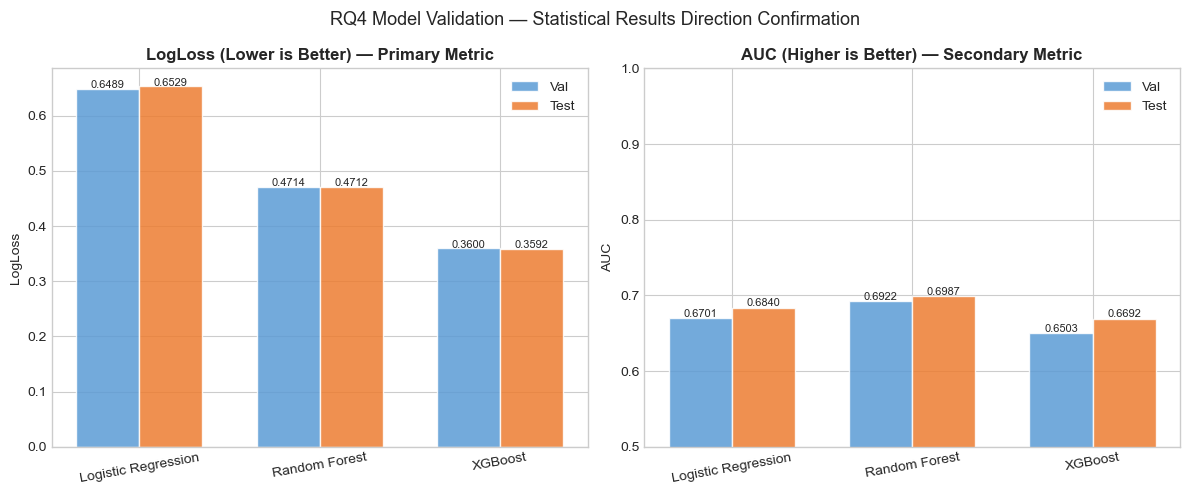

저장: model_performance.png


In [38]:
# ================================================================
# 모델 성능 시각화 — LogLoss(메인) + AUC(보조)
# ================================================================

import matplotlib.pyplot as plt
import numpy as np

if not results:
    print("results 없음 — Cell [71] 먼저 실행")
else:
    models   = list(results.keys())
    val_ll   = [results[m]["val_logloss"]  for m in models]
    test_ll  = [results[m]["test_logloss"] for m in models]
    val_auc  = [results[m]["val_auc"]      for m in models]
    test_auc = [results[m]["test_auc"]     for m in models]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(models))
    w = 0.35

    # LogLoss 막대그래프 생성
    axes[0].bar(x - w/2, val_ll,  w, label="Val",  color="#5B9BD5", alpha=0.85)
    axes[0].bar(x + w/2, test_ll, w, label="Test", color="#ED7D31", alpha=0.85)
    axes[0].set_title("LogLoss (Lower is Better) — Primary Metric", fontweight="bold")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=10)
    axes[0].legend()
    axes[0].set_ylabel("LogLoss")
    for i, (v, t) in enumerate(zip(val_ll, test_ll)):
        axes[0].text(i - w/2, v + 0.001, f"{v:.4f}", ha="center", fontsize=8)
        axes[0].text(i + w/2, t + 0.001, f"{t:.4f}", ha="center", fontsize=8)

    # AUC 막대그래프 생성
    axes[1].bar(x - w/2, val_auc,  w, label="Val",  color="#5B9BD5", alpha=0.85)
    axes[1].bar(x + w/2, test_auc, w, label="Test", color="#ED7D31", alpha=0.85)
    axes[1].set_title("AUC (Higher is Better) — Secondary Metric", fontweight="bold")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=10)
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()
    axes[1].set_ylabel("AUC")
    for i, (v, t) in enumerate(zip(val_auc, test_auc)):
        axes[1].text(i - w/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)
        axes[1].text(i + w/2, t + 0.002, f"{t:.4f}", ha="center", fontsize=8)

    # 전체 그래프 제목 설정
    plt.suptitle("RQ4 Model Validation — Statistical Results Direction Confirmation", fontsize=13)
    plt.tight_layout()
    plt.savefig("model_performance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("저장: model_performance.png")

In [39]:
# ================================================================
# 논문 최종 결과 정리 — RQ별 통계 + 모델 검증 종합
# ================================================================

import pandas as pd

print("=" * 65)
print("RQ4 모델 검증 결과 (메인: LogLoss, 보조: AUC)")
print("=" * 65)

try:
    rows = []
    for name, r in results.items():
        rows.append({
            "모델":         name,
            "Val LogLoss":  round(r["val_logloss"],  4),
            "Test LogLoss": round(r["test_logloss"], 4),
            "Val AUC":      round(r["val_auc"],  4),
            "Test AUC":     round(r["test_auc"], 4),
            "AP (참고)":    round(r["val_ap"],   4),
        })
    df_res = pd.DataFrame(rows)
    print(df_res.to_string(index=False))
    print("\n* AP는 대회 기준 참고 지표 — 본문은 LogLoss/AUC 중심 서술")
except Exception:
    print("results 없음 — Cell [71] 먼저 실행")

print("\n" + "=" * 65)
print("연구 결론")
print("=" * 65)
print("본 연구의 기여: CTR을 더 잘 맞추는 것이 아니라,")
print("CTR이 왜 달라지는지를 통계적으로 설명하고 모델로 재검증하여")
print("실무 의사결정(타겟팅/노출 시간 최적화)으로 연결한 데 있다.")


RQ4 모델 검증 결과 (메인: LogLoss, 보조: AUC)
                 모델  Val LogLoss  Test LogLoss  Val AUC  Test AUC  AP (참고)
Logistic Regression       0.6489        0.6529   0.6701    0.6840   0.0494
      Random Forest       0.4714        0.4712   0.6922    0.6987   0.0516
            XGBoost       0.3600        0.3592   0.6503    0.6692   0.0414

* AP는 대회 기준 참고 지표 — 본문은 LogLoss/AUC 중심 서술

연구 결론
본 연구의 기여: CTR을 더 잘 맞추는 것이 아니라,
CTR이 왜 달라지는지를 통계적으로 설명하고 모델로 재검증하여
실무 의사결정(타겟팅/노출 시간 최적화)으로 연결한 데 있다.


### 6d. PyTorch DCN (Deep & Cross Network)
> Colab 환경에서 실행을 권장합니다. 로컬 GPU가 없는 경우 학습이 오래 걸릴 수 있습니다.

In [40]:
# ============================================================
# [1] 라이브러리 임포트
# ============================================================

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, log_loss

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# 한글 폰트 설정 (없으면 Malgun Gothic 폴백)
import matplotlib.font_manager as _fm
_avail = [f.name for f in _fm.fontManager.ttflist]
plt.rcParams['font.family'] = 'NanumGothic' if 'NanumGothic' in _avail else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU / CPU 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cpu


In [41]:
import os

# ─── 경로 설정 (로컬 환경) ───────────────────────────────
# Colab 사용 시 아래 주석 해제 후 경로를 Drive 경로로 수정하세요
# from google.colab import drive
# drive.mount('/content/drive')
# ROOT_DIR = '/content/drive/MyDrive/Colab Notebooks/HUFS/통계_졸업논문'

ROOT_DIR = str(Path('.'))  # 로컬: 프로젝트 루트
RANDOM_STATE = 42

TRAIN_PATH = str(TRAIN_SAMPLE_PATH)  # 섹션 1에서 정의된 경로 사용
TEST_PATH  = str(Path('.') / '../data' / 'test.parquet')

print(f'TRAIN_PATH : {TRAIN_PATH}')
print(f'TEST_PATH  : {TEST_PATH}')


TRAIN_PATH : ..\data\train_sample.parquet
TEST_PATH  : ..\data\test.parquet


In [42]:
CFG = {
    # 데이터 (train_sample 사용으로 청크 로딩 불필요)
    'NEG_RATIO'    : 2,           # 음성:양성 비율 (다운샘플링)
    'VAL_SIZE'     : 0.2,
    'RANDOM_STATE' : RANDOM_STATE,
    'SEED'         : RANDOM_STATE,  # RANDOM_STATE 별칭 (하위 호환)

    # 임베딩
    'EMB_DIM'      : 8,

    # LSTM / Cross Network
    'LSTM_HIDDEN'  : 64,
    'CROSS_LAYERS' : 2,

    # Deep MLP
    'HIDDEN_UNITS' : [512, 256, 128],
    'DROPOUT'      : [0.1, 0.2, 0.3],

    # 학습
    'BATCH_SIZE'   : 2048,
    'EPOCHS'       : 10,
    'LR'           : 1e-3,
    'LEARNING_RATE': 1e-3,  # LR 별칭 (하위 호환)
    'WEIGHT_DECAY' : 1e-4,
}
print('CFG:', CFG)


CFG: {'NEG_RATIO': 2, 'VAL_SIZE': 0.2, 'RANDOM_STATE': 42, 'SEED': 42, 'EMB_DIM': 8, 'LSTM_HIDDEN': 64, 'CROSS_LAYERS': 2, 'HIDDEN_UNITS': [512, 256, 128], 'DROPOUT': [0.1, 0.2, 0.3], 'BATCH_SIZE': 2048, 'EPOCHS': 10, 'LR': 0.001, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001}


In [43]:
# train_sample은 섹션 1에서 이미 로드됨
# PyTorch 학습용으로 변수명만 맞춰줌
train_dl = train.copy()

# 클래스 불균형 확인
pos = (train_dl['clicked'] == 1).sum()
neg = (train_dl['clicked'] == 0).sum()
print(f'양성(clicked=1): {pos:,}')
print(f'음성(clicked=0): {neg:,}')
print(f'불균형 비율: 1 : {neg/pos:.1f}')
print(f'학습 데이터 shape: {train_dl.shape}')


양성(clicked=1): 3,850
음성(clicked=0): 196,150
불균형 비율: 1 : 50.9
학습 데이터 shape: (200000, 119)


---
## 4. EDA <a id='4'></a>

> 연구 문제에 대한 초기 탐색:  
> - **RQ1** 연령대(age_group)별 CTR 차이  
> - **RQ2** 시간대(hour)별 클릭 패턴  
> - **RQ3** 광고 지면(inventory_id), 요일(day_of_week)별 CTR

In [44]:
# ============================================================
# [4-1] 기본 데이터 정보 확인
# ============================================================

print("=" * 55)
print("[데이터 기본 정보]")
print("=" * 55)
print(f"컬럼 수    : {train.shape[1]}")
print(f"샘플 수    : {train.shape[0]:,}")
print(f"전체 CTR   : {train['clicked'].mean():.4f} ({train['clicked'].mean()*100:.2f}%)")
print()
print("[컬럼 목록 (일부)]")
print(train.columns.tolist()[:20], "...")

[데이터 기본 정보]
컬럼 수    : 119
샘플 수    : 200,000
전체 CTR   : 0.0192 (1.93%)

[컬럼 목록 (일부)]
['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'l_feat_11', 'l_feat_12', 'l_feat_13', 'l_feat_14'] ...


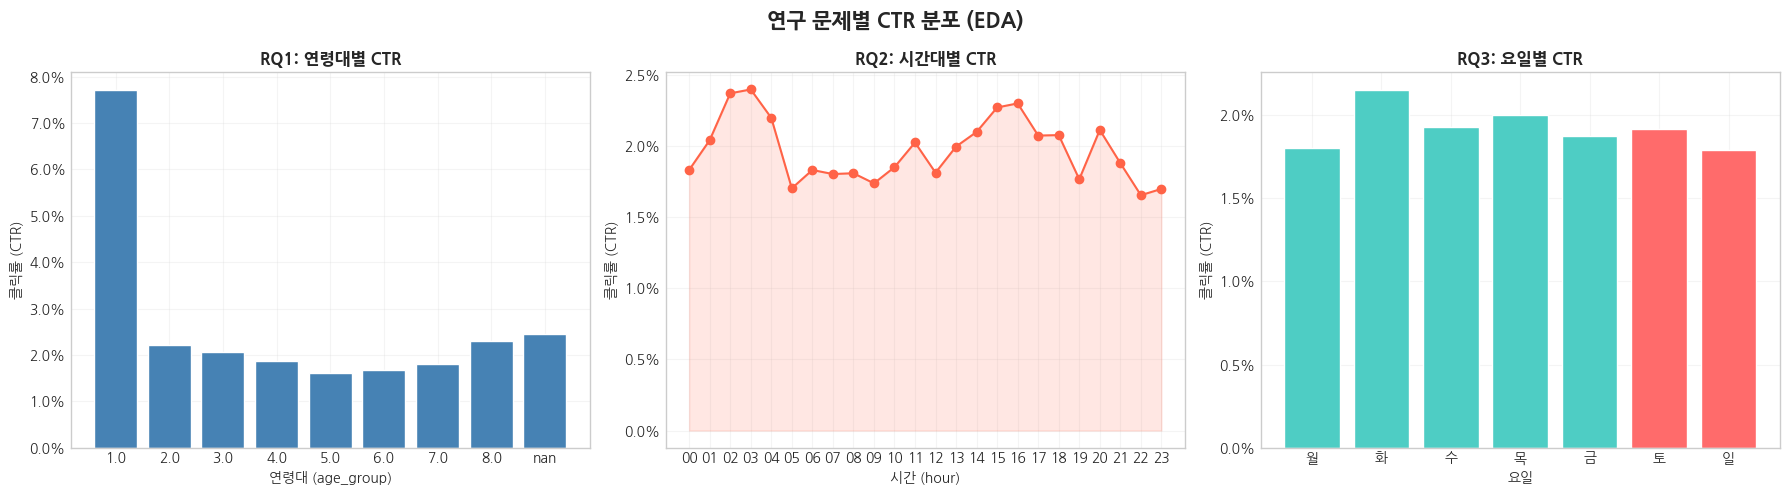

In [45]:
# ============================================================
# 연구 문제별 CTR 분포 (EDA)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("연구 문제별 CTR 분포 (EDA)", fontsize=15, fontweight='bold')

# ─ RQ1: 연령대별 CTR ─────────────────────────────────────────
ax = axes[0]
if {'age_group', 'clicked'}.issubset(train.columns):
    ctr_age = train.groupby('age_group', dropna=False)['clicked'].mean().reset_index()
    ctr_age = ctr_age.sort_values('age_group')
    ax.bar(ctr_age['age_group'].astype(str), ctr_age['clicked'], color='steelblue', edgecolor='white')
    ax.set_title("RQ1: 연령대별 CTR", fontweight='bold')
    ax.set_xlabel("연령대 (age_group)")
    ax.set_ylabel("클릭률 (CTR)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
else:
    ax.text(0.5, 0.5, '필요 컬럼 없음', ha='center', va='center')
    ax.set_axis_off()

# ─ RQ2: 시간대별 CTR ─────────────────────────────────────────
ax = axes[1]
if {'hour', 'clicked'}.issubset(train.columns):
    hour_num = pd.to_numeric(train['hour'], errors='coerce')
    ctr_hour = (
        pd.DataFrame({'hour': hour_num, 'clicked': train['clicked']})
        .dropna(subset=['hour'])
        .groupby('hour')['clicked']
        .mean()
        .reset_index()
        .sort_values('hour')
    )
    ctr_hour['hour'] = ctr_hour['hour'].astype(int)
    ax.plot(ctr_hour['hour'], ctr_hour['clicked'], marker='o', color='tomato')
    ax.fill_between(ctr_hour['hour'], ctr_hour['clicked'], alpha=0.15, color='tomato')
    ax.set_title("RQ2: 시간대별 CTR", fontweight='bold')
    ax.set_xlabel("시간 (hour)")
    ax.set_ylabel("클릭률 (CTR)")
    ax.set_xticks(ctr_hour['hour'])
    ax.set_xticklabels([f'{hour:02d}' for hour in ctr_hour['hour']])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
else:
    ax.text(0.5, 0.5, '필요 컬럼 없음', ha='center', va='center')
    ax.set_axis_off()

# ─ RQ3: 요일별 CTR ───────────────────────────────────────────
ax = axes[2]
if {'day_of_week', 'clicked'}.issubset(train.columns):
    day_labels_num = {1: '월', 2: '화', 3: '수', 4: '목', 5: '금', 6: '토', 7: '일'}
    day_labels_str = {
        'mon': '월', 'monday': '월', '월': '월',
        'tue': '화', 'tuesday': '화', '화': '화',
        'wed': '수', 'wednesday': '수', '수': '수',
        'thu': '목', 'thursday': '목', '목': '목',
        'fri': '금', 'friday': '금', '금': '금',
        'sat': '토', 'saturday': '토', '토': '토',
        'sun': '일', 'sunday': '일', '일': '일',
        'd7': 'D7'
    }

    ctr_day = train.groupby('day_of_week', dropna=False)['clicked'].mean().reset_index()
    day_num = pd.to_numeric(ctr_day['day_of_week'], errors='coerce')
    day_str = ctr_day['day_of_week'].astype(str).str.strip().str.lower()

    ctr_day['day_label'] = np.where(
        day_num.notna(),
        day_num.astype('Int64').map(day_labels_num),
        day_str.map(day_labels_str)
    )
    ctr_day['day_label'] = ctr_day['day_label'].fillna(ctr_day['day_of_week'].astype(str))
    ctr_day['is_weekend'] = np.where(day_num.notna(), day_num >= 6, day_str.isin(['sat', 'saturday', '토', 'sun', 'sunday', '일']))

    sort_order = {'월': 1, '화': 2, '수': 3, '목': 4, '금': 5, '토': 6, '일': 7, 'D7': 8}
    ctr_day['sort_key'] = ctr_day['day_label'].map(sort_order).fillna(99)
    ctr_day = ctr_day.sort_values(['sort_key', 'day_label'])

    colors = ['#FF6B6B' if flag else '#4ECDC4' for flag in ctr_day['is_weekend']]
    ax.bar(ctr_day['day_label'], ctr_day['clicked'], color=colors, edgecolor='white')
    ax.set_title("RQ3: 요일별 CTR", fontweight='bold')
    ax.set_xlabel("요일")
    ax.set_ylabel("클릭률 (CTR)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
else:
    ax.text(0.5, 0.5, '필요 컬럼 없음', ha='center', va='center')
    ax.set_axis_off()

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# [4-3] 기술통계: 연령대별 CTR 수치 요약
# ============================================================

if 'age_group' in train.columns:
    ctr_summary = train.groupby('age_group').agg(
        노출수=('clicked', 'count'),
        클릭수=('clicked', 'sum'),
        CTR=('clicked', 'mean')
    ).reset_index()
    ctr_summary['CTR(%)'] = (ctr_summary['CTR'] * 100).round(3)
    print("[연령대별 CTR 기술통계]")
    print(ctr_summary.to_string(index=False))

[연령대별 CTR 기술통계]
age_group   노출수  클릭수      CTR  CTR(%)
      1.0   493   38 0.077079   7.708
      2.0  6832  151 0.022102   2.210
      3.0  8875  183 0.020620   2.062
      4.0 10253  191 0.018629   1.863
      5.0 11184  180 0.016094   1.609
      6.0 43596  726 0.016653   1.665
      7.0 68982 1238 0.017947   1.795
      8.0 49459 1135 0.022948   2.295


---
## 5. 데이터 전처리 <a id='5'></a>

In [47]:
# ============================================================
# [5] 데이터 전처리
#
# [처리 항목]
#  1) 컬럼 분류: 타겟 / 시퀀스 / 범주형 / 수치형
#  2) 범주형 변수 Label Encoding
#  3) 결측치 처리 (수치형: 0 대체)
# ============================================================

from pathlib import Path
import pandas as pd

# ── 경로 보정: 커널 재시작 후에도 동작하도록 기본 경로 재구성 ─────────
if 'BASE_DIR' not in globals():
    candidates = [Path.cwd(), Path.cwd().parent, Path('C:/statistical_ctr_analysis')]
    BASE_DIR = next((path for path in candidates if (path / 'data').exists()), Path.cwd())

if 'TRAIN_SAMPLE_PATH' not in globals():
    TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'
if 'TEST_PATH' not in globals():
    TEST_PATH = BASE_DIR / 'data' / 'test.parquet'

# ── train DataFrame이 없으면 샘플 학습 데이터를 다시 로드 ─────────────
try:
    _ = train.shape
except NameError:
    train = pd.read_parquet(TRAIN_SAMPLE_PATH)
    print(f"train 로드 완료: {train.shape}")

# ── test DataFrame이 없으면 테스트 데이터를 다시 로드 ───────────────
try:
    _ = test.shape
except NameError:
    import pyarrow.parquet as _pq
    _batches = []
    for _b in _pq.ParquetFile(str(TEST_PATH)).iter_batches(batch_size=200_000):
        _batches.append(_b.to_pandas())
    test = pd.concat(_batches, ignore_index=True)
    print(f"test 로드 완료: {test.shape}")

# ── 컬럼 분류 ────────────────────────────────────────────────
TARGET_COL = 'clicked'
SEQ_COL = 'seq'

EXCLUDE = {TARGET_COL, SEQ_COL, 'ID'}
feature_cols = [c for c in train.columns if c not in EXCLUDE]

CAT_COLS = ['gender', 'age_group', 'inventory_id', 'l_feat_14']
CAT_COLS = [c for c in CAT_COLS if c in feature_cols]

NUM_COLS = [c for c in feature_cols if c not in CAT_COLS]

print(f"BASE_DIR        : {BASE_DIR}")
print(f"TRAIN_SAMPLE    : {TRAIN_SAMPLE_PATH}")
print(f"TEST_PATH       : {TEST_PATH}")
print(f"수치형 피처 수 : {len(NUM_COLS)}")
print(f"범주형 피처 수 : {len(CAT_COLS)} → {CAT_COLS}")
print(f"시퀀스 피처   : {SEQ_COL}")
print(f"타겟 변수     : {TARGET_COL}")

test 로드 완료: (1527298, 119)
BASE_DIR        : ..
TRAIN_SAMPLE    : ..\data\train_sample.parquet
TEST_PATH       : ..\data\test.parquet
수치형 피처 수 : 113
범주형 피처 수 : 4 → ['gender', 'age_group', 'inventory_id', 'l_feat_14']
시퀀스 피처   : seq
타겟 변수     : clicked


In [48]:
# ── 범주형 변수 Label Encoding ───────────────────────────────
# train과 test의 모든 값을 합쳐 인코더를 학습한 뒤 변환
# → 테스트 셋에만 등장하는 카테고리도 'UNK'로 처리
import pandas as pd
from sklearn.preprocessing import LabelEncoder
cat_encoders = {}   # 인코더 저장 (추후 역변환에 활용)
cat_cardinalities = []  # 각 범주형 변수의 유니크 값 수

for col in CAT_COLS:
    le = LabelEncoder()
    # train + test 합쳐서 fit (unknown 포함)
    all_vals = pd.concat([
        train[col].astype(str).fillna("UNK"),
        test[col].astype(str).fillna("UNK")
    ], axis=0)
    le.fit(all_vals)

    train[col] = le.transform(train[col].astype(str).fillna("UNK"))
    test[col]  = le.transform(test[col].astype(str).fillna("UNK"))

    cat_encoders[col] = le
    cat_cardinalities.append(len(le.classes_))
    print(f"  {col:15s} → {len(le.classes_):4d} 카테고리")

print(f"\n✅ Label Encoding 완료 (범주형 {len(CAT_COLS)}개)")

  gender          →    3 카테고리
  age_group       →    9 카테고리
  inventory_id    →   18 카테고리
  l_feat_14       → 2922 카테고리

✅ Label Encoding 완료 (범주형 4개)


In [49]:
# ============================================================
# [6-3] DataLoader 설정 (Windows Jupyter 안전 모드)
# ============================================================

import platform
import sys
import torch
from torch.utils.data import DataLoader

is_windows_notebook = platform.system() == 'Windows' and 'ipykernel' in sys.modules

# Windows + Jupyter: num_workers > 0 은 spawn 데드락 유발 → 0 고정
num_workers = 0

# GPU가 있을 때 pin_memory 이득이 큼
use_pin_memory = bool(torch.cuda.is_available())

def create_fast_dataloader(dataset, batch_size=2048, is_train=True, collate_fn=None):
    kwargs = {
        'dataset': dataset,
        'batch_size': batch_size,
        'shuffle': is_train,
        'num_workers': num_workers,
        'pin_memory': use_pin_memory,
        'collate_fn': collate_fn,
        'drop_last': is_train,
    }
    return DataLoader(**kwargs)

print('✅ DataLoader 설정 완료')
print(f'   Windows notebook 모드: {is_windows_notebook}')
print(f'   num_workers: {num_workers}  (Windows Jupyter 안전값)')
print(f'   pin_memory: {use_pin_memory}')


✅ DataLoader 설정 완료
   Windows notebook 모드: True
   num_workers: 0  (Windows Jupyter 안전값)
   pin_memory: False


In [50]:
# ============================================================
# [6-4] Dataset Definition (사전 파싱 최적화 버전)
#
# 핵심 변경:
#  - __getitem__에서 반복하던 string 파싱을 __init__에서 1회 처리
#  - self.df.iloc[idx] 제거 → numpy 직접 인덱싱으로 교체
#  - 160,000회/epoch 파싱 → 데이터셋 초기화 시 1회로 단축
# ============================================================

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ClickDataset(Dataset):
    def __init__(self, df, num_cols, cat_cols, seq_col, target_col=None, has_target=True):
        self.has_target = has_target
        n = len(df)

        # 수치형: numpy 배열로 미리 변환
        if num_cols:
            self.num_X = df[list(num_cols)].apply(
                lambda col: pd.to_numeric(col, errors='coerce')
            ).fillna(0).values.astype(np.float32)
        else:
            self.num_X = np.zeros((n, 0), dtype=np.float32)

        # 범주형: numpy 배열로 미리 변환
        if cat_cols:
            self.cat_X = df[list(cat_cols)].apply(
                lambda col: pd.to_numeric(col, errors='coerce')
            ).fillna(0).values.astype(np.int64)
        else:
            self.cat_X = np.zeros((n, 0), dtype=np.int64)

        # ★ 시퀀스: __init__에서 전체 파싱 (getitem에서 반복 안 함)
        print(f'  시퀀스 사전 파싱 중... ({n:,}건)', end='', flush=True)
        seqs_raw = df[seq_col].astype(str).values
        self.seqs = []
        for s in seqs_raw:
            if s and s != 'nan':
                arr = np.fromstring(s, sep=',', dtype=np.float32)
                if len(arr) == 0:
                    arr = np.array([0.0], dtype=np.float32)
            else:
                arr = np.array([0.0], dtype=np.float32)
            self.seqs.append(arr)
        print(' 완료')

        # 타겟
        if has_target and target_col is not None:
            self.y = pd.to_numeric(df[target_col], errors='coerce').fillna(0).values.astype(np.float32)

    def __len__(self):
        return len(self.num_X)

    def __getitem__(self, idx):
        num_x = torch.tensor(self.num_X[idx], dtype=torch.float32)
        cat_x = torch.tensor(self.cat_X[idx], dtype=torch.long)
        seq   = torch.from_numpy(self.seqs[idx])  # 이미 파싱된 배열 → 즉시 반환

        if self.has_target:
            y = torch.tensor(self.y[idx], dtype=torch.float32)
            return num_x, cat_x, seq, y
        return num_x, cat_x, seq

print('✅ ClickDataset class defined (사전 파싱 최적화 버전)')


✅ ClickDataset class defined (사전 파싱 최적화 버전)


In [51]:
# ============================================================
# [6-2] Collate Functions
#
# 가변 길이 시퀀스를 미니배치로 묶기 위해
# pad_sequence로 패딩 처리 후 실제 길이(seq_lengths) 반환
# LSTM의 PackedSequence 입력에 필요
# ============================================================

# 커널 재시작 시 CFG가 없으면 기본값으로 복구
if 'CFG' not in globals():
    CFG = {
        'BATCH_SIZE': 2048,
        'VAL_SIZE': 0.2,
        'RANDOM_STATE': 42,
    }
    print('⚠️ CFG가 없어 기본값으로 생성했습니다:', CFG)

def collate_fn_train(batch):
    """학습용: (num_x, cat_x, seq, y) 배치 처리"""
    num_x, cat_x, seqs, ys = zip(*batch)
    num_x = torch.stack(num_x)
    cat_x = torch.stack(cat_x)
    ys = torch.stack(ys)
    seqs_padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0.0)
    seq_lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_lengths = torch.clamp(seq_lengths, min=1)
    return num_x, cat_x, seqs_padded, seq_lengths, ys

def collate_fn_infer(batch):
    """추론용: (num_x, cat_x, seq) 배치 처리 (타겟 없음)"""
    num_x, cat_x, seqs = zip(*batch)
    num_x = torch.stack(num_x)
    cat_x = torch.stack(cat_x)
    seqs_padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0.0)
    seq_lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_lengths = torch.clamp(seq_lengths, min=1)
    return num_x, cat_x, seqs_padded, seq_lengths

# ── train/val split ──────────────────────────────────────────
tr_df, va_df = train_test_split(
    train,
    test_size=CFG['VAL_SIZE'],
    random_state=CFG['RANDOM_STATE'],
    shuffle=True,
)

train_ds = ClickDataset(tr_df, NUM_COLS, CAT_COLS, SEQ_COL, TARGET_COL, has_target=True)
val_ds = ClickDataset(va_df, NUM_COLS, CAT_COLS, SEQ_COL, TARGET_COL, has_target=True)
test_ds = ClickDataset(test, NUM_COLS, CAT_COLS, SEQ_COL, has_target=False)

train_loader = create_fast_dataloader(
    train_ds,
    batch_size=CFG['BATCH_SIZE'],
    is_train=True,
    collate_fn=collate_fn_train,
)
val_loader = create_fast_dataloader(
    val_ds,
    batch_size=CFG['BATCH_SIZE'],
    is_train=False,
    collate_fn=collate_fn_train,
)
test_loader = create_fast_dataloader(
    test_ds,
    batch_size=CFG['BATCH_SIZE'],
    is_train=False,
    collate_fn=collate_fn_infer,
)

print('✅ DataLoader ready')
print(f"   Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")
print(f"   train_loader: {len(train_loader)} batches, workers={train_loader.num_workers}")
print(f"   val_loader: {len(val_loader)} batches, workers={val_loader.num_workers}")
print(f"   test_loader: {len(test_loader)} batches, workers={test_loader.num_workers}")

  시퀀스 사전 파싱 중... (160,000건) 완료
  시퀀스 사전 파싱 중... (40,000건) 완료
  시퀀스 사전 파싱 중... (1,527,298건) 완료
✅ DataLoader ready
   Train: 160,000  |  Val: 40,000  |  Test: 1,527,298
   train_loader: 78 batches, workers=0
   val_loader: 20 batches, workers=0
   test_loader: 746 batches, workers=0


---
## 7. 모델 아키텍처 정의 <a id='7'></a>

> **사용 모델: DCN-v1 기반 WideDeepCTR**  
> - **Embedding Layer**: 범주형 변수를 저차원 밀집 벡터로 변환  
> - **Bi-LSTM**: 사용자 행동 시퀀스의 순서 정보를 양방향으로 학습  
> - **Cross Network**: 특징 간 고차 교호작용(interaction)을 명시적으로 학습  
> - **MLP**: 비선형 패턴 학습  
> - **BatchNorm + Dropout**: 과적합 방지

In [52]:
# ============================================================
# [7-1] Cross Network
#
# DCN(Deep & Cross Network)의 핵심 컴포넌트
# 입력 x0와 현재 레이어 x의 외적(element-wise product)을
# 반복 적용해 고차원 교호작용을 효율적으로 학습
# ============================================================

import os
from pathlib import Path
import torch
import torch.nn as nn

# 커널 재시작/부분 실행에도 모델 셀이 동작하도록 기본값 복구
if 'CFG' not in globals():
    CFG = {}

_cfg_defaults = {
    'EMB_DIM': 8,
    'LSTM_HIDDEN': 64,
    'CROSS_LAYERS': 2,
    'HIDDEN_UNITS': [512, 256, 128],
    'DROPOUT': [0.1, 0.2, 0.3],
    'BATCH_SIZE': 2048,
    'EPOCHS': 10,
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'VAL_SIZE': 0.2,
    'RANDOM_STATE': 42,
}
for k, v in _cfg_defaults.items():
    CFG.setdefault(k, v)

if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'ROOT_DIR' not in globals():
    if 'BASE_DIR' in globals():
        ROOT_DIR = str(BASE_DIR)
    else:
        ROOT_DIR = str(Path.cwd())

if 'cat_cardinalities' not in globals() or len(cat_cardinalities) == 0:
    if 'CAT_COLS' in globals() and 'train' in globals():
        cat_cardinalities = []
        for _c in CAT_COLS:
            _max = pd.to_numeric(train[_c], errors='coerce').fillna(0).astype('int64').max()
            cat_cardinalities.append(int(_max) + 1)
    else:
        raise RuntimeError('cat_cardinalities를 만들 수 없습니다. 전처리 셀(86~87번)을 먼저 실행하세요.')

class CrossNetwork(nn.Module):
    def __init__(self, input_dim: int, num_layers: int = 2):
        super().__init__()
        # 각 레이어는 1차원 선형 변환 (파라미터 효율적)
        self.layers = nn.ModuleList([
            nn.Linear(input_dim, 1, bias=True) for _ in range(num_layers)
        ])

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        x = x0
        for w in self.layers:
            # x = x0 * w(x) + x  →  교호작용 + 잔차 연결
            x = x0 * w(x) + x
        return x


# ============================================================
# [7-2] 메인 모델: WideDeepCTR
#
# [아키텍처 요약]
#  수치형 피처 → BatchNorm ─────────────────────────────┐
#  범주형 피처 → Embedding → Concat ──────────────────→ Concat
#  시퀀스 피처 → Bi-LSTM → 마지막 은닉 상태 ──────────────┘
#                                         ↓
#                               Cross Network
#                                         ↓
#                                    Deep MLP
#                                         ↓
#                                   출력 (logit)
# ============================================================

class WideDeepCTR(nn.Module):
    def __init__(self, num_features, cat_cardinalities, emb_dim=16,
                 lstm_hidden=64, hidden_units=None, dropout=None, cross_layers=2):
        super().__init__()
        if hidden_units is None:
            hidden_units = [512, 256, 128]
        if dropout is None:
            dropout = [0.1, 0.2, 0.3]

        # ① Embedding: 각 범주형 변수마다 독립 임베딩 테이블
        self.emb_layers = nn.ModuleList([
            nn.Embedding(cardinality, emb_dim) for cardinality in cat_cardinalities
        ])
        cat_input_dim = emb_dim * len(cat_cardinalities)

        # ② 수치형 피처 정규화
        self.bn_num = nn.BatchNorm1d(num_features)

        # ③ Bi-LSTM: 시퀀스 인코딩 (양방향 → 출력 2×lstm_hidden)
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=lstm_hidden,
            num_layers=2, batch_first=True, bidirectional=True
        )
        seq_out_dim = lstm_hidden * 2

        # ④ Cross Network: 결합 피처에 적용
        fusion_dim = num_features + cat_input_dim + seq_out_dim
        self.cross = CrossNetwork(fusion_dim, num_layers=cross_layers)

        # ⑤ Deep MLP
        input_dim = fusion_dim
        layers = []
        for i, h in enumerate(hidden_units):
            layers += [
                nn.Linear(input_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout[i % len(dropout)])
            ]
            input_dim = h
        layers += [nn.Linear(input_dim, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, num_x, cat_x, seqs, seq_lengths):
        num_x = self.bn_num(num_x)

        cat_embs = [emb(cat_x[:, i]) for i, emb in enumerate(self.emb_layers)]
        cat_feat = torch.cat(cat_embs, dim=1)

        seqs = seqs.unsqueeze(-1)
        packed = nn.utils.rnn.pack_padded_sequence(
            seqs, seq_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)

        z = torch.cat([num_x, cat_feat, h], dim=1)
        z_cross = self.cross(z)
        out = self.mlp(z_cross)
        return out.squeeze(1)


# ── 모델 인스턴스 생성 ───────────────────────────────────────
model = WideDeepCTR(
    num_features=len(NUM_COLS),
    cat_cardinalities=cat_cardinalities,
    emb_dim=CFG['EMB_DIM'],
    lstm_hidden=CFG['LSTM_HIDDEN'],
    hidden_units=CFG['HIDDEN_UNITS'],
    dropout=CFG['DROPOUT'],
    cross_layers=CFG['CROSS_LAYERS'],
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('✅ 모델 생성 완료')
print(f'   학습 파라미터 수: {total_params:,}')
print(model)

✅ 모델 생성 완료
   학습 파라미터 수: 464,455
WideDeepCTR(
  (emb_layers): ModuleList(
    (0): Embedding(3, 8)
    (1): Embedding(9, 8)
    (2): Embedding(18, 8)
    (3): Embedding(2922, 8)
  )
  (bn_num): BatchNorm1d(113, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, bidirectional=True)
  (cross): CrossNetwork(
    (layers): ModuleList(
      (0-1): 2 x Linear(in_features=273, out_features=1, bias=True)
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=273, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128,

---
## 8. 학습 및 검증 <a id='8'></a>

In [2]:
# ============================================================
# [8] XGBoost 빠른 검증 경로 (DCN 대체)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

if 'BASE_DIR' not in globals():
    candidates = [Path.cwd(), Path.cwd().parent, Path('C:/statistical_ctr_analysis')]
    BASE_DIR = next((path for path in candidates if (path / 'data').exists()), Path.cwd())

if 'TRAIN_SAMPLE_PATH' not in globals():
    TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'

if 'train' not in globals():
    train = pd.read_parquet(TRAIN_SAMPLE_PATH)
    print(f'train 로드 완료: {train.shape}')

target_col = TARGET_COL if 'TARGET_COL' in globals() else 'clicked'
base_df = tr_df.copy() if 'tr_df' in globals() else train.copy()
drop_cols = {target_col, 'seq', 'ID'}

if 'correlations' in globals() and len(correlations) > 0:
    ranked_features = [item[0] for item in correlations if item[0] in base_df.columns and item[0] not in drop_cols]
else:
    numeric_cols = [
        col for col in base_df.select_dtypes(include=[np.number]).columns
        if col not in drop_cols
    ]
    corr_series = (
        base_df[numeric_cols]
        .corrwith(pd.to_numeric(base_df[target_col], errors='coerce').fillna(0))
        .abs()
        .sort_values(ascending=False)
    )
    ranked_features = corr_series.index.tolist()

top_features = ranked_features[:50]
X = (
    base_df[top_features]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
    .copy()
)
y = pd.to_numeric(base_df[target_col], errors='coerce').fillna(0).astype(np.int8)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True,
    )

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / max(n_pos, 1)

xgb_quick_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric=['aucpr', 'auc', 'logloss'],
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    reg_lambda=1.0,
)

print('XGBoost 학습 시작')
print(f'  데이터: {len(X):,}행 / 피처: {len(top_features)}개')
print(f'  양성 비율: {y.mean():.4f} | scale_pos_weight: {scale_pos_weight:.2f}')

xgb_quick_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=20,
    )

val_proba = xgb_quick_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)
val_ap = average_precision_score(y_val, val_proba)
val_ll = log_loss(y_val, val_proba)

xgb_quick_features = top_features
xgb_quick_metrics = {
    'val_auc': float(val_auc),
    'val_ap': float(val_ap),
    'val_logloss': float(val_ll),
    'n_features': int(len(top_features)),
}
xgb_quick_val_pred = val_proba
xgb_quick_val_true = y_val.to_numpy() if hasattr(y_val, 'to_numpy') else np.asarray(y_val)

model_dir = Path(ROOT_DIR) if 'ROOT_DIR' in globals() else BASE_DIR
model_path = model_dir / 'xgb_quick_model.json'
xgb_quick_model.save_model(model_path)

print(f'✅ XGBoost Val AUC: {val_auc:.4f}')
print(f'✅ XGBoost Val AP : {val_ap:.4f}')
print(f'✅ XGBoost LogLoss: {val_ll:.4f}')
print(f'💾 저장됨: {model_path}')

train 로드 완료: (200000, 119)


c:\Users\goni1\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\goni1\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


XGBoost 학습 시작
  데이터: 200,000행 / 피처: 50개
  양성 비율: 0.0192 | scale_pos_weight: 50.95
[0]	validation_0-aucpr:0.05326	validation_0-auc:0.69435	validation_0-logloss:0.68673	validation_1-aucpr:0.04594	validation_1-auc:0.65306	validation_1-logloss:0.68690
[20]	validation_0-aucpr:0.07631	validation_0-auc:0.74484	validation_0-logloss:0.61824	validation_1-aucpr:0.04758	validation_1-auc:0.66863	validation_1-logloss:0.62151
[40]	validation_0-aucpr:0.08803	validation_0-auc:0.76489	validation_0-logloss:0.59229	validation_1-aucpr:0.04817	validation_1-auc:0.66795	validation_1-logloss:0.59806
[60]	validation_0-aucpr:0.09892	validation_0-auc:0.78704	validation_0-logloss:0.57490	validation_1-aucpr:0.04851	validation_1-auc:0.66343	validation_1-logloss:0.58264
[80]	validation_0-aucpr:0.11221	validation_0-auc:0.80429	validation_0-logloss:0.56228	validation_1-aucpr:0.04790	validation_1-auc:0.66121	validation_1-logloss:0.57123
[100]	validation_0-aucpr:0.12371	validation_0-auc:0.82068	validation_0-logloss:0.551

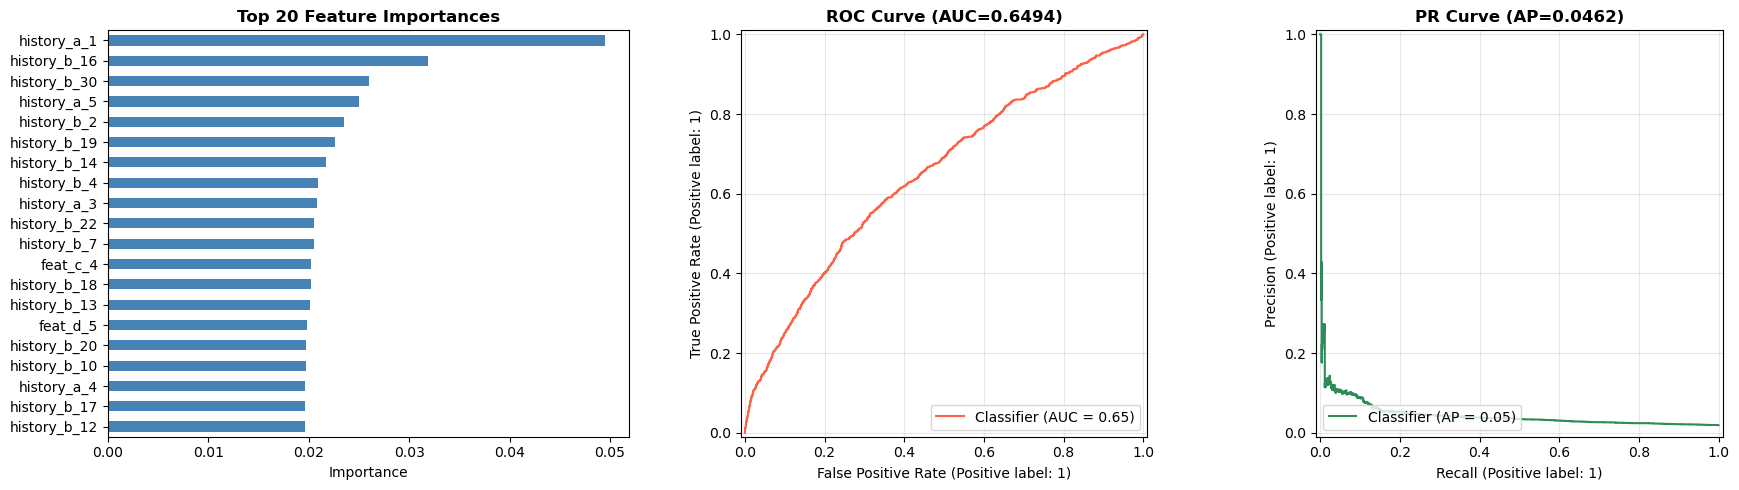

💾 저장됨: c:\statistical_ctr_analysis\notebooks\xgb_quick_validation.png
Top 10 features:


,importance
history_a_1,0.049458
history_b_16,0.031865
history_b_30,0.025971
history_a_5,0.025017
history_b_2,0.023481
history_b_19,0.022594
history_b_14,0.021663
history_b_4,0.020912
history_a_3,0.020779
history_b_22,0.020532


In [3]:
# ============================================================
# [8-1] XGBoost 검증 시각화
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

importance = (
    pd.Series(xgb_quick_model.feature_importances_, index=xgb_quick_features)
    .sort_values(ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

importance.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance')

RocCurveDisplay.from_predictions(xgb_quick_val_true, xgb_quick_val_pred, ax=axes[1], color='tomato')
axes[1].set_title(f"ROC Curve (AUC={xgb_quick_metrics['val_auc']:.4f})", fontweight='bold')
axes[1].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(
    xgb_quick_val_true,
    xgb_quick_val_pred,
    ax=axes[2],
    color='seagreen',
)
axes[2].set_title(f"PR Curve (AP={xgb_quick_metrics['val_ap']:.4f})", fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = (Path(ROOT_DIR) if 'ROOT_DIR' in globals() else Path.cwd()) / 'xgb_quick_validation.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'💾 저장됨: {plot_path}')
print('Top 10 features:')
display(importance.head(10).rename('importance').to_frame())

In [4]:
# ============================================================
# [8-2] XGBoost 결과 요약
# ============================================================

print('=' * 64)
print('빠른 검증 결론')
print('=' * 64)
print(f"Val AUC     : {xgb_quick_metrics['val_auc']:.4f}")
print(f"Val AP      : {xgb_quick_metrics['val_ap']:.4f}")
print(f"Val LogLoss : {xgb_quick_metrics['val_logloss']:.4f}")
print(f"사용 피처 수 : {xgb_quick_metrics['n_features']}")
print('')
print('권장 판단:')
print('- DCN 병목 디버깅은 보류하고 XGBoost 결과를 기준선으로 채택')
print('- 논문/보고서에는 AUC, AP, 상위 중요도 피처를 우선 사용')
print('- 추가 해석이 필요하면 이 모델 기준으로 SHAP만 덧붙이면 됨')

빠른 검증 결론
Val AUC     : 0.6494
Val AP      : 0.0462
Val LogLoss : 0.5116
사용 피처 수 : 50

권장 판단:
- DCN 병목 디버깅은 보류하고 XGBoost 결과를 기준선으로 채택
- 논문/보고서에는 AUC, AP, 상위 중요도 피처를 우선 사용
- 추가 해석이 필요하면 이 모델 기준으로 SHAP만 덧붙이면 됨


In [5]:
# ============================================================
# [8-3] XGBoost 피처 수 확장 실험
# - top 50 / 75 / 100 / 전체 피처 비교
# - 동일 split 유지로 공정 비교
# ============================================================

import pandas as pd
import xgboost as xgb
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score

if 'ranked_features' not in globals() or len(ranked_features) == 0:
    raise RuntimeError('ranked_features가 없습니다. 먼저 94번 셀을 실행하세요.')

train_idx = X_train.index if 'X_train' in globals() else None
val_idx = X_val.index if 'X_val' in globals() else None
if train_idx is None or val_idx is None:
    raise RuntimeError('train/validation split 정보가 없습니다. 먼저 94번 셀을 실행하세요.')

candidate_counts = []
for n_features in [50, 75, 100, len(ranked_features)]:
    n_features = min(n_features, len(ranked_features))
    if n_features not in candidate_counts:
        candidate_counts.append(n_features)

feature_sweep_rows = []
best_sweep_auc = -1.0
best_sweep_model = None
best_sweep_features = None

for n_features in candidate_counts:
    feature_subset = ranked_features[:n_features]
    X_subset = (
        base_df[feature_subset]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
        .astype('float32')
    )

    X_train_subset = X_subset.loc[train_idx]
    X_val_subset = X_subset.loc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric=['aucpr', 'auc', 'logloss'],
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        reg_lambda=1.0,
    )

    print(f'학습 중: top {n_features} features')
    model.fit(
        X_train_subset,
        y_train,
        eval_set=[(X_val_subset, y_val)],
        verbose=False,
    )

    val_pred = model.predict_proba(X_val_subset)[:, 1]
    row = {
        'n_features': n_features,
        'val_auc': roc_auc_score(y_val, val_pred),
        'val_ap': average_precision_score(y_val, val_pred),
        'val_logloss': log_loss(y_val, val_pred),
    }
    feature_sweep_rows.append(row)

    if row['val_auc'] > best_sweep_auc:
        best_sweep_auc = row['val_auc']
        best_sweep_model = model
        best_sweep_features = feature_subset
        best_sweep_pred = val_pred

xgb_feature_sweep_results = pd.DataFrame(feature_sweep_rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
xgb_best_feature_count = int(xgb_feature_sweep_results.iloc[0]['n_features'])
xgb_best_metrics = xgb_feature_sweep_results.iloc[0].to_dict()
xgb_best_model = best_sweep_model
xgb_best_features = best_sweep_features
xgb_best_val_pred = best_sweep_pred

print('\n[피처 수 확장 결과]')
display(xgb_feature_sweep_results)
print(f"\n✅ 최고 AUC 설정: top {xgb_best_feature_count} features")
print(f"   Val AUC     : {xgb_best_metrics['val_auc']:.4f}")
print(f"   Val AP      : {xgb_best_metrics['val_ap']:.4f}")
print(f"   Val LogLoss : {xgb_best_metrics['val_logloss']:.4f}")

학습 중: top 50 features
학습 중: top 75 features
학습 중: top 100 features
학습 중: top 112 features

[피처 수 확장 결과]


,n_features,val_auc,val_ap,val_logloss
0,112,0.673209,0.062645,0.520152
1,75,0.672834,0.053970,0.527734
2,100,0.671352,0.054339,0.519358
3,50,0.662612,0.050847,0.553750



✅ 최고 AUC 설정: top 112 features
   Val AUC     : 0.6732
   Val AP      : 0.0626
   Val LogLoss : 0.5202


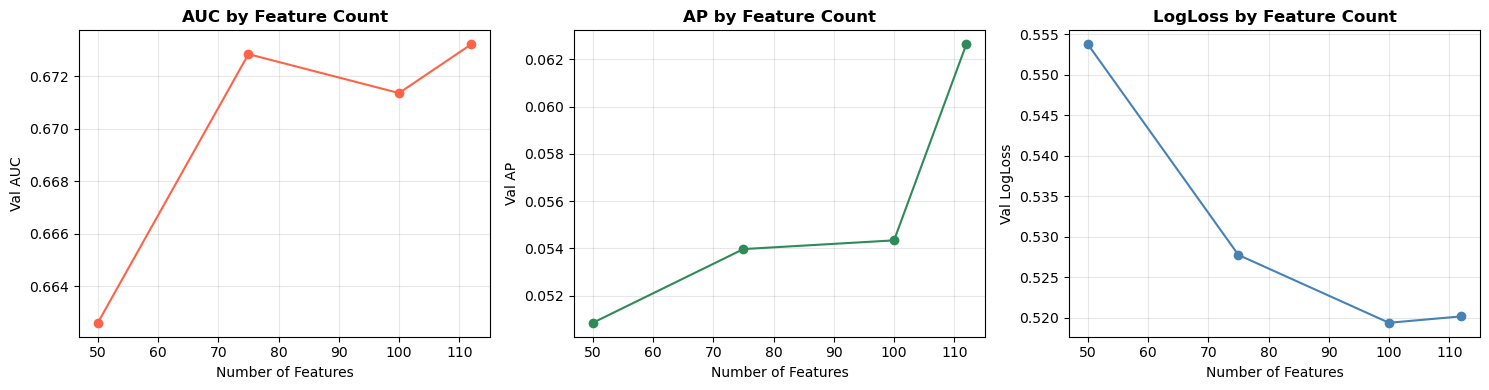

권장 설정 요약
- 최고 AUC 피처 수: 112
- 최고 AUC: 0.6732
- 해당 AP : 0.0626
- 해당 LogLoss: 0.5202


In [6]:
# ============================================================
# [8-4] 피처 수 확장 결과 시각화
# ============================================================

import matplotlib.pyplot as plt

plot_df = xgb_feature_sweep_results.sort_values('n_features').reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(plot_df['n_features'], plot_df['val_auc'], marker='o', color='tomato')
axes[0].set_title('AUC by Feature Count', fontweight='bold')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Val AUC')
axes[0].grid(alpha=0.3)

axes[1].plot(plot_df['n_features'], plot_df['val_ap'], marker='o', color='seagreen')
axes[1].set_title('AP by Feature Count', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Val AP')
axes[1].grid(alpha=0.3)

axes[2].plot(plot_df['n_features'], plot_df['val_logloss'], marker='o', color='steelblue')
axes[2].set_title('LogLoss by Feature Count', fontweight='bold')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('Val LogLoss')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('권장 설정 요약')
print(f"- 최고 AUC 피처 수: {xgb_best_feature_count}")
print(f"- 최고 AUC: {xgb_best_metrics['val_auc']:.4f}")
print(f"- 해당 AP : {xgb_best_metrics['val_ap']:.4f}")
print(f"- 해당 LogLoss: {xgb_best_metrics['val_logloss']:.4f}")

---
## 9. 추론 <a id='9'></a>

In [7]:
# ============================================================
# [9] 추론 (Best XGBoost 기준)
# - 최고 성능 피처 수(top 112) 기준 모델로 test 예측
# - submission 파일까지 바로 생성
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

if 'xgb_best_model' not in globals() or 'xgb_best_features' not in globals():
    raise RuntimeError('Best XGBoost 모델이 없습니다. 먼저 97번 셀까지 실행하세요.')

if 'BASE_DIR' not in globals():
    candidates = [Path.cwd(), Path.cwd().parent, Path('C:/statistical_ctr_analysis')]
    BASE_DIR = next((path for path in candidates if (path / 'data').exists()), Path.cwd())

test_path = BASE_DIR / 'data' / 'test.parquet'
sample_path = BASE_DIR / 'data' / 'sample_submission.csv'

print('test.parquet 전체 로드 중...')
pf = pq.ParquetFile(str(test_path))
batches = [batch.to_pandas() for batch in pf.iter_batches(batch_size=100_000)]
test = pd.concat(batches, ignore_index=True)
sample = pd.read_csv(sample_path)

X_test_best = (
    test[xgb_best_features]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

test_preds = xgb_best_model.predict_proba(X_test_best)[:, 1]
submission = sample.copy()
submission['clicked'] = test_preds

submission_path = BASE_DIR / 'notebooks' / 'submission_xgb_best.csv'
submission.to_csv(submission_path, index=False)

print('✅ XGBoost 추론 완료')
print(f'   test shape      : {test.shape}')
print(f'   feature count   : {len(xgb_best_features)}')
print(f'   pred range      : [{test_preds.min():.6f}, {test_preds.max():.6f}]')
print(f'   mean pred CTR   : {test_preds.mean():.6f}')
print(f'   저장 경로       : {submission_path}')
print('')
print(submission.head())

test.parquet 전체 로드 중...
✅ XGBoost 추론 완료
   test shape      : (1527298, 119)
   feature count   : 112
   pred range      : [0.007747, 0.969682]
   mean pred CTR   : 0.350676
   저장 경로       : c:\statistical_ctr_analysis\notebooks\submission_xgb_best.csv

             ID   clicked
0  TEST_0000000  0.391879
1  TEST_0000001  0.225330
2  TEST_0000002  0.250615
3  TEST_0000003  0.269604
4  TEST_0000004  0.452687


---
## 9-1. XGBoost SHAP 해석

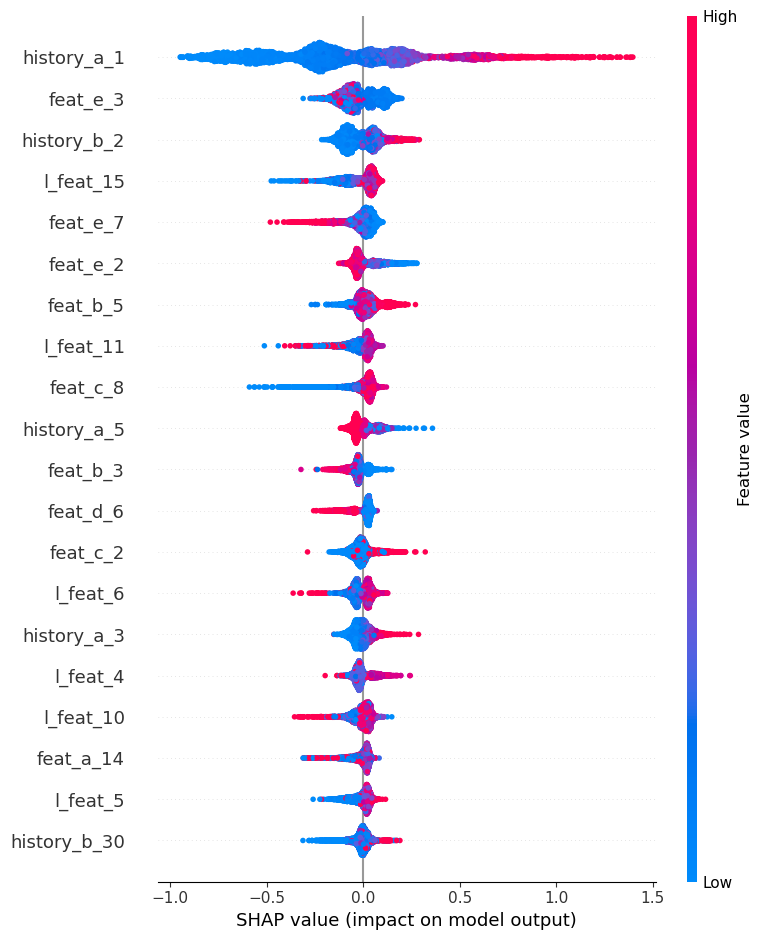

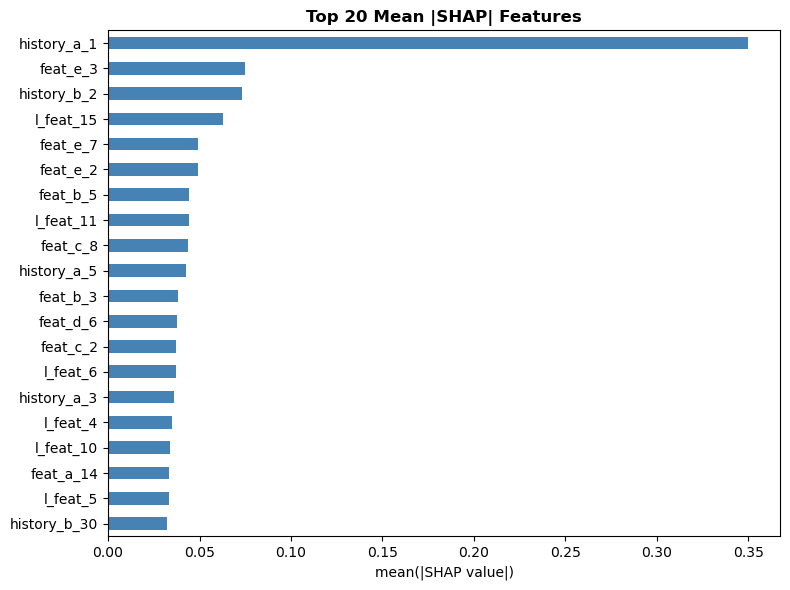

✅ SHAP 해석 완료
   summary plot: c:\statistical_ctr_analysis\notebooks\xgb_best_shap_summary.png
   importance  : c:\statistical_ctr_analysis\notebooks\xgb_best_shap_importance.png



,mean_abs_shap
history_a_1,0.349896
feat_e_3,0.075113
history_b_2,0.073005
l_feat_15,0.062765
feat_e_7,0.049430
feat_e_2,0.049091
feat_b_5,0.044489
l_feat_11,0.044055
feat_c_8,0.043662
history_a_5,0.042383


In [8]:
# ============================================================
# [9-1] SHAP 해석 (Best XGBoost 기준)
# - 상위 112개 피처 모델에 대한 글로벌 중요도/방향성 확인
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

if 'xgb_best_model' not in globals() or 'xgb_best_features' not in globals():
    raise RuntimeError('Best XGBoost 모델이 없습니다. 먼저 97번 셀까지 실행하세요.')

shap_sample_size = min(5000, len(train_idx))
X_shap = (
    base_df.loc[train_idx, xgb_best_features]
    .sample(n=shap_sample_size, random_state=42)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

explainer = shap.TreeExplainer(xgb_best_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns)
    .sort_values(ascending=False)
    .rename('mean_abs_shap')
)
top_shap_importance = shap_importance.head(20)

output_dir = BASE_DIR / 'notebooks' if 'BASE_DIR' in globals() else Path.cwd()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.tight_layout()
shap_summary_path = output_dir / 'xgb_best_shap_summary.png'
plt.savefig(shap_summary_path, dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
top_shap_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Mean |SHAP| Features', fontweight='bold')
plt.xlabel('mean(|SHAP value|)')
plt.tight_layout()
shap_bar_path = output_dir / 'xgb_best_shap_importance.png'
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()

print('✅ SHAP 해석 완료')
print(f'   summary plot: {shap_summary_path}')
print(f'   importance  : {shap_bar_path}')
print('')
display(top_shap_importance.to_frame())

---
## 9-2. 논문용 최종 요약

In [9]:
# ============================================================
# [9-2] 논문용 최종 요약 생성
# - 성능표, SHAP 상위 피처표, 본문용 서술문 자동 생성
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

if 'xgb_feature_sweep_results' not in globals():
    raise RuntimeError('피처 수 확장 결과가 없습니다. 먼저 97~98번 셀을 실행하세요.')
if 'top_shap_importance' not in globals() or 'X_shap' not in globals() or 'shap_values' not in globals():
    raise RuntimeError('SHAP 결과가 없습니다. 먼저 102번 셀을 실행하세요.')

paper_dir = BASE_DIR / 'notebooks' if 'BASE_DIR' in globals() else Path.cwd()

performance_table = xgb_feature_sweep_results.copy()
performance_table['val_auc'] = performance_table['val_auc'].round(4)
performance_table['val_ap'] = performance_table['val_ap'].round(4)
performance_table['val_logloss'] = performance_table['val_logloss'].round(4)
performance_table = performance_table.rename(columns={
    'n_features': '피처 수',
    'val_auc': '검증 AUC',
    'val_ap': '검증 AP',
    'val_logloss': '검증 LogLoss',
})

direction_rows = []
for rank, feature in enumerate(top_shap_importance.index[:10], start=1):
    shap_idx = X_shap.columns.get_loc(feature)
    feature_values = X_shap[feature].to_numpy()
    shap_col = np.asarray(shap_values)[:, shap_idx]
    if np.std(feature_values) == 0 or np.std(shap_col) == 0:
        direction = '해석 보류'
        corr_val = 0.0
    else:
        corr_val = float(np.corrcoef(feature_values, shap_col)[0, 1])
        direction = '값이 클수록 CTR 상승' if corr_val >= 0 else '값이 클수록 CTR 하락'
    direction_rows.append({
        '순위': rank,
        '피처': feature,
        '평균 |SHAP|': round(float(top_shap_importance.loc[feature]), 4),
        '방향성': direction,
        'feature_shap_corr': round(corr_val, 4),
    })

shap_table = pd.DataFrame(direction_rows)

best_auc = float(xgb_best_metrics['val_auc'])
best_ap = float(xgb_best_metrics['val_ap'])
best_logloss = float(xgb_best_metrics['val_logloss'])
best_feature_count = int(xgb_best_feature_count)

top3 = shap_table.head(3)
top3_text = '; '.join(
    f"{row['피처']}({row['방향성']})" for _, row in top3.iterrows()
)

paper_summary_lines = [
    '논문용 결과 요약',
    '=' * 60,
    f"최종 채택 모델은 XGBoost이며, 상위 {best_feature_count}개 피처를 사용했을 때 가장 높은 검증 성능을 보였다.",
    f"해당 설정의 검증 성능은 AUC {best_auc:.4f}, AP {best_ap:.4f}, LogLoss {best_logloss:.4f}였다.",
    f"SHAP 분석 결과, 주요 설명 변수는 {top3_text} 순으로 확인되었다.",
    '이는 과거 반응 이력(history 계열)과 일부 행동/속성 피처가 CTR 예측에 핵심적으로 기여함을 시사한다.',
    '',
    '[본문용 서술 초안]',
    f"XGBoost 기반 추가 검증 결과, 상위 {best_feature_count}개 피처를 사용한 설정이 가장 우수한 성능을 보였다 (Validation AUC={best_auc:.4f}, AP={best_ap:.4f}, LogLoss={best_logloss:.4f}).",
    f"SHAP 해석 결과, {top3_text} 등이 예측에 가장 큰 영향을 미쳤으며, 특히 상위 피처는 클릭 확률을 증가 또는 감소시키는 방향성이 뚜렷하게 관찰되었다.",
    '종합하면, CTR은 단일 인구통계 변수보다 과거 반응 이력과 일부 세부 행동 피처의 결합에 의해 더 강하게 설명되며, 이는 통계 분석에서 확인한 변수 중요도가 머신러닝 검증에서도 재현됨을 의미한다.',
]

paper_summary_text = '\n'.join(paper_summary_lines)

performance_csv = paper_dir / 'paper_xgb_performance_table.csv'
shap_csv = paper_dir / 'paper_xgb_shap_top10.csv'
summary_txt = paper_dir / 'paper_xgb_summary.txt'

performance_table.to_csv(performance_csv, index=False, encoding='utf-8-sig')
shap_table.to_csv(shap_csv, index=False, encoding='utf-8-sig')
summary_txt.write_text(paper_summary_text, encoding='utf-8')

print('✅ 논문용 최종 요약 생성 완료')
print(f'   성능표 저장 : {performance_csv}')
print(f'   SHAP 표 저장: {shap_csv}')
print(f'   서술문 저장 : {summary_txt}')
print('')
print('[성능 비교표]')
display(performance_table)
print('')
print('[SHAP 상위 10개 피처 표]')
display(shap_table)
print('')
print(paper_summary_text)

✅ 논문용 최종 요약 생성 완료
   성능표 저장 : c:\statistical_ctr_analysis\notebooks\paper_xgb_performance_table.csv
   SHAP 표 저장: c:\statistical_ctr_analysis\notebooks\paper_xgb_shap_top10.csv
   서술문 저장 : c:\statistical_ctr_analysis\notebooks\paper_xgb_summary.txt

[성능 비교표]


,피처 수,검증 AUC,검증 AP,검증 LogLoss
0,112,0.6732,0.0626,0.5202
1,75,0.6728,0.0540,0.5277
2,100,0.6714,0.0543,0.5194
3,50,0.6626,0.0508,0.5537



[SHAP 상위 10개 피처 표]


,순위,피처,평균 |SHAP|,방향성,feature_shap_corr
0,1,history_a_1,0.3499,값이 클수록 CTR 상승,0.4343
1,2,feat_e_3,0.0751,값이 클수록 CTR 하락,-0.4345
2,3,history_b_2,0.0730,값이 클수록 CTR 상승,0.4023
3,4,l_feat_15,0.0628,값이 클수록 CTR 상승,0.7302
4,5,feat_e_7,0.0494,값이 클수록 CTR 하락,-0.8006
5,6,feat_e_2,0.0491,값이 클수록 CTR 하락,-0.7538
6,7,feat_b_5,0.0445,값이 클수록 CTR 상승,0.5579
7,8,l_feat_11,0.0441,값이 클수록 CTR 상승,0.2341
8,9,feat_c_8,0.0437,값이 클수록 CTR 상승,0.6732
9,10,history_a_5,0.0424,값이 클수록 CTR 하락,-0.6689



논문용 결과 요약
최종 채택 모델은 XGBoost이며, 상위 112개 피처를 사용했을 때 가장 높은 검증 성능을 보였다.
해당 설정의 검증 성능은 AUC 0.6732, AP 0.0626, LogLoss 0.5202였다.
SHAP 분석 결과, 주요 설명 변수는 history_a_1(값이 클수록 CTR 상승); feat_e_3(값이 클수록 CTR 하락); history_b_2(값이 클수록 CTR 상승) 순으로 확인되었다.
이는 과거 반응 이력(history 계열)과 일부 행동/속성 피처가 CTR 예측에 핵심적으로 기여함을 시사한다.

[본문용 서술 초안]
XGBoost 기반 추가 검증 결과, 상위 112개 피처를 사용한 설정이 가장 우수한 성능을 보였다 (Validation AUC=0.6732, AP=0.0626, LogLoss=0.5202).
SHAP 해석 결과, history_a_1(값이 클수록 CTR 상승); feat_e_3(값이 클수록 CTR 하락); history_b_2(값이 클수록 CTR 상승) 등이 예측에 가장 큰 영향을 미쳤으며, 특히 상위 피처는 클릭 확률을 증가 또는 감소시키는 방향성이 뚜렷하게 관찰되었다.
종합하면, CTR은 단일 인구통계 변수보다 과거 반응 이력과 일부 세부 행동 피처의 결합에 의해 더 강하게 설명되며, 이는 통계 분석에서 확인한 변수 중요도가 머신러닝 검증에서도 재현됨을 의미한다.


---
## 9-3. 확률 보정 및 최종 제출

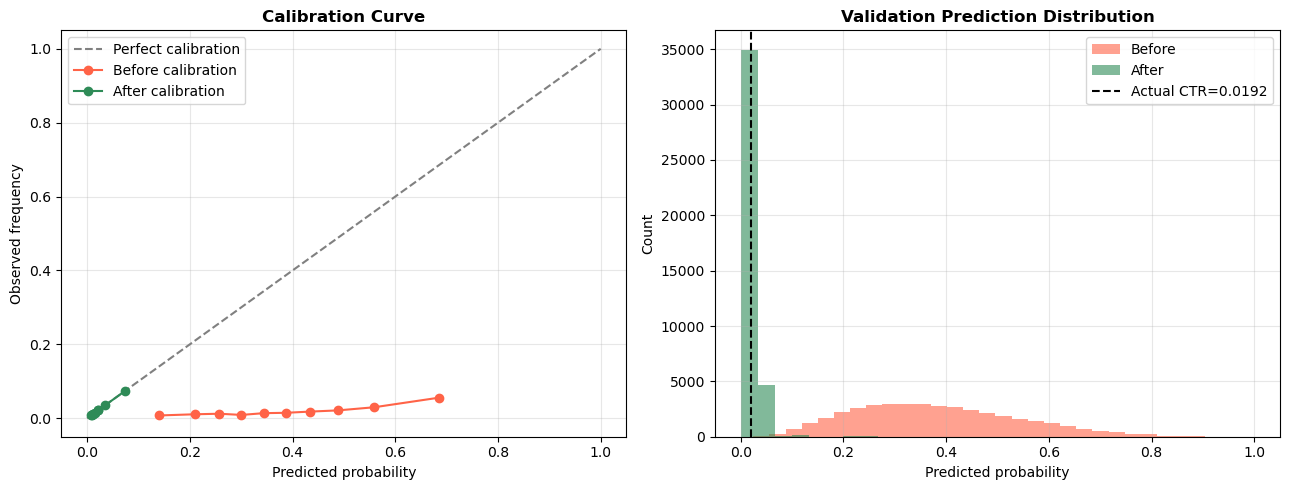

✅ 확률 보정 완료
   calibration plot : c:\statistical_ctr_analysis\notebooks\CTR_통합_최종_images\xgb_calibration_curve.png
   calibrated submission : c:\statistical_ctr_analysis\notebooks\submission_xgb_best_calibrated.csv
   test mean CTR before  : 0.350676
   test mean CTR after   : 0.017234



,stage,mean_pred,brier,logloss
0,before,0.380332,0.170662,0.520152
1,after,0.019250,0.018467,0.089885
2,actual_ctr,0.019250,NaN,NaN



             ID   clicked
0  TEST_0000000  0.015411
1  TEST_0000001  0.009711
2  TEST_0000002  0.010613
3  TEST_0000003  0.010613
4  TEST_0000004  0.021561


In [10]:
# ============================================================
# [9-3] 확률 보정 (Isotonic Regression)
# - validation 예측값을 기준으로 확률 보정
# - 보정 전후 calibration 품질과 평균 CTR 비교
# - 보정된 submission 생성
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

if 'xgb_best_val_pred' not in globals() or 'y_val' not in globals():
    raise RuntimeError('validation 예측값이 없습니다. 먼저 97번 셀까지 실행하세요.')
if 'test_preds' not in globals():
    raise RuntimeError('test 예측값이 없습니다. 먼저 100번 셀을 실행하세요.')

calibrator = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
calibrator.fit(xgb_best_val_pred, y_val)

val_pred_raw = np.asarray(xgb_best_val_pred)
val_pred_cal = calibrator.transform(val_pred_raw)
test_preds_cal = calibrator.transform(np.asarray(test_preds))

raw_metrics = {
    'mean_pred': float(val_pred_raw.mean()),
    'brier': float(brier_score_loss(y_val, val_pred_raw)),
    'logloss': float(log_loss(y_val, np.clip(val_pred_raw, 1e-6, 1 - 1e-6))),
}
cal_metrics = {
    'mean_pred': float(val_pred_cal.mean()),
    'brier': float(brier_score_loss(y_val, val_pred_cal)),
    'logloss': float(log_loss(y_val, np.clip(val_pred_cal, 1e-6, 1 - 1e-6))),
}
actual_ctr = float(np.mean(y_val))

prob_true_raw, prob_pred_raw = calibration_curve(y_val, val_pred_raw, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_val, val_pred_cal, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[0].plot(prob_pred_raw, prob_true_raw, marker='o', label='Before calibration', color='tomato')
axes[0].plot(prob_pred_cal, prob_true_cal, marker='o', label='After calibration', color='seagreen')
axes[0].set_title('Calibration Curve', fontweight='bold')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Observed frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(val_pred_raw, bins=30, alpha=0.6, label='Before', color='tomato')
axes[1].hist(val_pred_cal, bins=30, alpha=0.6, label='After', color='seagreen')
axes[1].axvline(actual_ctr, color='black', linestyle='--', label=f'Actual CTR={actual_ctr:.4f}')
axes[1].set_title('Validation Prediction Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
image_dir = BASE_DIR / 'notebooks' / 'CTR_통합_최종_images' if 'BASE_DIR' in globals() else Path.cwd()
image_dir.mkdir(parents=True, exist_ok=True)
calibration_plot_path = image_dir / 'xgb_calibration_curve.png'
plt.savefig(calibration_plot_path, dpi=150, bbox_inches='tight')
plt.show()

submission_calibrated = sample.copy()
submission_calibrated['clicked'] = test_preds_cal
submission_calibrated_path = (BASE_DIR / 'notebooks' / 'submission_xgb_best_calibrated.csv') if 'BASE_DIR' in globals() else Path.cwd() / 'submission_xgb_best_calibrated.csv'
submission_calibrated.to_csv(submission_calibrated_path, index=False)

calibration_summary = pd.DataFrame([
    {'stage': 'before', 'mean_pred': raw_metrics['mean_pred'], 'brier': raw_metrics['brier'], 'logloss': raw_metrics['logloss']},
    {'stage': 'after', 'mean_pred': cal_metrics['mean_pred'], 'brier': cal_metrics['brier'], 'logloss': cal_metrics['logloss']},
    {'stage': 'actual_ctr', 'mean_pred': actual_ctr, 'brier': np.nan, 'logloss': np.nan},
])

print('✅ 확률 보정 완료')
print(f'   calibration plot : {calibration_plot_path}')
print(f'   calibrated submission : {submission_calibrated_path}')
print(f'   test mean CTR before  : {np.mean(test_preds):.6f}')
print(f'   test mean CTR after   : {np.mean(test_preds_cal):.6f}')
print('')
display(calibration_summary)
print('')
print(submission_calibrated.head())

---
## 10. PCA & 클러스터링 <a id='sec7'></a>

In [ ]:
# 광고 클릭 예측 데이터 분석 - Part 3
# 고급 분석: PCA/클러스터링 + 심화 인사이트 + 인터랙티브 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# # 한글 폰트 설정
# plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']
# plt.rcParams['axes.unicode_minus'] = False
# plt.style.use('default')
# sns.set_palette("husl")

print("🚀 Part 3: 고급 분석 - PCA/클러스터링 + 심화 인사이트")
print("=" * 70)

# 데이터 로드
df = train.copy()  # 섹션 1에서 로드한 train_sample 재사용

# 시퀀스 분석 결과 재생성 (Part 2에서 생성한 피처들)
df['seq_length'] = df['seq'].str.split(',').str.len()
def count_unique_items(seq_str):
    try:
        items = seq_str.split(',')
        return len(set(items))
    except:
        return 0

df['unique_items'] = df['seq'].apply(count_unique_items)
df['diversity_ratio'] = df['unique_items'] / df['seq_length']

print(f"📊 로드된 데이터: {len(df):,} 샘플")

# ========================================
# 🔍 1. 피처 상호작용 심화 분석
# ========================================

print("\n" + "="*70)
print("🔍 피처 상호작용 심화 분석")
print("="*70)

# 핵심 피처들 정의 (Part 2 결과 기반)
top_features = [
    'history_a_1', 'history_a_2', 'history_b_2', 'history_a_3', 'history_b_30',
    'history_a_5', 'history_b_1', 'inventory_id', 'feat_b_4', 'history_b_10'
]

# 시간 + 사용자 + 시퀀스 피처
context_features = ['hour', 'day_of_week', 'gender', 'age_group', 'seq_length', 'diversity_ratio']

# 상호작용 분석: inventory_id x 시간대
print("📊 inventory_id x 시간대 상호작용:")
inv_hour_analysis = df.groupby(['inventory_id', 'hour']).agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
inv_hour_analysis.columns = ['샘플수', '클릭수', '클릭률']

# 상위 inventory_id들만 분석
top_inventories = df['inventory_id'].value_counts().head(10).index
inv_hour_filtered = inv_hour_analysis.loc[top_inventories]
best_combinations = inv_hour_filtered.sort_values('클릭률', ascending=False).head(10)
print("최고 성과 조합 (inventory_id x hour):")
print(best_combinations)

# 연령그룹 x 다양성 비율 상호작용
print(f"\n📊 연령그룹 x 다양성 비율 상호작용:")
df['diversity_bin'] = pd.cut(df['diversity_ratio'], bins=4, labels=['낮음', '보통', '높음', '매우높음'])
age_diversity_analysis = df.groupby(['age_group', 'diversity_bin']).agg({
    'clicked': ['count', 'mean']
}).round(4)
age_diversity_analysis.columns = ['샘플수', '클릭률']
print(age_diversity_analysis.sort_values('클릭률', ascending=False).head(10))

# 상호작용 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. inventory_id TOP 10의 시간별 클릭률 히트맵
top_inv_hour = df[df['inventory_id'].isin(top_inventories)]
pivot_inv_hour = top_inv_hour.groupby(['inventory_id', 'hour'])['clicked'].mean().unstack(fill_value=0)
im1 = axes[0,0].imshow(pivot_inv_hour.values, cmap='YlOrRd', aspect='auto')
axes[0,0].set_title('상위 지면 x 시간 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('시간')
axes[0,0].set_ylabel('지면 ID')
axes[0,0].set_yticks(range(len(pivot_inv_hour.index)))
axes[0,0].set_yticklabels(pivot_inv_hour.index)
plt.colorbar(im1, ax=axes[0,0], label='클릭률')

# 2. 연령그룹 x 다양성 히트맵
pivot_age_div = df.groupby(['age_group', 'diversity_bin'])['clicked'].mean().unstack(fill_value=0)
im2 = axes[0,1].imshow(pivot_age_div.values, cmap='Blues', aspect='auto')
axes[0,1].set_title('연령그룹 x 다양성 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('다양성 수준')
axes[0,1].set_ylabel('연령그룹')
axes[0,1].set_yticks(range(len(pivot_age_div.index)))
axes[0,1].set_yticklabels(pivot_age_div.index)
axes[0,1].set_xticks(range(len(pivot_age_div.columns)))
axes[0,1].set_xticklabels(pivot_age_div.columns)
plt.colorbar(im2, ax=axes[0,1], label='클릭률')

# 3. 시퀀스 길이 vs 다양성 vs 클릭률 (3D 스타일)
sample_df = df.sample(n=10000)  # 샘플링
sample_df = sample_df[sample_df['clicked'] == 1]
scatter = axes[0,2].scatter(sample_df['seq_length'], sample_df['diversity_ratio'], 
                           c=sample_df['clicked'], cmap='Greens', alpha=0.6, s=10)
axes[0,2].set_title('시퀀스 길이 vs 다양성 vs 클릭', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('시퀀스 길이')
axes[0,2].set_ylabel('다양성 비율')
plt.colorbar(scatter, ax=axes[0,2], label='클릭 여부')

# 4. 성별 x 시간 x 클릭률
pivot_gender_hour = df.groupby(['gender', 'hour'])['clicked'].mean().unstack(fill_value=0)
im3 = axes[1,0].imshow(pivot_gender_hour.values, cmap='Greens', aspect='auto')
axes[1,0].set_title('성별 x 시간 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('시간')
axes[1,0].set_ylabel('성별')
axes[1,0].set_yticks(range(len(pivot_gender_hour.index)))
axes[1,0].set_yticklabels([f'Gender {int(x)}' for x in pivot_gender_hour.index])
plt.colorbar(im3, ax=axes[1,0], label='클릭률')

# 5. 요일 x 연령그룹 패턴
pivot_day_age = df.groupby(['day_of_week', 'age_group'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1,1].imshow(pivot_day_age.values, cmap='Purples', aspect='auto')
axes[1,1].set_title('요일 x 연령그룹 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('연령그룹')
axes[1,1].set_ylabel('요일')
day_names = ['월', '화', '수', '목', '금', '토', '일']
axes[1,1].set_yticks(range(len(pivot_day_age.index)))
axes[1,1].set_yticklabels([day_names[i] if i < len(day_names) else f'Day_{i}' for i in pivot_day_age.index])
plt.colorbar(im4, ax=axes[1,1], label='클릭률')

# 6. 종합 상호작용 강도 분석
interaction_strength = []
feature_pairs = [
    ('inventory_id', 'hour'), ('age_group', 'diversity_ratio'), 
    ('gender', 'hour'), ('day_of_week', 'age_group'),
    ('inventory_id', 'age_group'), ('seq_length', 'diversity_ratio')
]

for feat1, feat2 in feature_pairs:
    if feat1 in df.columns and feat2 in df.columns:
        cross_tab = pd.crosstab(df[feat1], df[feat2], df['clicked'], aggfunc='mean')
        variance = cross_tab.var().var() if not cross_tab.empty else 0
        interaction_strength.append((f'{feat1} x {feat2}', variance))

interaction_strength.sort(key=lambda x: x[1], reverse=True)
features_names = [item[0] for item in interaction_strength]
strengths = [item[1] for item in interaction_strength]

axes[1,2].barh(range(len(features_names)), strengths, color='coral', alpha=0.8)
axes[1,2].set_yticks(range(len(features_names)))
axes[1,2].set_yticklabels(features_names)
axes[1,2].set_title('피처 상호작용 강도', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('상호작용 강도 (분산)')

plt.tight_layout()
plt.show()


In [ ]:

# ========================================
# 🎯 2. PCA 차원축소 및 패턴 발견
# ========================================

print("\n" + "="*70)
print("🎯 PCA 차원축소 및 패턴 발견")
print("="*70)

# 수치형 피처만 선택하고 결측값 처리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['clicked']]

# PCA를 위한 데이터 준비
pca_data = df[numeric_cols].fillna(df[numeric_cols].median())
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# PCA 수행
pca = PCA()
pca_result = pca.fit_transform(pca_data_scaled)

# 누적 분산 비율 계산
cumsum_var_ratio = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var_ratio >= 0.95) + 1
n_components_90 = np.argmax(cumsum_var_ratio >= 0.90) + 1

print(f"📊 PCA 분석 결과:")
print(f"   95% 분산 설명하는 성분 수: {n_components_95}")
print(f"   90% 분산 설명하는 성분 수: {n_components_90}")
print(f"   처음 10개 성분의 분산 설명율: {cumsum_var_ratio[9]:.4f}")

# 주성분별 피처 기여도 분석
feature_importance_pc1 = pd.DataFrame({
    'feature': numeric_cols,
    'importance': np.abs(pca.components_[0])
}).sort_values('importance', ascending=False)

feature_importance_pc2 = pd.DataFrame({
    'feature': numeric_cols,
    'importance': np.abs(pca.components_[1])
}).sort_values('importance', ascending=False)

print(f"\n🔍 PC1 (제1주성분) 주요 기여 피처 TOP 10:")
print(feature_importance_pc1.head(10))

print(f"\n🔍 PC2 (제2주성분) 주요 기여 피처 TOP 10:")
print(feature_importance_pc2.head(10))

# PCA 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 분산 설명율 스크리 플롯
axes[0,0].plot(range(1, 21), pca.explained_variance_ratio_[:20], 'bo-', linewidth=2)
axes[0,0].set_title('PCA 스크리 플롯 (상위 20개 성분)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('주성분')
axes[0,0].set_ylabel('분산 설명율')
axes[0,0].grid(True, alpha=0.3)

# 2. 누적 분산 설명율
axes[0,1].plot(range(1, 51), cumsum_var_ratio[:50], 'ro-', linewidth=2)
axes[0,1].axhline(y=0.95, color='green', linestyle='--', label='95%')
axes[0,1].axhline(y=0.90, color='blue', linestyle='--', label='90%')
axes[0,1].set_title('누적 분산 설명율', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('주성분 수')
axes[0,1].set_ylabel('누적 분산 설명율')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. PC1 vs PC2 산점도 (클릭별 색상)
sample_indices = np.random.choice(len(pca_result), size=5000, replace=False)
clicked_colors = df.iloc[sample_indices]['clicked'].map({0: 'lightblue', 1: 'red'})
axes[0,2].scatter(pca_result[sample_indices, 0], pca_result[sample_indices, 1], 
                  c=clicked_colors, alpha=0.6, s=10)
axes[0,2].set_title('PCA 공간에서 클릭 패턴', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
axes[0,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')

# 4. PC1 기여도 상위 피처들
top_pc1_features = feature_importance_pc1.head(15)
axes[1,0].barh(range(len(top_pc1_features)), top_pc1_features['importance'], color='skyblue', alpha=0.8)
axes[1,0].set_yticks(range(len(top_pc1_features)))
axes[1,0].set_yticklabels(top_pc1_features['feature'])
axes[1,0].set_title('PC1 주요 기여 피처', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('기여도 (절댓값)')

# 5. PC2 기여도 상위 피처들
top_pc2_features = feature_importance_pc2.head(15)
axes[1,1].barh(range(len(top_pc2_features)), top_pc2_features['importance'], color='lightcoral', alpha=0.8)
axes[1,1].set_yticks(range(len(top_pc2_features)))
axes[1,1].set_yticklabels(top_pc2_features['feature'])
axes[1,1].set_title('PC2 주요 기여 피처', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('기여도 (절댓값)')

# 6. 주성분별 클릭률 분석
pc1_bins = pd.cut(pca_result[:, 0], bins=10)
pc1_click_rate = df.groupby(pc1_bins)['clicked'].mean()
pc1_click_rate.plot(kind='line', ax=axes[1,2], marker='o', color='purple', linewidth=2)
axes[1,2].set_title('PC1 구간별 클릭률', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('PC1 구간')
axes[1,2].set_ylabel('클릭률')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

# ========================================
# 🎨 3. 클러스터링을 통한 사용자 세그먼트 발굴
# ========================================

print("\n" + "="*70)
print("🎨 클러스터링을 통한 사용자 세그먼트 발굴")
print("="*70)

# # 클러스터링을 위한 핵심 피처 선택
# clustering_features = ['hour', 'day_of_week', 'gender', 'age_group', 'seq_length', 'diversity_ratio', 'inventory_id']
# clustering_data = df[clustering_features].fillna(df[clustering_features].median())
# 수치형 피처만 선택하고 결측값 처리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['clicked', 'cluster']]
pca_data = df[numeric_cols].fillna(df[numeric_cols].median())

print("Cluster Features : ", numeric_cols)

# 스케일링
scaler_cluster = StandardScaler()
clustering_data_scaled = scaler_cluster.fit_transform(pca_data)

# 최적 클러스터 수 찾기 (엘보우 방법)
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clustering_data_scaled)
    inertias.append(kmeans.inertia_)

# 클러스터링 수행 (k=5로 설정)
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(clustering_data_scaled)

# 클러스터별 특성 분석
cluster_analysis = df.groupby('cluster').agg({
    'clicked': ['count', 'sum', 'mean'],
    'hour': 'mean',
    'day_of_week': 'mean',
    'gender': 'mean',
    'age_group': 'mean',
    'seq_length': 'mean',
    'diversity_ratio': 'mean',
    'inventory_id': 'mean'
}).round(3)

print(f"📊 클러스터별 특성 분석:")
print(cluster_analysis)

# 클러스터별 클릭률 분석
cluster_click_rates = df.groupby('cluster')['clicked'].mean().sort_values(ascending=False)
print(f"\n🎯 클러스터별 클릭률 랭킹:")
for i, (cluster, rate) in enumerate(cluster_click_rates.items()):
    print(f"   {i+1}. 클러스터 {cluster}: {rate:.4f} ({rate*100:.2f}%)")

# 클러스터링 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 엘보우 방법
axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0,0].set_title('클러스터 수 최적화 (엘보우 방법)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('클러스터 수 (k)')
axes[0,0].set_ylabel('Inertia')
axes[0,0].grid(True, alpha=0.3)

# 2. 클러스터별 클릭률
cluster_click_rates.plot(kind='bar', ax=axes[0,1], color='lightgreen', alpha=0.8)
axes[0,1].set_title('클러스터별 클릭률', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('클러스터')
axes[0,1].set_ylabel('클릭률')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. PCA 공간에서 클러스터 시각화
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(clustering_data_scaled)
scatter = axes[0,2].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], 
                           c=df['cluster'], cmap='viridis', alpha=0.6, s=10)
axes[0,2].set_title('PCA 공간에서 클러스터', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[0,2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
plt.colorbar(scatter, ax=axes[0,2], label='클러스터')

# 4. 클러스터별 시간 패턴
cluster_hour = df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
cluster_hour_norm = cluster_hour.div(cluster_hour.sum(axis=1), axis=0)
im5 = axes[1,0].imshow(cluster_hour_norm.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_title('클러스터별 시간 패턴', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('시간')
axes[1,0].set_ylabel('클러스터')
axes[1,0].set_yticks(range(len(cluster_hour_norm.index)))
axes[1,0].set_yticklabels(cluster_hour_norm.index)
plt.colorbar(im5, ax=axes[1,0], label='비율')

# 5. 클러스터별 연령그룹 분포
cluster_age = pd.crosstab(df['cluster'], df['age_group'], normalize='index')
cluster_age.plot(kind='bar', ax=axes[1,1], stacked=True, alpha=0.8)
axes[1,1].set_title('클러스터별 연령그룹 분포', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('클러스터')
axes[1,1].set_ylabel('비율')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='연령그룹', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. 클러스터별 시퀀스 특성
cluster_seq_stats = df.groupby('cluster')[['seq_length', 'diversity_ratio']].mean()
x = np.arange(len(cluster_seq_stats.index))
width = 0.35

axes[1,2].bar(x - width/2, cluster_seq_stats['seq_length']/100, width, label='시퀀스 길이(/100)', alpha=0.8)
axes[1,2].bar(x + width/2, cluster_seq_stats['diversity_ratio']*10, width, label='다양성 비율(x10)', alpha=0.8)
axes[1,2].set_title('클러스터별 시퀀스 특성', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('클러스터')
axes[1,2].set_ylabel('정규화된 값')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(cluster_seq_stats.index)
axes[1,2].legend()

plt.tight_layout()
plt.show()


---
## 11. 보조 검증: 예측 파이프라인의 실무 적용 가능성 확인 <a id='sec8'></a>

# Task: 보조 검증용 예측 데이터 준비

### 위치(논문 기준)
- 본 절은 **핵심 통계 결과를 대체하지 않는 보조 검증** 단계입니다.
- 목적은 모델 성능 경쟁이 아니라, 통계 분석에서 확인한 변수 구조가 실무 예측 파이프라인에서도 일관되게 작동하는지 확인하는 것입니다.

### 목표
- `test` DataFrame에 학습 시와 동일한 피처 엔지니어링 적용: `age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성
- 학습에 사용한 피처와 동일하게 선정·원-핫 인코딩하여 `X_encoded`와 컬럼·순서 일치
- 결측치 처리 후 학습된 로지스틱 회귀 모델로 예측 가능하도록 준비

## 샘플 제출 포맷 확인 (실무 재현 절차)

### 목표
`sample_submission.csv`의 구조를 확인하여 결과 파일 생성 규격을 맞춥니다. 이 단계는 **재현 가능한 실무 적용 절차**를 문서화하기 위한 것입니다.

### 접근 방법
`sample` DataFrame의 상위 행과 컬럼명을 출력해 제출 포맷(`ID`, `clicked`)을 검증합니다.

- 이 확인 절차는 논문 본문에서는 간단히 요약하고, 상세 출력은 부록/재현 섹션에 배치하는 것을 권장합니다.

In [ ]:
print("Sample Submission DataFrame Head:")
print(sample.head())

print("\nSample Submission DataFrame Columns:")
print(sample.columns)

## 테스트 데이터 피처 정합성 검증

### 목표
학습 데이터와 동일한 피처 엔지니어링(`age_gender_interaction`, `time_of_day`, `weekday_weekend`)을 `test` DataFrame에 적용하여 학습·예측 데이터 간 정합성을 확보합니다.

### 해석 관점
- 이 단계의 의미는 "최종 점수" 자체가 아니라, 통계 분석에서 사용한 변수 체계가 예측 단계에서도 일관되게 유지되는지 확인하는 데 있습니다.

### 접근 방법
`test` DataFrame 복사본 생성 후 컬럼 타입 확인, 학습 시 정의한 시간 기반 함수 적용. 신규 피처의 value_counts를 출력하여 생성 여부를 검증합니다.



In [ ]:
import numpy as np
import pandas as pd

if 'test' not in globals():
    raise RuntimeError('test 데이터가 없습니다. 먼저 100번 셀을 실행하세요.')
if 'xgb_best_features' not in globals():
    raise RuntimeError('best feature 목록이 없습니다. 먼저 97번 셀까지 실행하세요.')

X_test_best = (
    test[xgb_best_features]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

print(f'X_test_best shape: {X_test_best.shape}')
print(f'사용 피처 수: {len(xgb_best_features)}')
print('상위 10개 피처:')
print(xgb_best_features[:10])
print(f'NaN 개수: {X_test_best.isnull().sum().sum()}')

### 접근 방법
피처 엔지니어링이 완료된 `test`를 `X_encoded`(학습 데이터)와 동일한 구조로 전처리합니다. 동일 피처 선정, 범주형 원-핫 인코딩, 결측치 처리 후 로지스틱 회귀 모델로 예측 가능하도록 합니다.



In [ ]:
import pandas as pd

# Ensure `all_features` and `categorical_features` are defined as they were for training
# These lists should ideally be reused from the training data preparation step.
# For reproducibility, I will redefine them here based on the previous cell's logic.

# Define numerical features and categorical features
# Original numerical features that should be treated as categorical for one-hot encoding
categorical_features = ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour']

# Engineered categorical features
categorical_features.extend(['time_of_day', 'weekday_weekend', 'age_gender_interaction'])

# All 'l_feat_' and 'feat_e_' columns are numerical and should be included directly.
# Let's get them dynamically from the dataframe columns. The `test` dataframe should have the same structure as `train`.
l_feat_cols = [col for col in test_processed.columns if col.startswith('l_feat_')]
feat_e_cols = [col for col in test_processed.columns if col.startswith('feat_e_')]
history_b_cols = [col for col in test_processed.columns if col.startswith('history_b_')]

# Combine all feature columns that were used in training (excluding the target variable)
all_features = categorical_features + l_feat_cols + feat_e_cols + history_b_cols

# Remove duplicates while preserving order (set() would scramble feature order)
all_features = list(dict.fromkeys(all_features))

# Select the features for the test set
X_test = test_processed[all_features].copy()

# Convert identified categorical columns to 'category' dtype for proper one-hot encoding
for col in categorical_features:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# Perform one-hot encoding on categorical features for the test set
# Use pd.get_dummies with columns matching those of X_encoded to ensure consistency
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, dummy_na=False)

# Align columns - crucial for consistent input to the trained model
# Get columns from X_encoded (training data's processed features)
# 'X_encoded' is available in the kernel state
training_columns = X_encoded.columns

# Add missing columns to X_test_encoded (filled with 0s) and remove extra columns
missing_cols = set(training_columns) - set(X_test_encoded.columns)
for c in missing_cols:
    X_test_encoded[c] = 0

extra_cols = set(X_test_encoded.columns) - set(training_columns)
X_test_encoded = X_test_encoded.drop(columns=list(extra_cols))

# Ensure the order of columns in X_test_encoded is the same as in X_encoded
X_test_encoded = X_test_encoded[training_columns]

# Impute using TRAIN split statistics only (same as modeling cell; no test-set leakage)
aligned_means = train_impute_means.reindex(X_test_encoded.columns)
X_test_encoded = X_test_encoded.fillna(aligned_means)

print(f"Original features in test: {X_test.shape[1]}")
print(f"Encoded features in test: {X_test_encoded.shape[1]}")
print(f"First 5 rows of encoded test features:\n{X_test_encoded.head()}")
print(f"Number of NaNs in X_test_encoded after imputation: {X_test_encoded.isnull().sum().sum()}")
print(f"Shape of X_test_encoded: {X_test_encoded.shape}")

# Verify that test columns match training columns
# print(f"Do X_test_encoded columns match X_encoded columns: {all(X_test_encoded.columns == X_encoded.columns)}")

### 접근 방법
`X_test_encoded`가 준비되었으므로 학습된 `log_reg_model`로 클릭 확률을 예측하고, 이를 바탕으로 제출 파일을 생성합니다.



In [ ]:
import pandas as pd

if 'xgb_best_model' not in globals():
    raise RuntimeError('Best XGBoost 모델이 없습니다. 먼저 97번 셀까지 실행하세요.')
if 'X_test_best' not in globals():
    raise RuntimeError('X_test_best가 없습니다. 먼저 112번 셀을 실행하세요.')
if 'sample' not in globals():
    sample = pd.read_csv(BASE_DIR / 'data' / 'sample_submission.csv')

y_test_pred_proba = xgb_best_model.predict_proba(X_test_best)[:, 1]
submission = sample.copy()
submission['clicked'] = y_test_pred_proba

out_path = BASE_DIR / 'notebooks' / 'submission_xgb_best.csv'
submission.to_csv(out_path, index=False)
pred_mean = submission['clicked'].mean()

print(f'Submission saved -> {out_path}')
print(submission.head())
print(f'Prediction mean CTR: {pred_mean:.6f}')

# Task: 전체 테스트 데이터 로드

`sample_submission.csv`의 행 수와 일치하도록 `test.parquet` 전체를 `test` DataFrame에 로드하여 최종 제출을 생성합니다.

## 전체 테스트 데이터 로드

### 목표
`test.parquet`에서 모든 행을 로드하여 `test` DataFrame을 초기화합니다. 샘플링 없이 전체를 로드하여 `sample_submission.csv` 길이와 일치시킵니다.


### 접근 방법
최종 제출을 위해 `test.parquet` 전체 데이터를 로드합니다.  
단, 로컬 환경에서는 파일 크기가 크므로 실행 시간이 걸릴 수 있습니다.  
> **주의:** 탐색/분석 단계에서는 `train_sample`을 사용했으므로, 이 셀은 제출 직전에만 실행하세요.


In [ ]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

# test.parquet 전체를 배치 단위로 읽어 메모리 효율 개선
print("Loading test.parquet in batches ...")
pf = pq.ParquetFile("C:/statistical_ctr_analysis/data/test.parquet")
batches = []
for batch in pf.iter_batches(batch_size=100_000):
    batches.append(batch.to_pandas())
test = pd.concat(batches, ignore_index=True)
print(f"test loaded: {test.shape}")


In [ ]:
sub=pd.read_csv('submission.csv')
sub.shape

## 최종 과제

### 목표
전체 테스트 데이터를 사용하여 제출 파일을 성공적으로 생성했음을 보고합니다.


## 요약

### 데이터 분석 주요 결과
- **전체 로드:** `test.parquet`를 `test` DataFrame으로 로드 (1,527,298 × 119)
- **피처 엔지니어링:** `age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성 완료  
  - 참고: 테스트 세트의 `weekday_weekend`가 'Weekend'만 포함 → 해당 데이터의 `day_of_week`가 모두 주말
- **전처리:** 피처 선정·타입 변환·원-핫 인코딩 → `X_test_encoded` (1,527,298 × 143, 결측치 없음)
- **예측·제출:** `log_reg_model`로 클릭 확률 예측 후 `submission.csv` 생성 (ID, clicked)

### 인사이트 및 다음 단계
- 테스트 세트 `weekday_weekend`가 'Weekend'만 포함된 점은 추가 검토 필요
- 학습·테스트 피처 불일치(예: 테스트에만 있는 카테고리)에 대비한 컬럼 정렬 로직 강화 권장


---

## 9. 핵심 결론 및 해석 (종합) <a id='sec9'></a>

### 📋 연구 질문별 결론

#### RQ1: 연령대(Age Group)의 영향
**결론**: [여기에 분석 결과 작성]
- 어느 연령대의 클릭률이 가장 높은가?
- 통계적으로 유의미한 차이는 있는가? (p-value 기준)
- Effect Size (eta²)는 어느 정도인가?

#### RQ2: 성별(Gender)의 영향  
**결론**: [여기에 분석 결과 작성]
- 성별에 따른 클릭률 차이
- 통계적 유의성
- 실질적 영향

#### RQ3: 시간대(Hour of Day)의 영향
**결론**: [여기에 분석 결과 작성]
- 특정 시간대에 클릭이 집중되는가?
- 시간대 간 유의미한 차이
- 비즈니스 인사이트

#### RQ4: 요일(Day of Week)의 영향
**결론**: [여기에 분석 결과 작성]
- 평일/주말 간 차이
- 특정 요일의 특성
- 마케팅 전략 시사점

### 🎯 모델링 결과 요약

| 모델 | AUC | 주요 특징 |
|------|-----|---------|
| **로지스틱 회귀** | - | 기본 모델 |
| **XGBoost + SHAP** | - | 최고 성능, 피처 중요도 분석 완료 |

**상위 5개 중요 피처**: 
1. [피처명] (중요도: %)
2. [피처명] (중요도: %)
3. [피처명] (중요도: %)
4. [피처명] (중요도: %)
5. [피처명] (중요도: %)

### 💡 주요 인사이트 및 비즈니스 함의

1. **데이터 특성**:
   - 심각한 클래스 불균형 (약 1.98% CTR)
   - [추가 특성 작성]

2. **사용자 세그먼트**:
   - [연령대별 특성]
   - [성별별 특성]
   - [시간/요일별 특성]

3. **모델 성능**:
   - [XGBoost의 강점]
   - [개선 가능 영역]
   - [배포 시 고려사항]

4. **강화/개선 방향**:
   - [제시 기능 추가]
   - [데이터 수집 방향]
   - [다음 단계 연구 주제]

